<a href="https://colab.research.google.com/github/Narththanan-0704/Energy-poverty-early-warning/blob/main/energy_poverty_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initial steps for preparation

##Mounting drive and files upload and check

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create the project folder structure and add the required raw-dataset,
2019 - 2014 electricity consumption dataset.
IMD file 7 (Index of Multiple Deprivation,  domains=> Income, Employment, Education (Skills and Training), Health (and Disability), Crime, Barriers to Housing and Services, and Living Environment)
ONSPD (office for national statistics postcode directory)


In [2]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/energy_poverty_colab')

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
OUTPUT_DIR = BASE_DIR / 'outputs'
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'
NOTEBOOK_DIR = BASE_DIR / 'notebook'

folders = [
    BASE_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    OUTPUT_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    NOTEBOOK_DIR
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")
print("Base folder:", BASE_DIR)

Project folders created successfully.
Base folder: /content/drive/MyDrive/energy_poverty_colab


Check weather the required files are uploaded successfully

In [3]:
required_files = [
    'electricity_2019.csv',
    'electricity_2020.csv',
    'electricity_2021.csv',
    'electricity_2022.csv',
    'electricity_2023.csv',
    'electricity_2024.csv',
    'imd_file_7.csv',
    'onspd.csv'
]

print("Checking files in:", RAW_DIR)
print("-" * 60)

missing_files = []

for file_name in required_files:
    file_path = RAW_DIR / file_name

    if file_path.exists():
        print("FOUND:", file_name)
    else:
        print("MISSING:", file_name)
        missing_files.append(file_name)

print("-" * 60)

if len(missing_files) == 0:
    print("All required files are available.")
else:
    print("Missing files:")
    for file in missing_files:
        print("-", file)

Checking files in: /content/drive/MyDrive/energy_poverty_colab/data/raw
------------------------------------------------------------
FOUND: electricity_2019.csv
FOUND: electricity_2020.csv
FOUND: electricity_2021.csv
FOUND: electricity_2022.csv
FOUND: electricity_2023.csv
FOUND: electricity_2024.csv
FOUND: imd_file_7.csv
FOUND: onspd.csv
------------------------------------------------------------
All required files are available.


#Dataset cleaning

Inspect any one 0f dataset and check sample of the columns and rows are correct.
check for 2019 electricity dataset

In [4]:
import pandas as pd
from pathlib import Path

file_2019 = RAW_DIR / "electricity_2019.csv"


if not file_2019.exists():
    raise FileNotFoundError(f"File not found: {file_2019}")


file_size_mb = file_2019.stat().st_size / (1024 ** 2)

print("File:", file_2019.name)
print(f"File size: {file_size_mb:.2f} MB")
print("-" * 70)

# Try common text encodings
encodings_to_try = ["utf-8", "utf-8-sig", "latin-1", "cp1252"]

sample_2019 = None
successful_encoding = None

for encoding in encodings_to_try:
    try:
        sample_2019 = pd.read_csv(
            file_2019,
            encoding=encoding,
            nrows=10
        )

        successful_encoding = encoding
        print(f"File loaded successfully using encoding: {encoding}")
        break

    except UnicodeDecodeError:
        print(f"Encoding failed: {encoding}")

    except Exception as error:
        print(f"Error using {encoding}: {error}")

if sample_2019 is None:
    raise ValueError("The file could not be loaded using the tested encodings.")

print("-" * 70)
print("Number of columns:", len(sample_2019.columns))

print("\nOriginal column names:")
for number, column in enumerate(sample_2019.columns, start=1):
    print(f"{number}. {repr(column)}")

print("\nFirst five rows:")
display(sample_2019.head())

print("\nData types from sample:")
print(sample_2019.dtypes)

File: electricity_2019.csv
File size: 72.74 MB
----------------------------------------------------------------------
File loaded successfully using encoding: utf-8
----------------------------------------------------------------------
Number of columns: 6

Original column names:
1. 'Outcode'
2. 'Postcode'
3. 'Num_meters'
4. 'Total_cons_kwh'
5. 'Mean_cons_kwh'
6. 'Median_cons_kwh'

First five rows:


,Outcode,Postcode,Num_meters,Total_cons_kwh,Mean_cons_kwh,Median_cons_kwh
0,AB10,All postcodes,13067,38073711.6,2913.730129,2159.7
1,AB10,AB10 1AU,39,110985.6,2845.784615,2113.3
2,AB10,AB10 1BA,28,64018.7,2286.382143,1761.5
3,AB10,AB10 1BB,5,12719.0,2543.800000,2392.7
4,AB10,AB10 1FG,25,52411.5,2096.460000,1855.9



Data types from sample:
Outcode             object
Postcode            object
Num_meters           int64
Total_cons_kwh     float64
Mean_cons_kwh      float64
Median_cons_kwh    float64
dtype: object


Dataset cleaning for 2019

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

file_2019 = RAW_DIR / "electricity_2019.csv"

print("Loading the complete 2019 dataset...")

# only the required columns
df_2019 = pd.read_csv(
    file_2019,
    encoding="utf-8",
    usecols=[
        "Outcode",
        "Postcode",
        "Num_meters",
        "Total_cons_kwh",
        "Mean_cons_kwh",
        "Median_cons_kwh"
    ],
    dtype={
        "Outcode": "string",
        "Postcode": "string"
    },
    low_memory=False
)

print("File loaded successfully.")
print("Original shape:", df_2019.shape)

# Rename columns according to planned project schema
column_mapping = {
    "Outcode": "OUTWARD",
    "Postcode": "Postcode",
    "Num_meters": "meters",
    "Total_cons_kwh": "total_kwh",
    "Mean_cons_kwh": "mean_kwh",
    "Median_cons_kwh": "median_kwh"
}

df_2019 = df_2019.rename(columns=column_mapping)

# Clean text columns

df_2019["Postcode"] = (
    df_2019["Postcode"]
    .astype("string")
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df_2019["OUTWARD"] = (
    df_2019["OUTWARD"]
    .astype("string")
    .str.upper()
    .str.strip()
)

# Remove aggregate rows
aggregate_mask = (
    df_2019["Postcode"]
    .str.lower()
    .eq("all postcodes")
)

aggregate_rows_removed = int(aggregate_mask.sum())

df_2019 = df_2019.loc[~aggregate_mask].copy()


# Convert numerical columns safely

numeric_columns = [
    "meters",
    "total_kwh",
    "mean_kwh",
    "median_kwh"
]

for column in numeric_columns:
    df_2019[column] = pd.to_numeric(
        df_2019[column],
        errors="coerce"
    )


# Add the observation year

df_2019["Year"] = 2019


# Create postcode sector
# so that AB10 1AU becomes AB10 1

df_2019["SECTOR"] = (
    df_2019["Postcode"]
    .str.extract(r"^([A-Z]{1,2}\d[A-Z\d]?\s*\d)", expand=False)
)


# Arrange columns into the final order

final_columns = [
    "Postcode",
    "Year",
    "OUTWARD",
    "SECTOR",
    "meters",
    "total_kwh",
    "mean_kwh",
    "median_kwh"
]

df_2019 = df_2019[final_columns]


# Sort and reset index


df_2019 = (
    df_2019
    .sort_values(["Postcode", "Year"])
    .reset_index(drop=True)
)


# Run validation checks
duplicate_count = df_2019.duplicated(
    subset=["Postcode", "Year"]
).sum()

missing_summary = (
    df_2019[final_columns]
    .isna()
    .sum()
    .to_frame("Missing values")
)

invalid_consumption = (
    (df_2019["total_kwh"] < 0) |
    (df_2019["mean_kwh"] < 0) |
    (df_2019["median_kwh"] < 0)
).sum()

invalid_meters = (df_2019["meters"] <= 0).sum()

print("\n" + "=" * 70)
print("2019 CLEANING SUMMARY")
print("=" * 70)

print("Cleaned shape:", df_2019.shape)
print("Aggregate rows removed:", aggregate_rows_removed)
print("Duplicate postcode-year rows:", duplicate_count)
print("Rows with non-positive meter counts:", invalid_meters)
print("Rows with negative consumption values:", invalid_consumption)

print("\nMissing-value summary:")
display(missing_summary)

print("\nCleaned first five rows:")
display(df_2019.head())

print("\nCleaned data types:")
print(df_2019.dtypes)

# Save the cleaned 2019 dataset

output_file = PROCESSED_DIR / "electricity_2019_cleaned.parquet"

try:
    df_2019.to_parquet(
        output_file,
        index=False
    )

    print("\nCleaned file saved successfully:")
    print(output_file)

except Exception as error:
    print("\nParquet saving failed:", error)

    fallback_file = PROCESSED_DIR / "electricity_2019_cleaned.csv"

    df_2019.to_csv(
        fallback_file,
        index=False
    )

    print("CSV fallback saved successfully:")
    print(fallback_file)

Loading the complete 2019 dataset...
File loaded successfully.
Original shape: (1257931, 6)

2019 CLEANING SUMMARY
Cleaned shape: (1255188, 8)
Aggregate rows removed: 2743
Duplicate postcode-year rows: 0
Rows with non-positive meter counts: 0
Rows with negative consumption values: 0

Missing-value summary:


,Missing values
Postcode,0
Year,0
OUTWARD,0
SECTOR,0
meters,0
total_kwh,0
mean_kwh,0
median_kwh,0



Cleaned first five rows:


,Postcode,Year,OUTWARD,SECTOR,meters,total_kwh,mean_kwh,median_kwh
0,AB10 1AU,2019,AB10,AB10 1,39,110985.6,2845.784615,2113.3
1,AB10 1BA,2019,AB10,AB10 1,28,64018.7,2286.382143,1761.5
2,AB10 1BB,2019,AB10,AB10 1,5,12719.0,2543.800000,2392.7
3,AB10 1FG,2019,AB10,AB10 1,25,52411.5,2096.460000,1855.9
4,AB10 1FL,2019,AB10,AB10 1,49,147575.5,3011.744898,2721.9



Cleaned data types:
Postcode      string[python]
Year                   int64
OUTWARD       string[python]
SECTOR        string[python]
meters                 int64
total_kwh            float64
mean_kwh             float64
median_kwh           float64
dtype: object

Cleaned file saved successfully:
/content/drive/MyDrive/energy_poverty_colab/data/processed/electricity_2019_cleaned.parquet


Inspect other electricity consumption datatset are similiar to 2019, to ensure the futher steps will be donce accordingly without errors.

In [6]:
import pandas as pd

YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

schema_results = []
sample_results = {}

encodings_to_try = [
    "utf-8",
    "utf-8-sig",
    "latin-1",
    "cp1252"
]

for year in YEARS:

    file_path = RAW_DIR / f"electricity_{year}.csv"

    print("\n" + "=" * 80)
    print(f"INSPECTING YEAR: {year}")
    print("=" * 80)

    if not file_path.exists():
        print(f"ERROR: File not found: {file_path}")
        continue

    loaded_sample = None
    successful_encoding = None

    for encoding in encodings_to_try:
        try:
            loaded_sample = pd.read_csv(
                file_path,
                encoding=encoding,
                nrows=5
            )

            successful_encoding = encoding
            break

        except UnicodeDecodeError:
            continue

        except Exception as error:
            print(f"Error reading {year} with {encoding}: {error}")

    if loaded_sample is None:
        print(f"FAILED: Could not read electricity_{year}.csv")
        continue

    sample_results[year] = loaded_sample

    print("Encoding:", successful_encoding)
    print("Number of columns:", len(loaded_sample.columns))

    print("\nColumn names:")

    for number, column in enumerate(loaded_sample.columns, start=1):
        print(f"{number}. {repr(column)}")

    print("\nFirst two rows:")
    display(loaded_sample.head(2))

    schema_results.append({
        "Year": year,
        "Encoding": successful_encoding,
        "Column_count": len(loaded_sample.columns),
        "Columns": " | ".join(loaded_sample.columns.astype(str))
    })

schema_summary = pd.DataFrame(schema_results)

print("\n" + "=" * 80)
print("SCHEMA COMPARISON SUMMARY")
print("=" * 80)

display(schema_summary)


INSPECTING YEAR: 2019
Encoding: utf-8
Number of columns: 6

Column names:
1. 'Outcode'
2. 'Postcode'
3. 'Num_meters'
4. 'Total_cons_kwh'
5. 'Mean_cons_kwh'
6. 'Median_cons_kwh'

First two rows:


,Outcode,Postcode,Num_meters,Total_cons_kwh,Mean_cons_kwh,Median_cons_kwh
0,AB10,All postcodes,13067,38073711.6,2913.730129,2159.7
1,AB10,AB10 1AU,39,110985.6,2845.784615,2113.3



INSPECTING YEAR: 2020
Encoding: utf-8
Number of columns: 6

Column names:
1. 'Outcode'
2. 'Postcode'
3. 'Num_meters'
4. 'Total_cons_kwh'
5. 'Mean_cons_kwh'
6. 'Median_cons_kwh'

First two rows:


,Outcode,Postcode,Num_meters,Total_cons_kwh,Mean_cons_kwh,Median_cons_kwh
0,AB10,All postcodes,12953,39991947.8,3087.466054,2267.40
1,AB10,AB10 1AU,34,113911.7,3350.344118,2109.65



INSPECTING YEAR: 2021
Encoding: utf-8
Number of columns: 6

Column names:
1. 'Outcode'
2. 'Postcode'
3. 'Num_meters'
4. 'Total_cons_kwh'
5. 'Mean_cons_kwh'
6. 'Median_cons_kwh'

First two rows:


...

,Outcode,Postcode,Num_meters,Total_cons_kwh,Mean_cons_kwh,Median_cons_kwh
0,AB10,All postcodes,13009,3.453549e+07,2654.738390,1923.300
1,AB10,AB10 1AU,34,7.607384e+04,2237.465794,1466.706



INSPECTING YEAR: 2024
Encoding: utf-8
Number of columns: 6

Column names:
1. 'Outcode'
2. 'Postcode'
3. 'Num_meters'
4. 'Total_cons_kwh'
5. 'Mean_cons_kwh'
6. 'Median_cons_kwh'

First two rows:


,Outcode,Postcode,Num_meters,Total_cons_kwh,Mean_cons_kwh,Median_cons_kwh
0,AB10,All postcodes,12968,3.498514e+07,2697.804998,1919.35
1,AB10,AB10 1AU,36,1.019161e+05,2831.003639,1796.15



SCHEMA COMPARISON SUMMARY


,Year,Encoding,Column_count,Columns
0,2019,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...
1,2020,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...
2,2021,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...
3,2022,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...
4,2023,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...
5,2024,utf-8,6,Outcode | Postcode | Num_meters | Total_cons_k...


Compare yearly column names: compare the data columns are same as the 2019

In [7]:
reference_year = 2019
reference_columns = list(sample_results[reference_year].columns)

comparison_rows = []

for year, sample in sample_results.items():

    current_columns = list(sample.columns)

    comparison_rows.append({
        "Year": year,
        "Same_as_2019": current_columns == reference_columns,
        "Missing_from_year": ", ".join(
            column for column in reference_columns
            if column not in current_columns
        ) or "None",
        "Additional_columns": ", ".join(
            column for column in current_columns
            if column not in reference_columns
        ) or "None"
    })

schema_comparison = pd.DataFrame(comparison_rows)

display(schema_comparison)

,Year,Same_as_2019,Missing_from_year,Additional_columns
0,2019,True,None,None
1,2020,True,None,None
2,2021,True,None,None
3,2022,True,None,None
4,2023,True,None,None
5,2024,True,None,None


Build a reusable function to apply to all electricity consumption dataset , so that all will be done as expected without erros and precise.

In [8]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path

YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

COLUMN_MAPPING = {
    "Outcode": "OUTWARD",
    "Postcode": "Postcode",
    "Num_meters": "meters",
    "Total_cons_kwh": "total_kwh",
    "Mean_cons_kwh": "mean_kwh",
    "Median_cons_kwh": "median_kwh"
}

REQUIRED_RAW_COLUMNS = list(COLUMN_MAPPING.keys())

FINAL_COLUMNS = [
    "Postcode",
    "Year",
    "OUTWARD",
    "SECTOR",
    "meters",
    "total_kwh",
    "mean_kwh",
    "median_kwh"
]


def clean_electricity_file(file_path, year):
    """
    Load and clean one annual DESNZ postcode electricity file.
    """

    print("\n" + "=" * 80)
    print(f"CLEANING ELECTRICITY DATA FOR {year}")
    print("=" * 80)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    # only the required columns
    df = pd.read_csv(
        file_path,
        encoding="utf-8",
        usecols=REQUIRED_RAW_COLUMNS,
        dtype={
            "Outcode": "string",
            "Postcode": "string"
        },
        low_memory=False
    )

    original_rows = len(df)

    # Rename columns
    df = df.rename(columns=COLUMN_MAPPING)

    # Standardise postcode
    df["Postcode"] = (
        df["Postcode"]
        .astype("string")
        .str.upper()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Standardise outward postcode
    df["OUTWARD"] = (
        df["OUTWARD"]
        .astype("string")
        .str.upper()
        .str.strip()
    )

    # Identify aggregate rows
    aggregate_mask = (
        df["Postcode"]
        .str.lower()
        .eq("all postcodes")
    )

    aggregate_rows_removed = int(aggregate_mask.sum())

    # Remove aggregate rows
    df = df.loc[~aggregate_mask].copy()

    # Convert numeric columns
    numeric_columns = [
        "meters",
        "total_kwh",
        "mean_kwh",
        "median_kwh"
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Add year
    df["Year"] = int(year)

    # Create postcode sector
    # so that AB10 1AU -> AB10 1
    df["SECTOR"] = (
        df["Postcode"]
        .str.extract(
            r"^([A-Z]{1,2}\d[A-Z\d]?\s*\d)",
            expand=False
        )
    )

    # Arrange columns
    df = df[FINAL_COLUMNS]

    # Sort records
    df = (
        df
        .sort_values(["Postcode", "Year"])
        .reset_index(drop=True)
    )

    # Validation checks
    duplicate_count = int(
        df.duplicated(
            subset=["Postcode", "Year"]
        ).sum()
    )

    missing_postcodes = int(df["Postcode"].isna().sum())
    missing_sectors = int(df["SECTOR"].isna().sum())

    missing_numeric = int(
        df[
            ["meters", "total_kwh", "mean_kwh", "median_kwh"]
        ]
        .isna()
        .any(axis=1)
        .sum()
    )

    non_positive_meters = int(
        (df["meters"] <= 0).sum()
    )

    negative_consumption = int(
        (
            (df["total_kwh"] < 0) |
            (df["mean_kwh"] < 0) |
            (df["median_kwh"] < 0)
        ).sum()
    )

    # Save cleaned yearly dataset
    output_path = (
        PROCESSED_DIR /
        f"electricity_{year}_cleaned.parquet"
    )

    df.to_parquet(
        output_path,
        index=False
    )

    summary = {
        "Year": year,
        "Original_rows": original_rows,
        "Cleaned_rows": len(df),
        "Aggregate_rows_removed": aggregate_rows_removed,
        "Unique_postcodes": df["Postcode"].nunique(),
        "Duplicates": duplicate_count,
        "Missing_postcodes": missing_postcodes,
        "Missing_sectors": missing_sectors,
        "Rows_missing_numeric": missing_numeric,
        "Non_positive_meters": non_positive_meters,
        "Negative_consumption_rows": negative_consumption,
        "Saved_file": output_path.name
    }

    print(f"Original rows: {original_rows:,}")
    print(f"Cleaned rows: {len(df):,}")
    print(f"Aggregate rows removed: {aggregate_rows_removed:,}")
    print(f"Unique postcodes: {df['Postcode'].nunique():,}")
    print(f"Duplicate postcode-year rows: {duplicate_count:,}")
    print(f"Rows missing numeric values: {missing_numeric:,}")
    print(f"Rows with non-positive meters: {non_positive_meters:,}")
    print(f"Rows with negative consumption: {negative_consumption:,}")
    print(f"Saved: {output_path}")

    return summary

Clean all annual electricity files

In [9]:
cleaning_summaries = []

for year in YEARS:

    input_file = (
        RAW_DIR /
        f"electricity_{year}.csv"
    )

    try:
        year_summary = clean_electricity_file(
            file_path=input_file,
            year=year
        )

        cleaning_summaries.append(year_summary)

    except Exception as error:
        print(f"\nERROR WHILE PROCESSING {year}")
        print(type(error).__name__, ":", error)

    # Release memory after each year
    gc.collect()


cleaning_summary_df = pd.DataFrame(cleaning_summaries)

print("\n" + "=" * 100)
print("CLEANING SUMMARY FOR ALL YEARS")
print("=" * 100)

display(cleaning_summary_df)


CLEANING ELECTRICITY DATA FOR 2019
Original rows: 1,257,931
Cleaned rows: 1,255,188
Aggregate rows removed: 2,743
Unique postcodes: 1,255,188
Duplicate postcode-year rows: 0
Rows missing numeric values: 0
Rows with non-positive meters: 0
Rows with negative consumption: 0
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/electricity_2019_cleaned.parquet

CLEANING ELECTRICITY DATA FOR 2020
Original rows: 1,265,712
Cleaned rows: 1,262,969
Aggregate rows removed: 2,743
Unique postcodes: 1,262,969
Duplicate postcode-year rows: 0
Rows missing numeric values: 0
Rows with non-positive meters: 0
Rows with negative consumption: 0
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/electricity_2020_cleaned.parquet

CLEANING ELECTRICITY DATA FOR 2021
Original rows: 1,274,824
Cleaned rows: 1,272,081
Aggregate rows removed: 2,743
Unique postcodes: 1,272,081
Duplicate postcode-year rows: 0
Rows missing numeric values: 0
Rows with non-positive meters: 0
Rows with negativ

,Year,Original_rows,Cleaned_rows,Aggregate_rows_removed,Unique_postcodes,Duplicates,Missing_postcodes,Missing_sectors,Rows_missing_numeric,Non_positive_meters,Negative_consumption_rows,Saved_file
0,2019,1257931,1255188,2743,1255188,0,0,0,0,0,0,electricity_2019_cleaned.parquet
1,2020,1265712,1262969,2743,1262969,0,0,0,0,0,0,electricity_2020_cleaned.parquet
2,2021,1274824,1272081,2743,1272081,0,0,0,0,0,0,electricity_2021_cleaned.parquet
3,2022,1283966,1281222,2744,1281222,0,0,0,0,0,0,electricity_2022_cleaned.parquet
4,2023,1291008,1288263,2745,1288263,0,0,0,0,0,0,electricity_2023_cleaned.parquet
5,2024,1297396,1294650,2746,1294650,0,0,0,0,0,0,electricity_2024_cleaned.parquet


To ensure the cleaning done as expected and the files are saved correctly

In [10]:
print("Checking cleaned files:")
print("-" * 70)

all_cleaned_files_found = True

for year in YEARS:

    cleaned_file = (
        PROCESSED_DIR /
        f"electricity_{year}_cleaned.parquet"
    )

    if cleaned_file.exists():

        size_mb = cleaned_file.stat().st_size / (1024 ** 2)

        print(
            f"FOUND: {cleaned_file.name} "
            f"({size_mb:.2f} MB)"
        )

    else:
        print(f"MISSING: {cleaned_file.name}")
        all_cleaned_files_found = False

print("-" * 70)

if all_cleaned_files_found:
    print("All six cleaned files are available.")
else:
    print("One or more cleaned files are missing.")

Checking cleaned files:
----------------------------------------------------------------------
FOUND: electricity_2019_cleaned.parquet (28.81 MB)
FOUND: electricity_2020_cleaned.parquet (29.08 MB)
FOUND: electricity_2021_cleaned.parquet (29.31 MB)
FOUND: electricity_2022_cleaned.parquet (30.01 MB)
FOUND: electricity_2023_cleaned.parquet (30.72 MB)
FOUND: electricity_2024_cleaned.parquet (31.49 MB)
----------------------------------------------------------------------
All six cleaned files are available.


Inspect for dataset before combining them to ensure the columns and datas(safety check purpose)

In [11]:
import pandas as pd
import pyarrow.parquet as pq

yearly_metadata = []

for year in YEARS:

    file_path = (
        PROCESSED_DIR /
        f"electricity_{year}_cleaned.parquet"
    )

    parquet_file = pq.ParquetFile(file_path)

    yearly_metadata.append({
        "Year": year,
        "Rows": parquet_file.metadata.num_rows,
        "Columns": parquet_file.metadata.num_columns,
        "File_size_MB": round(
            file_path.stat().st_size / (1024 ** 2),
            2
        )
    })

yearly_metadata_df = pd.DataFrame(yearly_metadata)

expected_total_rows = yearly_metadata_df["Rows"].sum()

print("CLEANED YEARLY FILE SUMMARY")
print("=" * 70)

display(yearly_metadata_df)

print(f"Expected total panel rows: {expected_total_rows:,}")

CLEANED YEARLY FILE SUMMARY


,Year,Rows,Columns,File_size_MB
0,2019,1255188,8,28.81
1,2020,1262969,8,29.08
2,2021,1272081,8,29.31
3,2022,1281222,8,30.01
4,2023,1288263,8,30.72
5,2024,1294650,8,31.49


Expected total panel rows: 7,654,373


Combining the anual electricity consumption datatsets into one for futher proceedings

In [12]:
import pyarrow as pa
import pyarrow.parquet as pq
import gc

PANEL_FILE = (
    PROCESSED_DIR /
    "electricity_panel_2019_2024.parquet"
)

TEMP_PANEL_FILE = (
    PROCESSED_DIR /
    "electricity_panel_2019_2024_temp.parquet"
)

# Delete an incomplete temporary file from an earlier attempt(if exist only to avoid errors)
if TEMP_PANEL_FILE.exists():
    TEMP_PANEL_FILE.unlink()

writer = None
total_rows_written = 0

try:

    for year in YEARS:

        input_file = (
            PROCESSED_DIR /
            f"electricity_{year}_cleaned.parquet"
        )

        print("\n" + "=" * 70)
        print(f"ADDING YEAR {year}")
        print("=" * 70)

        parquet_file = pq.ParquetFile(input_file)

        year_rows_written = 0

        # Read and write smaller batches to protect Colab memory (efficiant memory usage and running time)
        for batch in parquet_file.iter_batches(
            batch_size=250_000
        ):

            table = pa.Table.from_batches([batch])

            if writer is None:

                writer = pq.ParquetWriter(
                    TEMP_PANEL_FILE,
                    table.schema,
                    compression="snappy",
                    use_dictionary=True
                )

            writer.write_table(table)

            batch_rows = table.num_rows

            year_rows_written += batch_rows
            total_rows_written += batch_rows

            del table
            del batch

        print(
            f"Rows added for {year}: "
            f"{year_rows_written:,}"
        )

        gc.collect()

finally:

    if writer is not None:
        writer.close()


# Replace any previous completed panel only after success
if PANEL_FILE.exists():
    PANEL_FILE.unlink()

TEMP_PANEL_FILE.rename(PANEL_FILE)

print("\n" + "=" * 70)
print("PANEL CONSTRUCTION COMPLETED")
print("=" * 70)

print(f"Total rows written: {total_rows_written:,}")
print("Panel saved to:")
print(PANEL_FILE)


ADDING YEAR 2019
Rows added for 2019: 1,255,188

ADDING YEAR 2020
Rows added for 2020: 1,262,969

ADDING YEAR 2021
Rows added for 2021: 1,272,081

ADDING YEAR 2022
Rows added for 2022: 1,281,222

ADDING YEAR 2023
Rows added for 2023: 1,288,263

ADDING YEAR 2024
Rows added for 2024: 1,294,650

PANEL CONSTRUCTION COMPLETED
Total rows written: 7,654,373
Panel saved to:
/content/drive/MyDrive/energy_poverty_colab/data/processed/electricity_panel_2019_2024.parquet


validate the rows and columns are combined as expected

In [13]:
import pyarrow.compute as pc
import pyarrow.parquet as pq
import pandas as pd

panel_parquet = pq.ParquetFile(PANEL_FILE)

actual_total_rows = panel_parquet.metadata.num_rows
actual_column_count = panel_parquet.metadata.num_columns

panel_size_mb = PANEL_FILE.stat().st_size / (1024 ** 2)

print("COMBINED PANEL VALIDATION")
print("=" * 70)

print(f"Expected rows: {expected_total_rows:,}")
print(f"Actual rows:   {actual_total_rows:,}")
print(f"Columns:       {actual_column_count}")
print(f"File size:     {panel_size_mb:.2f} MB")

if actual_total_rows == expected_total_rows:
    print("\nPASS: Combined row count is correct.")
else:
    print("\nWARNING: Combined row count does not match.")

COMBINED PANEL VALIDATION
Expected rows: 7,654,373
Actual rows:   7,654,373
Columns:       8
File size:     195.50 MB

PASS: Combined row count is correct.


compare the original cleaned dataset's rows and the combined dataset's column for each year are done correctly.

In [14]:
year_table = pq.read_table(
    PANEL_FILE,
    columns=["Year"]
)

year_array = year_table["Year"].combine_chunks()

year_value_counts = pc.value_counts(year_array)

year_counts_df = pd.DataFrame({
    "Year": year_value_counts.field("values").to_pylist(),
    "Panel_rows": year_value_counts.field("counts").to_pylist()
})

year_counts_df = (
    year_counts_df
    .sort_values("Year")
    .reset_index(drop=True)
)

comparison_df = yearly_metadata_df[
    ["Year", "Rows"]
].merge(
    year_counts_df,
    on="Year",
    how="left"
)

comparison_df["Difference"] = (
    comparison_df["Panel_rows"] -
    comparison_df["Rows"]
)

print("ROW COUNT COMPARISON")
print("=" * 70)

display(comparison_df)

if (comparison_df["Difference"] == 0).all():
    print("PASS: Every year was combined correctly.")
else:
    print("WARNING: One or more yearly counts do not match.")

del year_table
del year_array

ROW COUNT COMPARISON


,Year,Rows,Panel_rows,Difference
0,2019,1255188,1255188,0
1,2020,1262969,1262969,0
2,2021,1272081,1272081,0
3,2022,1281222,1281222,0
4,2023,1288263,1288263,0
5,2024,1294650,1294650,0


PASS: Every year was combined correctly.


view a sample of the panel, for further proceedings

In [15]:
first_row_group = panel_parquet.read_row_group(
    0,
    columns=[
        "Postcode",
        "Year",
        "OUTWARD",
        "SECTOR",
        "meters",
        "total_kwh",
        "mean_kwh",
        "median_kwh"
    ]
)

panel_sample = (
    first_row_group
    .slice(0, 10)
    .to_pandas()
)

print("First 10 records from the combined panel:")

display(panel_sample)

print("\nPanel schema:")
print(panel_parquet.schema_arrow)

First 10 records from the combined panel:


,Postcode,Year,OUTWARD,SECTOR,meters,total_kwh,mean_kwh,median_kwh
0,AB10 1AU,2019,AB10,AB10 1,39,110985.6,2845.784615,2113.3
1,AB10 1BA,2019,AB10,AB10 1,28,64018.7,2286.382143,1761.5
2,AB10 1BB,2019,AB10,AB10 1,5,12719.0,2543.800000,2392.7
3,AB10 1FG,2019,AB10,AB10 1,25,52411.5,2096.460000,1855.9
4,AB10 1FL,2019,AB10,AB10 1,49,147575.5,3011.744898,2721.9
5,AB10 1HF,2019,AB10,AB10 1,15,75307.5,5020.500000,4585.6
6,AB10 1HP,2019,AB10,AB10 1,7,12797.1,1828.157143,2108.2
7,AB10 1JE,2019,AB10,AB10 1,7,14895.8,2127.971429,1897.8
8,AB10 1JJ,2019,AB10,AB10 1,9,45667.5,5074.166667,3044.7
9,AB10 1JQ,2019,AB10,AB10 1,8,13286.8,1660.850000,1177.9



Panel schema:
Postcode: string
Year: int64
OUTWARD: string
SECTOR: string
meters: int64
total_kwh: double
mean_kwh: double
median_kwh: double
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 988


Final panel integrity check (Not important but for double check)

In [16]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

BASE_DIR = Path(
    "/content/drive/MyDrive/energy_poverty_colab"
)

PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANEL_FILE = (
    PROCESSED_DIR /
    "electricity_panel_2019_2024.parquet"
)

if not PANEL_FILE.exists():
    raise FileNotFoundError(
        f"Combined panel was not found: {PANEL_FILE}"
    )

# Count expected rows from six cleaned annual files
expected_rows = 0
annual_row_counts = []

for year in YEARS:

    yearly_file = (
        PROCESSED_DIR /
        f"electricity_{year}_cleaned.parquet"
    )

    if not yearly_file.exists():
        raise FileNotFoundError(
            f"Missing cleaned file: {yearly_file}"
        )

    yearly_rows = (
        pq.ParquetFile(yearly_file)
        .metadata
        .num_rows
    )

    expected_rows += yearly_rows

    annual_row_counts.append({
        "Year": year,
        "Rows": yearly_rows
    })

# Count actual combined rows
panel_metadata = pq.ParquetFile(PANEL_FILE).metadata

actual_rows = panel_metadata.num_rows
actual_columns = panel_metadata.num_columns

print("=" * 70)
print("FINAL PANEL INTEGRITY CHECK")
print("=" * 70)

print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows:   {actual_rows:,}")
print(f"Columns:       {actual_columns}")

if actual_rows != expected_rows:
    raise ValueError(
        "Panel row count does not match the annual files."
    )

print("\nPASS: The combined panel row count is correct.")

annual_row_counts_df = pd.DataFrame(annual_row_counts)

display(annual_row_counts_df)

FINAL PANEL INTEGRITY CHECK
Expected rows: 7,654,373
Actual rows:   7,654,373
Columns:       8

PASS: The combined panel row count is correct.


,Year,Rows
0,2019,1255188
1,2020,1262969
2,2021,1272081
3,2022,1281222
4,2023,1288263
5,2024,1294650


#Exploratory Data Analysis and data-quality checks

##Database install and setup

Install DuckDB - highly performant, embedded analytical database that runs directly within application process without the operational overhead of a traditional server

In [17]:
!pip -q install duckdb

connect with the dataset/ load

In [18]:
import duckdb

# Start connection
con = duckdb.connect(database=":memory:")

# settings for Google Colab
con.execute("PRAGMA threads=4")
con.execute("PRAGMA memory_limit='6GB'")

panel_path_sql = str(PANEL_FILE).replace("'", "''")

print("DuckDB connected successfully.")
print("Panel:", PANEL_FILE)

DuckDB connected successfully.
Panel: /content/drive/MyDrive/energy_poverty_colab/data/processed/electricity_panel_2019_2024.parquet


Get the panel summary for check all done successfully

In [19]:
overview_df = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT Postcode) AS unique_postcodes,
        COUNT(DISTINCT OUTWARD) AS unique_outward_codes,
        COUNT(DISTINCT SECTOR) AS unique_sectors,
        MIN(Year) AS minimum_year,
        MAX(Year) AS maximum_year
    FROM read_parquet('{panel_path_sql}')
""").df()

# Check duplicate postcode-year records
duplicate_df = con.execute(f"""
    SELECT
        COALESCE(SUM(record_count - 1), 0) AS duplicate_rows
    FROM (
        SELECT
            Postcode,
            Year,
            COUNT(*) AS record_count
        FROM read_parquet('{panel_path_sql}')
        GROUP BY Postcode, Year
        HAVING COUNT(*) > 1
    )
""").df()

duplicate_count = int(
    duplicate_df.loc[0, "duplicate_rows"]
)

overview_df["duplicate_postcode_year_rows"] = (
    duplicate_count
)

print("OVERALL PANEL SUMMARY")
print("=" * 70)

display(overview_df)


OVERALL PANEL SUMMARY


,rows,unique_postcodes,unique_outward_codes,unique_sectors,minimum_year,maximum_year,duplicate_postcode_year_rows
0,7654373,1307484,2738,9259,2019,2024,0


save the output to drive as eda_overview

In [20]:
overview_output = (
    TABLES_DIR /
    "eda_overview.csv"
)

overview_df.to_csv(
    overview_output,
    index=False
)

print("Saved:", overview_output)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_overview.csv


Check for Missing-value analysis in one efficient scan

In [21]:
panel_columns = [
    "Postcode",
    "Year",
    "OUTWARD",
    "SECTOR",
    "meters",
    "total_kwh",
    "mean_kwh",
    "median_kwh"
]

missing_expressions = []

for column in panel_columns:

    expression = (
        f'SUM(CASE WHEN "{column}" IS NULL '
        f'THEN 1 ELSE 0 END) AS "{column}"'
    )

    missing_expressions.append(expression)

missing_sql = ",\n".join(missing_expressions)

missing_wide_df = con.execute(f"""
    SELECT
        {missing_sql}
    FROM read_parquet('{panel_path_sql}')
""").df()

missing_rows = []

for column in panel_columns:

    missing_count = int(
        missing_wide_df.loc[0, column]
    )

    missing_percentage = (
        missing_count / actual_rows
    ) * 100

    missing_rows.append({
        "Column": column,
        "Missing_values": missing_count,
        "Missing_percentage": round(
            missing_percentage,
            6
        )
    })

missing_summary_df = pd.DataFrame(missing_rows)

print("MISSING-VALUE SUMMARY")
print("=" * 70)

display(missing_summary_df)

missing_output = (
    TABLES_DIR /
    "eda_missingness.csv"
)

missing_summary_df.to_csv(
    missing_output,
    index=False
)

print("Saved:", missing_output)

MISSING-VALUE SUMMARY


,Column,Missing_values,Missing_percentage
0,Postcode,0,0.0
1,Year,0,0.0
2,OUTWARD,0,0.0
3,SECTOR,0,0.0
4,meters,0,0.0
5,total_kwh,0,0.0
6,mean_kwh,0,0.0
7,median_kwh,0,0.0


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_missingness.csv


Anual electricity summary data

In [22]:
yearly_summary_df = con.execute(f"""
    SELECT
        Year,
        COUNT(*) AS postcode_records,
        COUNT(DISTINCT Postcode) AS unique_postcodes,
        SUM(meters) AS total_meters,
        SUM(total_kwh) AS total_kwh_sum,
        AVG(mean_kwh) AS average_mean_kwh,
        MEDIAN(mean_kwh) AS median_mean_kwh,
        AVG(median_kwh) AS average_median_kwh
    FROM read_parquet('{panel_path_sql}')
    GROUP BY Year
    ORDER BY Year
""").df()

# Improve displayed formatting
display_yearly_summary = yearly_summary_df.copy()

numeric_columns = [
    "total_kwh_sum",
    "average_mean_kwh",
    "median_mean_kwh",
    "average_median_kwh"
]

for column in numeric_columns:
    display_yearly_summary[column] = (
        display_yearly_summary[column]
        .round(2)
    )

print("ANNUAL ELECTRICITY SUMMARY")
print("=" * 70)

display(display_yearly_summary)

yearly_summary_output = (
    TABLES_DIR /
    "eda_yearly_summary.csv"
)

yearly_summary_df.to_csv(
    yearly_summary_output,
    index=False
)

print("Saved:", yearly_summary_output)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ANNUAL ELECTRICITY SUMMARY


,Year,postcode_records,unique_postcodes,total_meters,total_kwh_sum,average_mean_kwh,median_mean_kwh,average_median_kwh
0,2019,1255188,1255188,27402464.0,9.971479e+10,3844.68,3447.65,3242.48
1,2020,1262969,1262969,27548176.0,1.054127e+11,4047.40,3612.30,3377.36
2,2021,1272081,1272081,27774985.0,9.957536e+10,3796.65,3371.14,3137.78
3,2022,1281222,1281222,27942941.0,9.139278e+10,3454.38,3052.45,2851.44
4,2023,1288263,1288263,28129259.0,9.363546e+10,3519.14,3135.64,2911.52
5,2024,1294650,1294650,28237673.0,9.444576e+10,3543.85,3117.26,2885.54


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_yearly_summary.csv


##Internal consistency check

total_kwh should approximately equal meters × mean_kwh

In [23]:
consistency_summary_df = con.execute(f"""
    WITH consistency_check AS (
        SELECT
            total_kwh,
            meters * mean_kwh AS calculated_total_kwh,

            ABS(
                total_kwh - (meters * mean_kwh)
            ) AS absolute_difference,

            CASE
                WHEN total_kwh > 0 THEN
                    ABS(
                        total_kwh - (meters * mean_kwh)
                    ) / total_kwh * 100
                ELSE NULL
            END AS relative_error_percentage

        FROM read_parquet('{panel_path_sql}')

        WHERE
            meters IS NOT NULL
            AND mean_kwh IS NOT NULL
            AND total_kwh IS NOT NULL
            AND meters > 0
            AND total_kwh > 0
    )

    SELECT
        COUNT(*) AS checked_rows,

        CORR(
            total_kwh,
            calculated_total_kwh
        ) AS correlation,

        AVG(
            absolute_difference
        ) AS average_absolute_difference,

        MEDIAN(
            absolute_difference
        ) AS median_absolute_difference,

        QUANTILE_CONT(
            absolute_difference,
            0.95
        ) AS percentile_95_absolute_difference,

        MAX(
            absolute_difference
        ) AS maximum_absolute_difference,

        AVG(
            relative_error_percentage
        ) AS average_relative_error_percentage,

        QUANTILE_CONT(
            relative_error_percentage,
            0.95
        ) AS percentile_95_relative_error_percentage,

        100.0 * SUM(
            CASE
                WHEN relative_error_percentage <= 0.01
                THEN 1
                ELSE 0
            END
        ) / COUNT(*) AS percentage_within_0_01_percent

    FROM consistency_check
""").df()

print("INTERNAL CONSISTENCY SUMMARY")
print("=" * 80)

display(consistency_summary_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

INTERNAL CONSISTENCY SUMMARY


,checked_rows,correlation,average_absolute_difference,median_absolute_difference,percentile_95_absolute_difference,maximum_absolute_difference,average_relative_error_percentage,percentile_95_relative_error_percentage,percentage_within_0_01_percent
0,7654373,1.0,3.747441e-12,0.0,1.455192e-11,4.656613e-10,4.799714e-15,1.987669e-14,100.0


save results as eda_consistency_summary

In [24]:
consistency_output = (
    TABLES_DIR /
    "eda_consistency_summary.csv"
)

consistency_summary_df.to_csv(
    consistency_output,
    index=False
)

print("Saved:", consistency_output)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_consistency_summary.csv


for consitency scatter plot a sample of 50000 data taken instead of 7.6 million data

In [25]:
consistency_sample_df = con.execute(f"""
    SELECT
        total_kwh,
        meters * mean_kwh AS calculated_total_kwh

    FROM read_parquet('{panel_path_sql}')

    WHERE
        total_kwh > 0
        AND meters > 0
        AND mean_kwh > 0
        AND MOD(
            ABS(HASH(Postcode)),
            1000
        ) < 10

    LIMIT 50000
""").df()

print(
    "Rows selected for scatter plot:",
    f"{len(consistency_sample_df):,}"
)

display(consistency_sample_df.head())

Rows selected for scatter plot: 50,000


,total_kwh,calculated_total_kwh
0,13371.1,13371.1
1,8692.0,8692.0
2,32219.5,32219.5
3,61229.0,61229.0
4,21871.4,21871.4


Plot the scatter graph for consistency (sample of 50000 data)
reported total vs calculated total

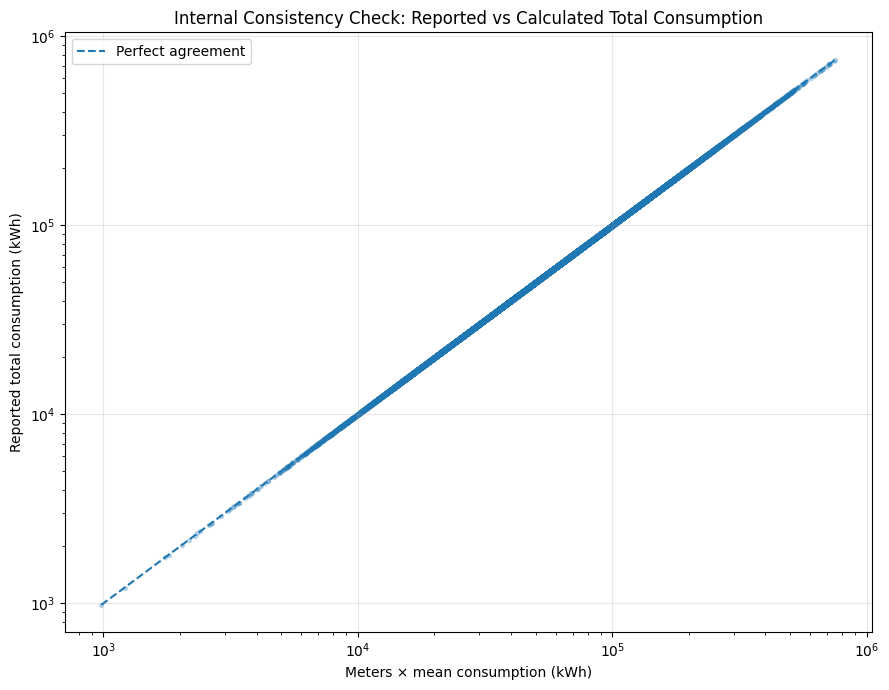

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/eda_scatter_total_vs_meters_mean.png


In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    consistency_sample_df["calculated_total_kwh"],
    consistency_sample_df["total_kwh"],
    alpha=0.25,
    s=8
)

# Add reference line
minimum_value = min(
    consistency_sample_df["calculated_total_kwh"].min(),
    consistency_sample_df["total_kwh"].min()
)

maximum_value = max(
    consistency_sample_df["calculated_total_kwh"].max(),
    consistency_sample_df["total_kwh"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5,
    label="Perfect agreement"
)

# Log scales make the heavy-tailed values easier to view
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Meters × mean consumption (kWh)")
plt.ylabel("Reported total consumption (kWh)")
plt.title(
    "Internal Consistency Check: Reported vs Calculated Total Consumption"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

consistency_figure = (
    FIGURES_DIR /
    "eda_scatter_total_vs_meters_mean.png"
)

plt.savefig(
    consistency_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", consistency_figure)

##Annual trend analysis

load anual data summary

In [27]:
import pandas as pd

YEARLY_SUMMARY_FILE = (
    TABLES_DIR /
    "eda_yearly_summary.csv"
)

yearly_summary_df = pd.read_csv(
    YEARLY_SUMMARY_FILE
)

yearly_summary_df["Year"] = (
    yearly_summary_df["Year"]
    .astype(int)
)

yearly_summary_df = (
    yearly_summary_df
    .sort_values("Year")
    .reset_index(drop=True)
)

display(yearly_summary_df)

,Year,postcode_records,unique_postcodes,total_meters,total_kwh_sum,average_mean_kwh,median_mean_kwh,average_median_kwh
0,2019,1255188,1255188,27402464.0,9.971479e+10,3844.677862,3447.647168,3242.480612
1,2020,1262969,1262969,27548176.0,1.054127e+11,4047.396096,3612.300000,3377.360445
2,2021,1272081,1272081,27774985.0,9.957536e+10,3796.654940,3371.138235,3137.784091
3,2022,1281222,1281222,27942941.0,9.139278e+10,3454.379381,3052.449589,2851.437471
4,2023,1288263,1288263,28129259.0,9.363546e+10,3519.142011,3135.640741,2911.518128
5,2024,1294650,1294650,28237673.0,9.444576e+10,3543.849292,3117.261250,2885.537789


Calculate yearly changes

In [28]:
yearly_summary_df["mean_kwh_change"] = (
    yearly_summary_df["average_mean_kwh"]
    .diff()
)

yearly_summary_df["mean_kwh_change_percent"] = (
    yearly_summary_df["average_mean_kwh"]
    .pct_change()
    .mul(100)
)

yearly_summary_df["total_kwh_change_percent"] = (
    yearly_summary_df["total_kwh_sum"]
    .pct_change()
    .mul(100)
)

yearly_summary_df["meter_change_percent"] = (
    yearly_summary_df["total_meters"]
    .pct_change()
    .mul(100)
)

yearly_change_table = yearly_summary_df[
    [
        "Year",
        "average_mean_kwh",
        "mean_kwh_change",
        "mean_kwh_change_percent",
        "total_kwh_change_percent",
        "meter_change_percent"
    ]
].copy()

yearly_change_table = yearly_change_table.round(2)

print("ANNUAL CHANGE SUMMARY")
print("=" * 70)

display(yearly_change_table)

yearly_change_output = (
    TABLES_DIR /
    "eda_yearly_changes.csv"
)

yearly_change_table.to_csv(
    yearly_change_output,
    index=False
)

print("Saved:", yearly_change_output)

ANNUAL CHANGE SUMMARY


,Year,average_mean_kwh,mean_kwh_change,mean_kwh_change_percent,total_kwh_change_percent,meter_change_percent
0,2019,3844.68,NaN,NaN,NaN,NaN
1,2020,4047.40,202.72,5.27,5.71,0.53
2,2021,3796.65,-250.74,-6.20,-5.54,0.82
3,2022,3454.38,-342.28,-9.02,-8.22,0.60
4,2023,3519.14,64.76,1.87,2.45,0.67
5,2024,3543.85,24.71,0.70,0.87,0.39


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_yearly_changes.csv


Create the annual consumption trend figure

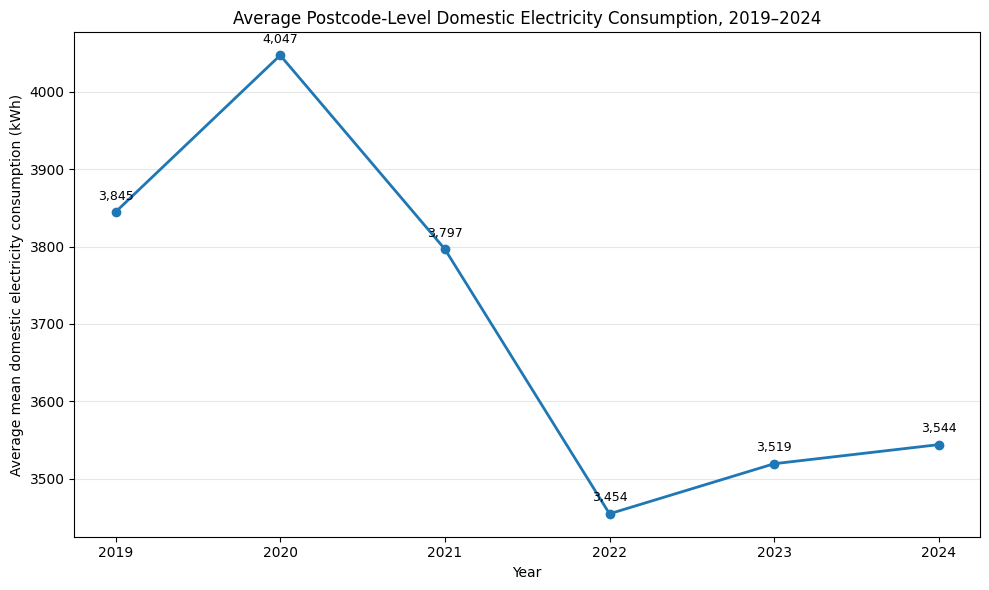

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/eda_average_mean_kwh_by_year.png


In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_summary_df["Year"],
    yearly_summary_df["average_mean_kwh"],
    marker="o",
    linewidth=2
)

# Add value labels
for year, value in zip(
    yearly_summary_df["Year"],
    yearly_summary_df["average_mean_kwh"]
):
    plt.annotate(
        f"{value:,.0f}",
        xy=(year, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.xlabel("Year")
plt.ylabel("Average mean domestic electricity consumption (kWh)")
plt.title(
    "Average Postcode-Level Domestic Electricity Consumption, 2019–2024"
)

plt.xticks(
    yearly_summary_df["Year"]
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

trend_figure = (
    FIGURES_DIR /
    "eda_average_mean_kwh_by_year.png"
)

plt.savefig(
    trend_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", trend_figure)

##Consumption distribution analysis

Calculate full-dataset distribution statistics


In [30]:
distribution_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS valid_rows,

        MIN(mean_kwh) AS minimum_mean_kwh,

        QUANTILE_CONT(
            mean_kwh,
            0.01
        ) AS percentile_1,

        QUANTILE_CONT(
            mean_kwh,
            0.25
        ) AS percentile_25,

        MEDIAN(
            mean_kwh
        ) AS median_mean_kwh,

        QUANTILE_CONT(
            mean_kwh,
            0.75
        ) AS percentile_75,

        QUANTILE_CONT(
            mean_kwh,
            0.95
        ) AS percentile_95,

        QUANTILE_CONT(
            mean_kwh,
            0.99
        ) AS percentile_99,

        MAX(mean_kwh) AS maximum_mean_kwh,

        AVG(mean_kwh) AS average_mean_kwh,

        STDDEV_SAMP(
            mean_kwh
        ) AS standard_deviation

    FROM read_parquet('{panel_path_sql}')

    WHERE mean_kwh > 0
""").df()

print("MEAN CONSUMPTION DISTRIBUTION SUMMARY")
print("=" * 70)

display(
    distribution_summary_df.round(2)
)

distribution_output = (
    TABLES_DIR /
    "eda_mean_kwh_distribution_summary.csv"
)

distribution_summary_df.to_csv(
    distribution_output,
    index=False
)

print("Saved:", distribution_output)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

MEAN CONSUMPTION DISTRIBUTION SUMMARY


,valid_rows,minimum_mean_kwh,percentile_1,percentile_25,median_mean_kwh,percentile_75,percentile_95,percentile_99,maximum_mean_kwh,average_mean_kwh,standard_deviation
0,7654373,116.9,1327.41,2634.6,3286.04,4230.58,7016.37,10334.63,90342.85,3699.14,1783.72


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/eda_mean_kwh_distribution_summary.csv


Create a reproducible distribution sample

In [31]:
distribution_sample_df = con.execute(f"""
    SELECT
        Postcode,
        Year,
        mean_kwh,
        LOG10(mean_kwh) AS log10_mean_kwh

    FROM read_parquet('{panel_path_sql}')

    WHERE
        mean_kwh > 0

        AND MOD(
            ABS(
                HASH(
                    Postcode ||
                    CAST(Year AS VARCHAR)
                )
            ),
            1000
        ) < 30

    LIMIT 200000
""").df()

print(
    "Distribution sample size:",
    f"{len(distribution_sample_df):,}"
)

display(
    distribution_sample_df.head()
)

Distribution sample size: 200,000


,Postcode,Year,mean_kwh,log10_mean_kwh
0,AB10 1PR,2019,2217.200000,3.345805
1,AB10 1RP,2019,2580.332258,3.411676
2,AB10 1RR,2019,2653.738462,3.423858
3,AB10 1UX,2019,2150.766667,3.332593
4,AB10 1XD,2019,3343.306897,3.524176


plot Raw mean consumption distribution

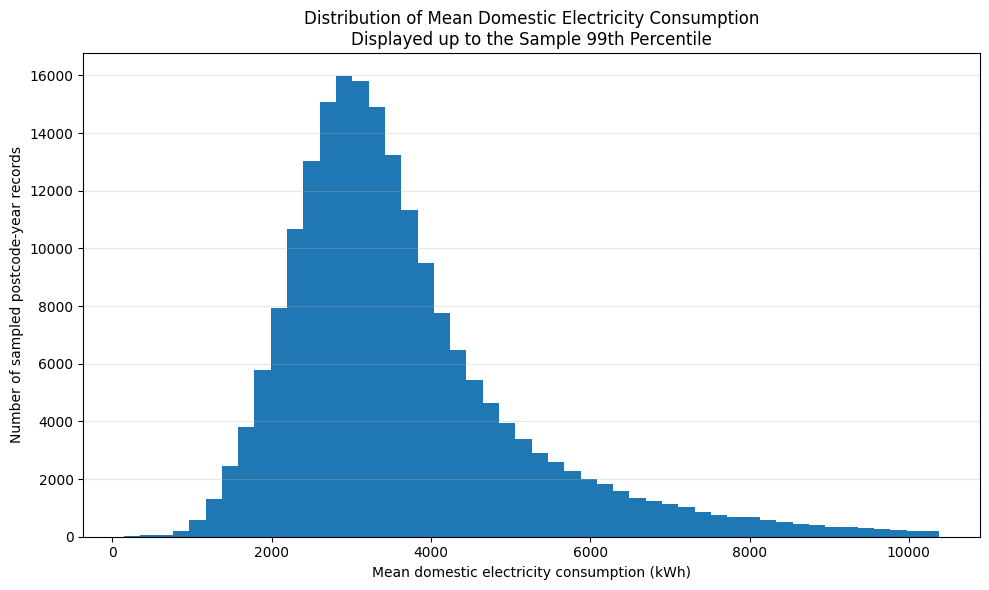

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/eda_hist_mean_kwh.png


In [32]:
plt.figure(figsize=(10, 6))

# Limit the visualisation to the 99th percentile so extreme observations do not hide the main distribution.
upper_limit = (
    distribution_sample_df["mean_kwh"]
    .quantile(0.99)
)

plot_data = distribution_sample_df.loc[
    distribution_sample_df["mean_kwh"] <= upper_limit,
    "mean_kwh"
]

plt.hist(
    plot_data,
    bins=50
)

plt.xlabel("Mean domestic electricity consumption (kWh)")
plt.ylabel("Number of sampled postcode-year records")
plt.title(
    "Distribution of Mean Domestic Electricity Consumption\n"
    "Displayed up to the Sample 99th Percentile"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

raw_histogram_file = (
    FIGURES_DIR /
    "eda_hist_mean_kwh.png"
)

plt.savefig(
    raw_histogram_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", raw_histogram_file)

plot a Log-transformed consumption distribution

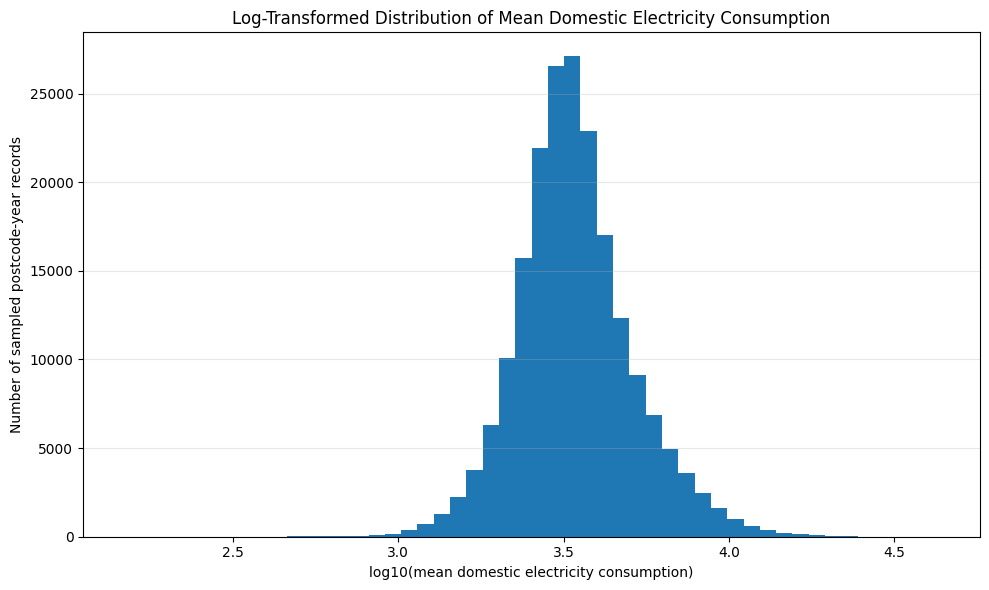

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/eda_hist_log10_mean_kwh.png


In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    distribution_sample_df["log10_mean_kwh"],
    bins=50
)

plt.xlabel("log10(mean domestic electricity consumption)")
plt.ylabel("Number of sampled postcode-year records")
plt.title(
    "Log-Transformed Distribution of Mean Domestic Electricity Consumption"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

log_histogram_file = (
    FIGURES_DIR /
    "eda_hist_log10_mean_kwh.png"
)

plt.savefig(
    log_histogram_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", log_histogram_file)

The raw consumption distribution was strongly right-skewed, with a small number of very high-consumption postcode records. A logarithmic transformation produced a more balanced distribution. This demonstrated the importance of robust model evaluation and outlier checks, while final outputs remained in original kWh units for interpretability.

##Inspecting IMD and onspd files

Inspect ONSPD and IMD file sizes

In [34]:
ONSPD_FILE = RAW_DIR / "onspd.csv"
IMD_FILE = RAW_DIR / "imd_file_7.csv"

for file_path in [ONSPD_FILE, IMD_FILE]:

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    size_mb = (
        file_path.stat().st_size /
        (1024 ** 2)
    )

    print(
        f"{file_path.name}: "
        f"{size_mb:.2f} MB"
    )

onspd.csv: 1361.06 MB
imd_file_7.csv: 9.28 MB


CSV inspection function

In [39]:
import pandas as pd
import csv


def inspect_csv_file(
    file_path,
    sample_rows=5
):
    """
    Inspect encoding, separator, columns and sample rows
    without loading the entire CSV.
    """

    print("\n" + "=" * 90)
    print("INSPECTING:", file_path.name)
    print("=" * 90)

    encodings = [
        "utf-8",
        "utf-8-sig",
        "latin-1",
        "cp1252"
    ]

    successful_encoding = None
    detected_separator = None
    sample_df = None

    for encoding in encodings:

        try:

            # Read a small text sample for delimiter detection
            with open(
                file_path,
                "r",
                encoding=encoding,
                errors="strict"
            ) as file:

                text_sample = file.read(10000)

            try:

                detected_separator = (
                    csv.Sniffer()
                    .sniff(
                        text_sample,
                        delimiters=[",", ";", "\t", "|"]
                    )
                    .delimiter
                )

            except csv.Error:
                detected_separator = ","

            sample_df = pd.read_csv(
                file_path,
                encoding=encoding,
                sep=detected_separator,
                nrows=sample_rows,
                low_memory=False
            )

            successful_encoding = encoding
            break

        except UnicodeDecodeError:
            continue

        except Exception as error:
            print(
                f"Attempt failed using {encoding}:",
                error
            )

    if sample_df is None:
        raise ValueError(
            f"Unable to inspect {file_path.name}"
        )

    print("Encoding:", successful_encoding)
    print("Separator:", repr(detected_separator))
    print("Number of columns:", len(sample_df.columns))

    print("\nCOLUMN NAMES")

    for number, column in enumerate(
        sample_df.columns,
        start=1
    ):
        print(
            f"{number}. {repr(column)}"
        )

    print("\nFIRST ROWS")

    display(
        sample_df.head(sample_rows)
    )

    print("\nSAMPLE DATA TYPES")

    print(sample_df.dtypes)

    return {
        "encoding": successful_encoding,
        "separator": detected_separator,
        "sample": sample_df
    }

Inspect ONSPD postcode lookup

In [40]:
onspd_inspection = inspect_csv_file(
    ONSPD_FILE,
    sample_rows=5
)


INSPECTING: onspd.csv
Encoding: utf-8
Separator: ','
Number of columns: 52

COLUMN NAMES
1. 'pcd'
2. 'pcd2'
3. 'pcds'
4. 'dointr'
5. 'doterm'
6. 'oscty'
7. 'ced'
8. 'oslaua'
9. 'osward'
10. 'parish'
11. 'usertype'
12. 'oseast1m'
13. 'osnrth1m'
14. 'osgrdind'
15. 'oshlthau'
16. 'nhser'
17. 'ctry'
18. 'rgn'
19. 'streg'
20. 'pcon'
21. 'eer'
22. 'teclec'
23. 'ttwa'
24. 'pct'
25. 'itl'
26. 'statsward'
27. 'oa01'
28. 'casward'
29. 'npark'
30. 'lsoa01'
31. 'msoa01'
32. 'ur01ind'
33. 'oac01'
34. 'oa11'
35. 'lsoa11'
36. 'msoa11'
37. 'wz11'
38. 'sicbl'
39. 'bua24'
40. 'ru11ind'
41. 'oac11'
42. 'lat'
43. 'long'
44. 'lep1'
45. 'lep2'
46. 'pfa'
47. 'imd'
48. 'calncv'
49. 'icb'
50. 'oa21'
51. 'lsoa21'
52. 'msoa21'

FIRST ROWS


,pcd,pcd2,pcds,dointr,doterm,oscty,ced,oslaua,osward,parish,...,long,lep1,lep2,pfa,imd,calncv,icb,oa21,lsoa21,msoa21
0,AB1 0AA,AB1 0AA,AB1 0AA,198001,199606,S99999999,S99999999,S12000033,S13002843,S99999999,...,-2.242851,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516
1,AB1 0AB,AB1 0AB,AB1 0AB,198001,199606,S99999999,S99999999,S12000033,S13002843,S99999999,...,-2.246308,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516
2,AB1 0AD,AB1 0AD,AB1 0AD,198001,199606,S99999999,S99999999,S12000033,S13002843,S99999999,...,-2.248342,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516
3,AB1 0AE,AB1 0AE,AB1 0AE,199402,199606,S99999999,S99999999,S12000034,S13002864,S99999999,...,-2.255708,S99999999,NaN,S23000009,5069,S99999999,S99999999,S00138891,S01013856,S02002577
4,AB1 0AF,AB1 0AF,AB1 0AF,199012,199207,S99999999,S99999999,S12000033,S13002843,S99999999,...,-2.258102,S99999999,NaN,S23000009,6253,S99999999,S99999999,S00137241,S01013487,S02002515



SAMPLE DATA TYPES
pcd           object
pcd2          object
pcds          object
dointr         int64
doterm         int64
oscty         object
ced           object
oslaua        object
osward        object
parish        object
usertype       int64
oseast1m       int64
osnrth1m       int64
osgrdind       int64
oshlthau      object
nhser         object
ctry          object
rgn           object
streg          int64
pcon          object
eer           object
teclec        object
ttwa          object
pct           object
itl           object
statsward     object
oa01          object
casward       object
npark         object
lsoa01        object
msoa01        object
ur01ind        int64
oac01         object
oa11          object
lsoa11        object
msoa11        object
wz11          object
sicbl         object
bua24         object
ru11ind        int64
oac11         object
lat          float64
long         float64
lep1          object
lep2         float64
pfa           object
imd            

Inspect the IMD file7

In [37]:
imd_inspection = inspect_csv_file(
    IMD_FILE,
    sample_rows=5
)


INSPECTING: imd_file_7.csv
Encoding: utf-8
Separator: ','
Number of columns: 57

COLUMN NAMES
1. 'LSOA code (2011)'
2. 'LSOA name (2011)'
3. 'Local Authority District code (2019)'
4. 'Local Authority District name (2019)'
5. 'Index of Multiple Deprivation (IMD) Score'
6. 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'
7. 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'
8. 'Income Score (rate)'
9. 'Income Rank (where 1 is most deprived)'
10. 'Income Decile (where 1 is most deprived 10% of LSOAs)'
11. 'Employment Score (rate)'
12. 'Employment Rank (where 1 is most deprived)'
13. 'Employment Decile (where 1 is most deprived 10% of LSOAs)'
14. 'Education, Skills and Training Score'
15. 'Education, Skills and Training Rank (where 1 is most deprived)'
16. 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)'
17. 'Health Deprivation and Disability Score'
18. 'Health Deprivation and Disability Rank (where 1 is

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,14745,5,0.969,4368,2,2040,522,1297,221,1285



SAMPLE DATA TYPES
LSOA code (2011)                                                                                       object
LSOA name (2011)                                                                                       object
Local Authority District code (2019)                                                                   object
Local Authority District name (2019)                                                                   object
Index of Multiple Deprivation (IMD) Score                                                             float64
Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)                                     int64
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)                      int64
Income Score (rate)                                                                                   float64
Income Rank (where 1 is most deprived)                                                               

Identify likely postcode, LSOA and IMD columns

In [38]:
onspd_columns = list(
    onspd_inspection["sample"].columns
)

imd_columns = list(
    imd_inspection["sample"].columns
)


def find_matching_columns(
    columns,
    keywords
):
    matches = []

    for column in columns:

        column_lower = str(column).lower()

        if any(
            keyword.lower() in column_lower
            for keyword in keywords
        ):
            matches.append(column)

    return matches


print("POSSIBLE ONSPD POSTCODE COLUMNS")
print(
    find_matching_columns(
        onspd_columns,
        ["pcd", "postcode"]
    )
)

print("\nPOSSIBLE ONSPD LSOA COLUMNS")
print(
    find_matching_columns(
        onspd_columns,
        ["lsoa"]
    )
)

print("\nPOSSIBLE IMD LSOA COLUMNS")
print(
    find_matching_columns(
        imd_columns,
        ["lsoa", "area code"]
    )
)

print("\nPOSSIBLE IMD SCORE COLUMNS")
print(
    find_matching_columns(
        imd_columns,
        ["imd score", "multiple deprivation score"]
    )
)

print("\nPOSSIBLE IMD RANK COLUMNS")
print(
    find_matching_columns(
        imd_columns,
        ["imd rank", "multiple deprivation rank"]
    )
)

print("\nPOSSIBLE IMD DECILE COLUMNS")
print(
    find_matching_columns(
        imd_columns,
        ["imd decile", "multiple deprivation decile"]
    )
)

POSSIBLE ONSPD POSTCODE COLUMNS
['pcd', 'pcd2', 'pcds']

POSSIBLE ONSPD LSOA COLUMNS
['lsoa01', 'lsoa11', 'lsoa21']

POSSIBLE IMD LSOA COLUMNS
['LSOA code (2011)', 'LSOA name (2011)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)', 'Crime Decile (where 1 is most deprived 10% of LSOAs)', 'Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs)', 'Living Environment Decile (where 1 is most deprived 10% of LSOAs)', 'Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Deprivation Affecting Older People (IDAOPI) Decile (where 1 is most deprived 10% of LSOAs)', 'Children and Young People Sub-domai

##Prepare ONSPD and IMD lookup data

Create a small ONSPD lookup

In [41]:
from pathlib import Path
import duckdb

ONSPD_FILE = RAW_DIR / "onspd.csv"

ONSPD_SLIM_FILE = (
    PROCESSED_DIR /
    "onspd_slim.parquet"
)

onspd_csv_sql = str(
    ONSPD_FILE
).replace("'", "''")

onspd_slim_sql = str(
    ONSPD_SLIM_FILE
).replace("'", "''")

# Delete an older output if this cell is rerun
if ONSPD_SLIM_FILE.exists():
    ONSPD_SLIM_FILE.unlink()

print("Creating slim ONSPD lookup...")
print("This may take several minutes because the source file is 1.36 GB.")

con.execute(f"""
    COPY (
        SELECT
            UPPER(TRIM(pcds)) AS Postcode,

            NULLIF(
                TRIM(lsoa11),
                ''
            ) AS LSOA11CD,

            NULLIF(
                TRIM(ctry),
                ''
            ) AS CTRYCD,

            NULLIF(
                TRIM(oslaua),
                ''
            ) AS LADCD,

            NULLIF(
                TRIM(rgn),
                ''
            ) AS RGNCD,

            NULLIF(
                TRIM(doterm),
                ''
            ) AS termination_date

        FROM read_csv_auto(
            '{onspd_csv_sql}',
            header=True,
            all_varchar=True,
            sample_size=100000
        )

        WHERE
            pcds IS NOT NULL
            AND TRIM(pcds) <> ''
    )

    TO '{onspd_slim_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
""")

size_mb = (
    ONSPD_SLIM_FILE.stat().st_size /
    (1024 ** 2)
)

print("\nSlim ONSPD lookup created successfully.")
print("Saved:", ONSPD_SLIM_FILE)
print(f"File size: {size_mb:.2f} MB")

Creating slim ONSPD lookup...
This may take several minutes because the source file is 1.36 GB.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Slim ONSPD lookup created successfully.
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/onspd_slim.parquet
File size: 6.47 MB


Validate the slim ONSPD lookup

In [42]:
country_summary_df = con.execute(f"""
    SELECT
        COALESCE(
            CTRYCD,
            'MISSING'
        ) AS country_code,

        COUNT(*) AS lookup_rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        SUM(
            CASE
                WHEN LSOA11CD IS NULL
                THEN 1
                ELSE 0
            END
        ) AS missing_lsoa11

    FROM read_parquet(
        '{onspd_slim_sql}'
    )

    GROUP BY CTRYCD

    ORDER BY lookup_rows DESC
""").df()

duplicate_postcode_df = con.execute(f"""
    SELECT
        COUNT(*) -
        COUNT(DISTINCT Postcode)
        AS duplicate_postcode_rows

    FROM read_parquet(
        '{onspd_slim_sql}'
    )
""").df()

print("ONSPD COUNTRY SUMMARY")
print("=" * 80)

display(country_summary_df)

print("\nDUPLICATE POSTCODE CHECK")
print("=" * 80)

display(duplicate_postcode_df)

ONSPD COUNTRY SUMMARY


,country_code,lookup_rows,unique_postcodes,missing_lsoa11
0,E92000001,2264910,2264910,7200.0
1,S92000003,229876,229876,457.0
2,W92000004,141600,141600,658.0
3,N92000002,62980,62980,2820.0
4,L93000001,7045,7045,0.0
5,M83000003,6095,6095,0.0



DUPLICATE POSTCODE CHECK


,duplicate_postcode_rows
0,0


Create the England-only postcode lookup,
based on above =>
Code	Country
E92000001	England
S92000003	Scotland
W92000004	Wales
N92000002	Northern Ireland

Create an England-only ONSPD lookup

In [43]:
ONSPD_ENGLAND_FILE = (
    PROCESSED_DIR /
    "onspd_england_lookup.parquet"
)

onspd_england_sql = str(
    ONSPD_ENGLAND_FILE
).replace("'", "''")

if ONSPD_ENGLAND_FILE.exists():
    ONSPD_ENGLAND_FILE.unlink()

con.execute(f"""
    COPY (
        SELECT
            Postcode,
            LSOA11CD,
            LADCD,
            RGNCD,
            termination_date

        FROM read_parquet(
            '{onspd_slim_sql}'
        )

        WHERE
            CTRYCD = 'E92000001'
            AND LSOA11CD IS NOT NULL
            AND LSOA11CD LIKE 'E%'
    )

    TO '{onspd_england_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
""")

england_lookup_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS lookup_rows,
        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,
        COUNT(
            DISTINCT LSOA11CD
        ) AS unique_lsoa11,
        COUNT(
            DISTINCT LADCD
        ) AS unique_local_authorities,
        COUNT(
            DISTINCT RGNCD
        ) AS unique_regions

    FROM read_parquet(
        '{onspd_england_sql}'
    )
""").df()

print("ENGLAND LOOKUP SUMMARY")
print("=" * 80)

display(england_lookup_summary_df)

print("Saved:", ONSPD_ENGLAND_FILE)

ENGLAND LOOKUP SUMMARY


,lookup_rows,unique_postcodes,unique_lsoa11,unique_local_authorities,unique_regions
0,2257710,2257710,32844,296,9


Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/onspd_england_lookup.parquet


Clean IMD File 7

In [44]:
import pandas as pd

IMD_FILE = RAW_DIR / "imd_file_7.csv"

IMD_CLEAN_FILE = (
    PROCESSED_DIR /
    "imd_2019_clean.parquet"
)

LSOA_COLUMN = "LSOA code (2011)"

LAD_CODE_COLUMN = (
    "Local Authority District code (2019)"
)

LAD_NAME_COLUMN = (
    "Local Authority District name (2019)"
)

IMD_SCORE_COLUMN = (
    "Index of Multiple Deprivation (IMD) Score"
)

IMD_RANK_COLUMN = (
    "Index of Multiple Deprivation (IMD) Rank "
    "(where 1 is most deprived)"
)

IMD_DECILE_COLUMN = (
    "Index of Multiple Deprivation (IMD) Decile "
    "(where 1 is most deprived 10% of LSOAs)"
)

imd_df = pd.read_csv(
    IMD_FILE,
    encoding="utf-8",
    usecols=[
        LSOA_COLUMN,
        LAD_CODE_COLUMN,
        LAD_NAME_COLUMN,
        IMD_SCORE_COLUMN,
        IMD_RANK_COLUMN,
        IMD_DECILE_COLUMN
    ],
    dtype={
        LSOA_COLUMN: "string",
        LAD_CODE_COLUMN: "string",
        LAD_NAME_COLUMN: "string"
    },
    low_memory=False
)

imd_df = imd_df.rename(
    columns={
        LSOA_COLUMN: "LSOA11CD",
        LAD_CODE_COLUMN: "IMD_LADCD",
        LAD_NAME_COLUMN: "local_authority_name",
        IMD_SCORE_COLUMN: "imd_score",
        IMD_RANK_COLUMN: "imd_rank",
        IMD_DECILE_COLUMN: "imd_decile"
    }
)

# Clean code and name fields
imd_df["LSOA11CD"] = (
    imd_df["LSOA11CD"]
    .astype("string")
    .str.upper()
    .str.strip()
)

imd_df["IMD_LADCD"] = (
    imd_df["IMD_LADCD"]
    .astype("string")
    .str.upper()
    .str.strip()
)

imd_df["local_authority_name"] = (
    imd_df["local_authority_name"]
    .astype("string")
    .str.strip()
)

# Convert IMD measures safely
for column in [
    "imd_score",
    "imd_rank",
    "imd_decile"
]:
    imd_df[column] = pd.to_numeric(
        imd_df[column],
        errors="coerce"
    )

# Sort for consistency
imd_df = (
    imd_df
    .sort_values("LSOA11CD")
    .reset_index(drop=True)
)

print("IMD CLEANING SUMMARY")
print("=" * 80)

print(f"Rows: {len(imd_df):,}")
print(
    "Unique LSOAs:",
    f"{imd_df['LSOA11CD'].nunique():,}"
)

print(
    "Duplicate LSOA rows:",
    imd_df.duplicated(
        subset=["LSOA11CD"]
    ).sum()
)

print("\nMissing values:")

display(
    imd_df.isna()
    .sum()
    .to_frame("Missing values")
)

print(
    "\nIMD deciles:",
    sorted(
        imd_df["imd_decile"]
        .dropna()
        .unique()
        .tolist()
    )
)

display(imd_df.head())

imd_df.to_parquet(
    IMD_CLEAN_FILE,
    index=False
)

print("\nSaved:", IMD_CLEAN_FILE)

IMD CLEANING SUMMARY
Rows: 32,844
Unique LSOAs: 32,844
Duplicate LSOA rows: 0

Missing values:


,Missing values
LSOA11CD,0
IMD_LADCD,0
local_authority_name,0
imd_score,0
imd_rank,0
imd_decile,0



IMD deciles: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,LSOA11CD,IMD_LADCD,local_authority_name,imd_score,imd_rank,imd_decile
0,E01000001,E09000001,City of London,6.208,29199,9
1,E01000002,E09000001,City of London,5.143,30379,10
2,E01000003,E09000001,City of London,19.402,14915,5
3,E01000005,E09000001,City of London,28.652,8678,3
4,E01000006,E09000002,Barking and Dagenham,19.837,14486,5



Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/imd_2019_clean.parquet


Check ONSPD-to-IMD linkage coverage

In [45]:
imd_clean_sql = str(
    IMD_CLEAN_FILE
).replace("'", "''")

linkage_coverage_df = con.execute(f"""
    SELECT
        COUNT(*) AS england_postcode_rows,

        SUM(
            CASE
                WHEN i.LSOA11CD IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) AS postcodes_matched_to_imd,

        SUM(
            CASE
                WHEN i.LSOA11CD IS NULL
                THEN 1
                ELSE 0
            END
        ) AS postcodes_not_matched_to_imd,

        ROUND(
            100.0 *
            SUM(
                CASE
                    WHEN i.LSOA11CD IS NOT NULL
                    THEN 1
                    ELSE 0
                END
            ) /
            COUNT(*),
            4
        ) AS linkage_percentage

    FROM read_parquet(
        '{onspd_england_sql}'
    ) o

    LEFT JOIN read_parquet(
        '{imd_clean_sql}'
    ) i

    ON o.LSOA11CD = i.LSOA11CD
""").df()

print("ONSPD TO IMD LINKAGE COVERAGE")
print("=" * 80)

display(linkage_coverage_df)

ONSPD TO IMD LINKAGE COVERAGE


,england_postcode_rows,postcodes_matched_to_imd,postcodes_not_matched_to_imd,linkage_percentage
0,2257710,2257710.0,0.0,100.0


Check electricity panel records by country
- confirms why the filtering of england only dataset is neccessary

In [46]:
electricity_country_df = con.execute(f"""
    SELECT
        COALESCE(
            o.CTRYCD,
            'UNMATCHED'
        ) AS country_code,

        COUNT(*) AS panel_rows,

        COUNT(
            DISTINCT p.Postcode
        ) AS unique_postcodes

    FROM read_parquet(
        '{panel_path_sql}'
    ) p

    LEFT JOIN read_parquet(
        '{onspd_slim_sql}'
    ) o

    ON p.Postcode = o.Postcode

    GROUP BY
        COALESCE(
            o.CTRYCD,
            'UNMATCHED'
        )

    ORDER BY panel_rows DESC
""").df()

country_names = {
    "E92000001": "England",
    "S92000003": "Scotland",
    "W92000004": "Wales",
    "N92000002": "Northern Ireland",
    "UNMATCHED": "Unmatched"
}

electricity_country_df["country_name"] = (
    electricity_country_df["country_code"]
    .map(country_names)
    .fillna("Other")
)

electricity_country_df = electricity_country_df[
    [
        "country_code",
        "country_name",
        "panel_rows",
        "unique_postcodes"
    ]
]

print("ELECTRICITY PANEL COUNTRY COVERAGE")
print("=" * 80)

display(electricity_country_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ELECTRICITY PANEL COUNTRY COVERAGE


,country_code,country_name,panel_rows,unique_postcodes
0,E92000001,England,6540756,1116900
1,S92000003,Scotland,718898,122694
2,W92000004,Wales,393961,67132
3,UNMATCHED,Unmatched,758,758


##Build the final England-only electricity panel with IMD

In [47]:
from pathlib import Path
import duckdb
import os

ENGLAND_PANEL_FILE = (
    PROCESSED_DIR /
    "england_electricity_panel_with_imd_2019_2024.parquet"
)

# Convert paths safely for DuckDB SQL
england_panel_sql = str(
    ENGLAND_PANEL_FILE
).replace("'", "''")

panel_path_sql = str(
    PANEL_FILE
).replace("'", "''")

onspd_england_sql = str(
    ONSPD_ENGLAND_FILE
).replace("'", "''")

imd_clean_sql = str(
    IMD_CLEAN_FILE
).replace("'", "''")

# Allow DuckDB to use temporary local storage if needed
os.makedirs(
    "/content/duckdb_temp",
    exist_ok=True
)

con.execute(
    "PRAGMA temp_directory='/content/duckdb_temp'"
)

con.execute(
    "SET preserve_insertion_order=false"
)

print("Output file:")
print(ENGLAND_PANEL_FILE)

Output file:
/content/drive/MyDrive/energy_poverty_colab/data/processed/england_electricity_panel_with_imd_2019_2024.parquet


Calculate the expected England row count

In [48]:
expected_england_df = con.execute(f"""
    SELECT
        COUNT(*) AS expected_england_rows,
        COUNT(
            DISTINCT p.Postcode
        ) AS expected_unique_postcodes

    FROM read_parquet(
        '{panel_path_sql}'
    ) p

    INNER JOIN read_parquet(
        '{onspd_england_sql}'
    ) o

    ON p.Postcode = o.Postcode
""").df()

print("EXPECTED ENGLAND PANEL SIZE")
print("=" * 80)

display(expected_england_df)

expected_england_rows = int(
    expected_england_df.loc[
        0,
        "expected_england_rows"
    ]
)

expected_england_postcodes = int(
    expected_england_df.loc[
        0,
        "expected_unique_postcodes"
    ]
)

EXPECTED ENGLAND PANEL SIZE


,expected_england_rows,expected_unique_postcodes
0,6540754,1116898


Build the England-only electricity panel with IMD

In [49]:
if ENGLAND_PANEL_FILE.exists():
    ENGLAND_PANEL_FILE.unlink()

print("Building England electricity panel with IMD...")
print("This may take several minutes.")

con.execute(f"""
    COPY (
        SELECT
            p.Postcode,
            p.Year,
            p.OUTWARD,
            p.SECTOR,

            p.meters,
            p.total_kwh,
            p.mean_kwh,
            p.median_kwh,

            o.LSOA11CD,

            i.IMD_LADCD AS LADCD,

            i.local_authority_name,

            o.RGNCD,

            i.imd_score,

            CAST(
                i.imd_rank AS INTEGER
            ) AS imd_rank,

            CAST(
                i.imd_decile AS TINYINT
            ) AS imd_decile

        FROM read_parquet(
            '{panel_path_sql}'
        ) p

        INNER JOIN read_parquet(
            '{onspd_england_sql}'
        ) o

        ON p.Postcode = o.Postcode

        INNER JOIN read_parquet(
            '{imd_clean_sql}'
        ) i

        ON o.LSOA11CD = i.LSOA11CD

        ORDER BY
            p.Postcode,
            p.Year
    )

    TO '{england_panel_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD,
        ROW_GROUP_SIZE 250000
    )
""")

file_size_mb = (
    ENGLAND_PANEL_FILE.stat().st_size /
    (1024 ** 2)
)

print("\nEngland panel created successfully.")
print("Saved:", ENGLAND_PANEL_FILE)
print(f"File size: {file_size_mb:.2f} MB")

Building England electricity panel with IMD...
This may take several minutes.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


England panel created successfully.
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/england_electricity_panel_with_imd_2019_2024.parquet
File size: 93.84 MB


Validate the England panel with IMD

In [50]:
england_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        COUNT(
            DISTINCT LSOA11CD
        ) AS unique_lsoas,

        COUNT(
            DISTINCT LADCD
        ) AS unique_local_authorities,

        COUNT(
            DISTINCT RGNCD
        ) AS unique_regions,

        MIN(Year) AS minimum_year,

        MAX(Year) AS maximum_year,

        MIN(imd_decile) AS minimum_imd_decile,

        MAX(imd_decile) AS maximum_imd_decile

    FROM read_parquet(
        '{england_panel_sql}'
    )
""").df()

print("FINAL ENGLAND PANEL SUMMARY")
print("=" * 80)

display(england_summary_df)

actual_england_rows = int(
    england_summary_df.loc[0, "rows"]
)

actual_england_postcodes = int(
    england_summary_df.loc[
        0,
        "unique_postcodes"
    ]
)

print("\nVALIDATION RESULTS")
print("=" * 80)

print(
    f"Expected rows: {expected_england_rows:,}"
)

print(
    f"Actual rows:   {actual_england_rows:,}"
)

print(
    f"Expected unique postcodes: "
    f"{expected_england_postcodes:,}"
)

print(
    f"Actual unique postcodes:   "
    f"{actual_england_postcodes:,}"
)

if (
    actual_england_rows == expected_england_rows
    and
    actual_england_postcodes ==
    expected_england_postcodes
):
    print(
        "\nPASS: England panel size is correct."
    )
else:
    print(
        "\nWARNING: England panel size does not match."
    )

FINAL ENGLAND PANEL SUMMARY


,rows,unique_postcodes,unique_lsoas,unique_local_authorities,unique_regions,minimum_year,maximum_year,minimum_imd_decile,maximum_imd_decile
0,6540754,1116898,32844,317,9,2019,2024,1,10



VALIDATION RESULTS
Expected rows: 6,540,754
Actual rows:   6,540,754
Expected unique postcodes: 1,116,898
Actual unique postcodes:   1,116,898

PASS: England panel size is correct.


Missing-value check for the final England panel

In [51]:
england_columns = [
    "Postcode",
    "Year",
    "OUTWARD",
    "SECTOR",
    "meters",
    "total_kwh",
    "mean_kwh",
    "median_kwh",
    "LSOA11CD",
    "LADCD",
    "local_authority_name",
    "RGNCD",
    "imd_score",
    "imd_rank",
    "imd_decile"
]

missing_expressions = []

for column in england_columns:

    missing_expressions.append(
        f"""
        SUM(
            CASE
                WHEN "{column}" IS NULL
                THEN 1
                ELSE 0
            END
        ) AS "{column}"
        """
    )

missing_sql = ",\n".join(
    missing_expressions
)

england_missing_wide_df = con.execute(f"""
    SELECT
        {missing_sql}

    FROM read_parquet(
        '{england_panel_sql}'
    )
""").df()

england_missing_rows = []

for column in england_columns:

    missing_count = int(
        england_missing_wide_df.loc[
            0,
            column
        ]
    )

    missing_percentage = (
        missing_count /
        actual_england_rows *
        100
    )

    england_missing_rows.append({
        "Column": column,
        "Missing_values": missing_count,
        "Missing_percentage": round(
            missing_percentage,
            6
        )
    })

england_missing_df = pd.DataFrame(
    england_missing_rows
)

print("FINAL ENGLAND PANEL MISSINGNESS")
print("=" * 80)

display(england_missing_df)

england_missing_output = (
    TABLES_DIR /
    "england_panel_missingness.csv"
)

england_missing_df.to_csv(
    england_missing_output,
    index=False
)

print("Saved:", england_missing_output)

FINAL ENGLAND PANEL MISSINGNESS


,Column,Missing_values,Missing_percentage
0,Postcode,0,0.0
1,Year,0,0.0
2,OUTWARD,0,0.0
3,SECTOR,0,0.0
4,meters,0,0.0
5,total_kwh,0,0.0
6,mean_kwh,0,0.0
7,median_kwh,0,0.0
8,LSOA11CD,0,0.0
9,LADCD,0,0.0


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/england_panel_missingness.csv


England panel records by year

In [52]:
england_yearly_counts_df = con.execute(f"""
    SELECT
        Year,

        COUNT(*) AS postcode_records,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        COUNT(
            DISTINCT LSOA11CD
        ) AS unique_lsoas,

        SUM(meters) AS total_meters,

        SUM(total_kwh) AS total_kwh

    FROM read_parquet(
        '{england_panel_sql}'
    )

    GROUP BY Year

    ORDER BY Year
""").df()

print("ENGLAND PANEL RECORDS BY YEAR")
print("=" * 80)

display(england_yearly_counts_df)

england_yearly_output = (
    TABLES_DIR /
    "england_yearly_summary.csv"
)

england_yearly_counts_df.to_csv(
    england_yearly_output,
    index=False
)

print("Saved:", england_yearly_output)

ENGLAND PANEL RECORDS BY YEAR


,Year,postcode_records,unique_postcodes,unique_lsoas,total_meters,total_kwh
0,2019,1071817,1071817,32844,23414738.0,8.572146e+10
1,2020,1078795,1078795,32844,23549675.0,9.077735e+10
2,2021,1086921,1086921,32844,23753149.0,8.578043e+10
3,2022,1095103,1095103,32844,23912553.0,7.885289e+10
4,2023,1101452,1101452,32844,24080207.0,8.087339e+10
5,2024,1106666,1106666,32844,24175189.0,8.152068e+10


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/england_yearly_summary.csv


IMD decile distribution

In [53]:
imd_distribution_df = con.execute(f"""
    SELECT
        imd_decile,

        COUNT(*) AS postcode_year_records,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        COUNT(
            DISTINCT LSOA11CD
        ) AS unique_lsoas,

        ROUND(
            100.0 * COUNT(*) /
            SUM(
                COUNT(*)
            ) OVER (),
            2
        ) AS percentage_of_records

    FROM read_parquet(
        '{england_panel_sql}'
    )

    GROUP BY imd_decile

    ORDER BY imd_decile
""").df()

print("IMD DECILE DISTRIBUTION")
print("=" * 80)

display(imd_distribution_df)

imd_distribution_output = (
    TABLES_DIR /
    "imd_decile_distribution.csv"
)

imd_distribution_df.to_csv(
    imd_distribution_output,
    index=False
)

print("Saved:", imd_distribution_output)

IMD DECILE DISTRIBUTION


,imd_decile,postcode_year_records,unique_postcodes,unique_lsoas,percentage_of_records
0,1,602573,102477,3284,9.21
1,2,585089,99594,3284,8.95
2,3,601543,102336,3285,9.20
3,4,643329,109805,3284,9.84
4,5,670174,114564,3285,10.25
5,6,701234,120141,3284,10.72
6,7,692381,118809,3284,10.59
7,8,692651,118553,3285,10.59
8,9,682633,116728,3284,10.44
9,10,669147,113891,3285,10.23


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/imd_decile_distribution.csv


Final duplicate check

In [54]:
duplicate_check_df = con.execute(f"""
    SELECT
        COALESCE(
            SUM(record_count - 1),
            0
        ) AS duplicate_postcode_year_rows

    FROM (
        SELECT
            Postcode,
            Year,
            COUNT(*) AS record_count

        FROM read_parquet(
            '{england_panel_sql}'
        )

        GROUP BY
            Postcode,
            Year

        HAVING COUNT(*) > 1
    )
""").df()

print("DUPLICATE POSTCODE-YEAR CHECK")
print("=" * 80)

display(duplicate_check_df)

DUPLICATE POSTCODE-YEAR CHECK


,duplicate_postcode_year_rows
0,0.0


View a sample of the final England dataset

In [55]:
england_sample_df = con.execute(f"""
    SELECT *

    FROM read_parquet(
        '{england_panel_sql}'
    )

    LIMIT 10
""").df()

display(england_sample_df)

print("\nColumns:")
print(england_sample_df.columns.tolist())

print("\nData types:")
print(england_sample_df.dtypes)

,Postcode,Year,OUTWARD,SECTOR,meters,total_kwh,mean_kwh,median_kwh,LSOA11CD,LADCD,local_authority_name,RGNCD,imd_score,imd_rank,imd_decile
0,AL1 1AG,2019,AL1,AL1 1,5,16468.000,3293.600000,2301.60,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
1,AL1 1AG,2020,AL1,AL1 1,5,14666.100,2933.220000,2244.40,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
2,AL1 1AG,2021,AL1,AL1 1,5,15087.200,3017.440000,2013.50,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
3,AL1 1AG,2022,AL1,AL1 1,5,13836.600,2767.320000,2107.90,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
4,AL1 1AG,2023,AL1,AL1 1,5,13934.100,2786.820000,3387.90,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
5,AL1 1AG,2024,AL1,AL1 1,5,12328.500,2465.700000,2254.50,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
6,AL1 1AJ,2019,AL1,AL1 1,49,143871.000,2936.142857,2476.70,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
7,AL1 1AJ,2020,AL1,AL1 1,50,154467.700,3089.354000,2646.75,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
8,AL1 1AJ,2021,AL1,AL1 1,51,145839.872,2859.605333,2491.10,E01023741,E07000240,St Albans,E12000006,5.447,30070,10
9,AL1 1AJ,2022,AL1,AL1 1,50,143174.500,2863.490000,2586.30,E01023741,E07000240,St Albans,E12000006,5.447,30070,10



Columns:
['Postcode', 'Year', 'OUTWARD', 'SECTOR', 'meters', 'total_kwh', 'mean_kwh', 'median_kwh', 'LSOA11CD', 'LADCD', 'local_authority_name', 'RGNCD', 'imd_score', 'imd_rank', 'imd_decile']

Data types:
Postcode                 object
Year                      int64
OUTWARD                  object
SECTOR                   object
meters                    int64
total_kwh               float64
mean_kwh                float64
median_kwh              float64
LSOA11CD                 object
LADCD                    object
local_authority_name     object
RGNCD                    object
imd_score               float64
imd_rank                  int32
imd_decile                 int8
dtype: object


the analysis is genuinely restricted to Englan.
every included postcode has an English 2011 LSOA.
all LSOAs link to IMD successfully.
IMD is no longer replaced with a constant value of five.
deprivation subgroup analysis becomes possible.
the risk score will no longer become NaN because of missing IMD values.

##Create leakage-free forecasting features

Prepare the feature dataset path

In [56]:
FORECAST_FEATURE_FILE = (
    PROCESSED_DIR /
    "forecast_features_2021_2024.parquet"
)

forecast_feature_sql = str(
    FORECAST_FEATURE_FILE
).replace("'", "''")

england_panel_sql = str(
    ENGLAND_PANEL_FILE
).replace("'", "''")

print("England source panel:")
print(ENGLAND_PANEL_FILE)

print("\nForecast feature output:")
print(FORECAST_FEATURE_FILE)

England source panel:
/content/drive/MyDrive/energy_poverty_colab/data/processed/england_electricity_panel_with_imd_2019_2024.parquet

Forecast feature output:
/content/drive/MyDrive/energy_poverty_colab/data/processed/forecast_features_2021_2024.parquet


Create leakage-free lagged forecasting features

In [57]:
if FORECAST_FEATURE_FILE.exists():
    FORECAST_FEATURE_FILE.unlink()

print("Creating forecasting features...")
print("This may take several minutes.")

con.execute("SET preserve_insertion_order=false")

con.execute(f"""
    COPY (
        WITH lagged_data AS (
            SELECT
                Postcode,
                Year,
                OUTWARD,
                SECTOR,
                LSOA11CD,
                LADCD,
                local_authority_name,
                RGNCD,

                imd_score,
                imd_rank,
                imd_decile,

                meters,
                total_kwh,
                mean_kwh,
                median_kwh,

                LAG(Year, 1) OVER postcode_window
                    AS lag1_year,

                LAG(Year, 2) OVER postcode_window
                    AS lag2_year,

                LAG(meters, 1) OVER postcode_window
                    AS lag1_meters,

                LAG(meters, 2) OVER postcode_window
                    AS lag2_meters,

                LAG(total_kwh, 1) OVER postcode_window
                    AS lag1_total_kwh,

                LAG(total_kwh, 2) OVER postcode_window
                    AS lag2_total_kwh,

                LAG(mean_kwh, 1) OVER postcode_window
                    AS lag1_mean_kwh,

                LAG(mean_kwh, 2) OVER postcode_window
                    AS lag2_mean_kwh,

                LAG(median_kwh, 1) OVER postcode_window
                    AS lag1_median_kwh,

                LAG(median_kwh, 2) OVER postcode_window
                    AS lag2_median_kwh

            FROM read_parquet(
                '{england_panel_sql}'
            )

            WINDOW postcode_window AS (
                PARTITION BY Postcode
                ORDER BY Year
            )
        )

        SELECT
            -- Identification fields retained for outputs,
            -- but not all will be used as model features
            Postcode,
            Year AS target_year,
            OUTWARD,
            SECTOR,
            LSOA11CD,
            LADCD,
            local_authority_name,
            RGNCD,

            -- Static vulnerability context
            imd_score,
            imd_rank,
            imd_decile,

            -- Forecast target
            total_kwh AS target_total_kwh,

            LN(
                1.0 + total_kwh
            ) AS target_log_total_kwh,

            -- Naive baseline
            lag1_total_kwh
                AS baseline_prediction_kwh,

            -- Previous-year features
            lag1_meters,
            lag1_total_kwh,
            lag1_mean_kwh,
            lag1_median_kwh,

            -- Two-years-previous features
            lag2_meters,
            lag2_total_kwh,
            lag2_mean_kwh,
            lag2_median_kwh,

            -- Log-transformed lag features
            LN(
                1.0 + lag1_total_kwh
            ) AS log_lag1_total_kwh,

            LN(
                1.0 + lag2_total_kwh
            ) AS log_lag2_total_kwh,

            LN(
                1.0 + lag1_meters
            ) AS log_lag1_meters,

            LN(
                1.0 + lag2_meters
            ) AS log_lag2_meters,

            -- Previous change in total consumption
            lag1_total_kwh - lag2_total_kwh
                AS prior_total_change_kwh,

            100.0 * (
                lag1_total_kwh -
                lag2_total_kwh
            ) / NULLIF(
                lag2_total_kwh,
                0
            ) AS prior_total_change_percent,

            -- Previous change in meter count
            lag1_meters - lag2_meters
                AS prior_meter_change,

            100.0 * (
                lag1_meters -
                lag2_meters
            ) / NULLIF(
                lag2_meters,
                0
            ) AS prior_meter_change_percent,

            -- Previous change in mean consumption
            lag1_mean_kwh - lag2_mean_kwh
                AS prior_mean_change_kwh,

            100.0 * (
                lag1_mean_kwh -
                lag2_mean_kwh
            ) / NULLIF(
                lag2_mean_kwh,
                0
            ) AS prior_mean_change_percent,

            -- Relationship between mean and median consumption
            lag1_mean_kwh / NULLIF(
                lag1_median_kwh,
                0
            ) AS lag1_mean_median_ratio

        FROM lagged_data

        WHERE
            Year BETWEEN 2021 AND 2024

            -- Require genuinely consecutive historical years
            AND lag1_year = Year - 1
            AND lag2_year = Year - 2

            -- Require valid positive historical values
            AND lag1_meters > 0
            AND lag2_meters > 0

            AND lag1_total_kwh > 0
            AND lag2_total_kwh > 0

            AND lag1_mean_kwh > 0
            AND lag2_mean_kwh > 0

            AND lag1_median_kwh > 0
            AND lag2_median_kwh > 0

            AND total_kwh > 0
    )

    TO '{forecast_feature_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
""")

feature_size_mb = (
    FORECAST_FEATURE_FILE.stat().st_size /
    (1024 ** 2)
)

print("\nForecast feature dataset created successfully.")
print("Saved:", FORECAST_FEATURE_FILE)
print(f"File size: {feature_size_mb:.2f} MB")

Creating forecasting features...
This may take several minutes.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Forecast feature dataset created successfully.
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/forecast_features_2021_2024.parquet
File size: 408.59 MB


Validate forecasting feature dataset

In [58]:
feature_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        MIN(target_year) AS minimum_target_year,

        MAX(target_year) AS maximum_target_year,

        MIN(imd_decile) AS minimum_imd_decile,

        MAX(imd_decile) AS maximum_imd_decile,

        MIN(target_total_kwh)
            AS minimum_target_kwh,

        MAX(target_total_kwh)
            AS maximum_target_kwh

    FROM read_parquet(
        '{forecast_feature_sql}'
    )
""").df()

print("FORECAST FEATURE DATASET SUMMARY")
print("=" * 80)

display(feature_summary_df)

FORECAST FEATURE DATASET SUMMARY


,rows,unique_postcodes,minimum_target_year,maximum_target_year,minimum_imd_decile,maximum_imd_decile,minimum_target_kwh,maximum_target_kwh
0,4301530,1096489,2021,2024,1,10,739.6,2389496.076


Forecast records by target year

In [59]:
feature_year_counts_df = con.execute(f"""
    SELECT
        target_year,

        COUNT(*) AS modelling_rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        COUNT(
            DISTINCT LSOA11CD
        ) AS unique_lsoas,

        AVG(target_total_kwh)
            AS average_target_kwh,

        MEDIAN(target_total_kwh)
            AS median_target_kwh,

        AVG(baseline_prediction_kwh)
            AS average_baseline_prediction

    FROM read_parquet(
        '{forecast_feature_sql}'
    )

    GROUP BY target_year

    ORDER BY target_year
""").df()

feature_year_counts_display = (
    feature_year_counts_df.copy()
)

for column in [
    "average_target_kwh",
    "median_target_kwh",
    "average_baseline_prediction"
]:
    feature_year_counts_display[column] = (
        feature_year_counts_display[column]
        .round(2)
    )

print("MODELLING RECORDS BY TARGET YEAR")
print("=" * 80)

display(feature_year_counts_display)

feature_year_counts_df.to_csv(
    TABLES_DIR /
    "forecast_feature_year_counts.csv",
    index=False
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

MODELLING RECORDS BY TARGET YEAR


,target_year,modelling_rows,unique_postcodes,unique_lsoas,average_target_kwh,median_target_kwh,average_baseline_prediction
0,2021,1064793,1064793,32844,79706.86,65058.40,84824.07
1,2022,1071479,1071479,32844,72731.11,59179.15,79598.10
2,2023,1079068,1079068,32844,74085.29,60510.19,72613.05
3,2024,1086190,1086190,32844,74207.61,60317.80,74013.63


Check missing values in modelling fields

In [60]:
modelling_columns = [
    "target_year",
    "imd_score",
    "imd_rank",
    "imd_decile",
    "target_total_kwh",
    "target_log_total_kwh",
    "baseline_prediction_kwh",
    "lag1_meters",
    "lag1_total_kwh",
    "lag1_mean_kwh",
    "lag1_median_kwh",
    "lag2_meters",
    "lag2_total_kwh",
    "lag2_mean_kwh",
    "lag2_median_kwh",
    "log_lag1_total_kwh",
    "log_lag2_total_kwh",
    "log_lag1_meters",
    "log_lag2_meters",
    "prior_total_change_kwh",
    "prior_total_change_percent",
    "prior_meter_change",
    "prior_meter_change_percent",
    "prior_mean_change_kwh",
    "prior_mean_change_percent",
    "lag1_mean_median_ratio"
]

missing_expressions = []

for column in modelling_columns:

    missing_expressions.append(
        f"""
        SUM(
            CASE
                WHEN "{column}" IS NULL
                THEN 1
                ELSE 0
            END
        ) AS "{column}"
        """
    )

feature_missing_wide_df = con.execute(f"""
    SELECT
        {",".join(missing_expressions)}

    FROM read_parquet(
        '{forecast_feature_sql}'
    )
""").df()

feature_row_count = int(
    feature_summary_df.loc[0, "rows"]
)

feature_missing_rows = []

for column in modelling_columns:

    missing_count = int(
        feature_missing_wide_df.loc[
            0,
            column
        ]
    )

    feature_missing_rows.append({
        "Column": column,
        "Missing_values": missing_count,
        "Missing_percentage": round(
            missing_count /
            feature_row_count *
            100,
            6
        )
    })

feature_missing_df = pd.DataFrame(
    feature_missing_rows
)

print("FORECAST FEATURE MISSINGNESS")
print("=" * 80)

display(feature_missing_df)

feature_missing_df.to_csv(
    TABLES_DIR /
    "forecast_feature_missingness.csv",
    index=False
)

FORECAST FEATURE MISSINGNESS


,Column,Missing_values,Missing_percentage
0,target_year,0,0.0
1,imd_score,0,0.0
2,imd_rank,0,0.0
3,imd_decile,0,0.0
4,target_total_kwh,0,0.0
5,target_log_total_kwh,0,0.0
6,baseline_prediction_kwh,0,0.0
7,lag1_meters,0,0.0
8,lag1_total_kwh,0,0.0
9,lag1_mean_kwh,0,0.0


Duplicate check

In [61]:
feature_duplicate_df = con.execute(f"""
    SELECT
        COALESCE(
            SUM(record_count - 1),
            0
        ) AS duplicate_postcode_target_year_rows

    FROM (
        SELECT
            Postcode,
            target_year,
            COUNT(*) AS record_count

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        GROUP BY
            Postcode,
            target_year

        HAVING COUNT(*) > 1
    )
""").df()

print("FORECAST FEATURE DUPLICATE CHECK")
print("=" * 80)

display(feature_duplicate_df)

FORECAST FEATURE DUPLICATE CHECK


,duplicate_postcode_target_year_rows
0,0.0


Inspect change-feature distributions

In [62]:
change_summary_df = con.execute(f"""
    SELECT
        MIN(prior_total_change_percent)
            AS minimum_total_change_percent,

        QUANTILE_CONT(
            prior_total_change_percent,
            0.01
        ) AS total_change_percentile_1,

        MEDIAN(
            prior_total_change_percent
        ) AS median_total_change_percent,

        QUANTILE_CONT(
            prior_total_change_percent,
            0.99
        ) AS total_change_percentile_99,

        MAX(prior_total_change_percent)
            AS maximum_total_change_percent,

        MIN(prior_meter_change_percent)
            AS minimum_meter_change_percent,

        QUANTILE_CONT(
            prior_meter_change_percent,
            0.01
        ) AS meter_change_percentile_1,

        MEDIAN(
            prior_meter_change_percent
        ) AS median_meter_change_percent,

        QUANTILE_CONT(
            prior_meter_change_percent,
            0.99
        ) AS meter_change_percentile_99,

        MAX(prior_meter_change_percent)
            AS maximum_meter_change_percent

    FROM read_parquet(
        '{forecast_feature_sql}'
    )
""").df()

print("CHANGE FEATURE DISTRIBUTIONS")
print("=" * 80)

display(
    change_summary_df.round(2)
)

change_summary_df.to_csv(
    TABLES_DIR /
    "forecast_change_feature_summary.csv",
    index=False
)

CHANGE FEATURE DISTRIBUTIONS


,minimum_total_change_percent,total_change_percentile_1,median_total_change_percent,total_change_percentile_99,maximum_total_change_percent,minimum_meter_change_percent,meter_change_percentile_1,median_meter_change_percent,meter_change_percentile_99,maximum_meter_change_percent
0,-97.78,-39.75,-1.9,71.95,12552.04,-89.47,-14.29,0.0,20.0,2660.0


Inspect forecasting feature sample

In [63]:
feature_sample_df = con.execute(f"""
    SELECT
        Postcode,
        target_year,
        RGNCD,
        imd_decile,

        target_total_kwh,
        baseline_prediction_kwh,

        lag1_total_kwh,
        lag2_total_kwh,

        prior_total_change_percent,

        lag1_meters,
        lag2_meters,

        prior_meter_change_percent

    FROM read_parquet(
        '{forecast_feature_sql}'
    )

    ORDER BY
        Postcode,
        target_year

    LIMIT 15
""").df()

display(feature_sample_df)

,Postcode,target_year,RGNCD,imd_decile,target_total_kwh,baseline_prediction_kwh,lag1_total_kwh,lag2_total_kwh,prior_total_change_percent,lag1_meters,lag2_meters,prior_meter_change_percent
0,AL1 1AG,2021,E12000006,10,15087.200,14666.100,14666.100,16468.000,-10.941827,5,5,0.000000
1,AL1 1AG,2022,E12000006,10,13836.600,15087.200,15087.200,14666.100,2.871247,5,5,0.000000
2,AL1 1AG,2023,E12000006,10,13934.100,13836.600,13836.600,15087.200,-8.289146,5,5,0.000000
3,AL1 1AG,2024,E12000006,10,12328.500,13934.100,13934.100,13836.600,0.704653,5,5,0.000000
4,AL1 1AJ,2021,E12000006,10,145839.872,154467.700,154467.700,143871.000,7.365418,50,49,2.040816
5,AL1 1AJ,2022,E12000006,10,143174.500,145839.872,145839.872,154467.700,-5.585522,51,50,2.000000
6,AL1 1AJ,2023,E12000006,10,145899.100,143174.500,143174.500,145839.872,-1.827602,50,51,-1.960784
7,AL1 1AJ,2024,E12000006,10,142622.900,145899.100,145899.100,143174.500,1.902993,51,50,2.000000
8,AL1 1AR,2021,E12000006,9,47082.400,59331.900,59331.900,46934.200,26.415066,19,20,-5.000000
9,AL1 1AR,2022,E12000006,9,60543.413,47082.400,47082.400,59331.900,-20.645723,19,19,0.000000


##Create the model-comparison sample and baseline

Create a deterministic longitudinal model-comparison sample

In [64]:
MODEL_SAMPLE_FILE = (
    PROCESSED_DIR /
    "model_comparison_sample_5pct.parquet"
)

model_sample_sql = str(
    MODEL_SAMPLE_FILE
).replace("'", "''")

forecast_feature_sql = str(
    FORECAST_FEATURE_FILE
).replace("'", "''")

if MODEL_SAMPLE_FILE.exists():
    MODEL_SAMPLE_FILE.unlink()

print("Creating deterministic 5% postcode sample...")

con.execute(f"""
    COPY (
        SELECT *

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        WHERE
            MOD(
                HASH(Postcode),
                20
            ) = 0
    )

    TO '{model_sample_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
""")

sample_size_mb = (
    MODEL_SAMPLE_FILE.stat().st_size /
    (1024 ** 2)
)

print("Sample created successfully.")
print("Saved:", MODEL_SAMPLE_FILE)
print(f"File size: {sample_size_mb:.2f} MB")

Creating deterministic 5% postcode sample...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sample created successfully.
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/model_comparison_sample_5pct.parquet
File size: 20.82 MB


Validate the model-comparison sample

In [65]:
sample_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS sample_rows,

        COUNT(
            DISTINCT Postcode
        ) AS sample_unique_postcodes,

        MIN(target_year) AS minimum_target_year,

        MAX(target_year) AS maximum_target_year,

        MIN(imd_decile) AS minimum_imd_decile,

        MAX(imd_decile) AS maximum_imd_decile

    FROM read_parquet(
        '{model_sample_sql}'
    )
""").df()

full_feature_rows = int(
    feature_summary_df.loc[0, "rows"]
)

sample_rows = int(
    sample_summary_df.loc[0, "sample_rows"]
)

sample_summary_df[
    "percentage_of_full_rows"
] = round(
    sample_rows /
    full_feature_rows *
    100,
    3
)

print("MODEL-COMPARISON SAMPLE SUMMARY")
print("=" * 80)

display(sample_summary_df)

MODEL-COMPARISON SAMPLE SUMMARY


,sample_rows,sample_unique_postcodes,minimum_target_year,maximum_target_year,minimum_imd_decile,maximum_imd_decile,percentage_of_full_rows
0,212700,54246,2021,2024,1,10,4.945


Compare full and sampled records by target year

In [66]:
sample_year_comparison_df = con.execute(f"""
    WITH full_years AS (
        SELECT
            target_year,
            COUNT(*) AS full_rows,
            COUNT(
                DISTINCT Postcode
            ) AS full_postcodes

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        GROUP BY target_year
    ),

    sample_years AS (
        SELECT
            target_year,
            COUNT(*) AS sample_rows,
            COUNT(
                DISTINCT Postcode
            ) AS sample_postcodes

        FROM read_parquet(
            '{model_sample_sql}'
        )

        GROUP BY target_year
    )

    SELECT
        f.target_year,

        f.full_rows,
        s.sample_rows,

        ROUND(
            100.0 *
            s.sample_rows /
            f.full_rows,
            3
        ) AS sampled_row_percentage,

        f.full_postcodes,
        s.sample_postcodes,

        ROUND(
            100.0 *
            s.sample_postcodes /
            f.full_postcodes,
            3
        ) AS sampled_postcode_percentage

    FROM full_years f

    INNER JOIN sample_years s
        ON f.target_year = s.target_year

    ORDER BY f.target_year
""").df()

print("SAMPLE COVERAGE BY YEAR")
print("=" * 80)

display(sample_year_comparison_df)

sample_year_comparison_df.to_csv(
    TABLES_DIR /
    "model_sample_year_coverage.csv",
    index=False
)

SAMPLE COVERAGE BY YEAR


,target_year,full_rows,sample_rows,sampled_row_percentage,full_postcodes,sample_postcodes,sampled_postcode_percentage
0,2021,1064793,52671,4.947,1064793,52671,4.947
1,2022,1071479,52962,4.943,1071479,52962,4.943
2,2023,1079068,53351,4.944,1079068,53351,4.944
3,2024,1086190,53716,4.945,1086190,53716,4.945


Compare full and sample IMD distributions

In [67]:
sample_imd_comparison_df = con.execute(f"""
    WITH full_distribution AS (
        SELECT
            imd_decile,
            COUNT(*) AS full_records,

            100.0 * COUNT(*) /
            SUM(
                COUNT(*)
            ) OVER () AS full_percentage

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        GROUP BY imd_decile
    ),

    sample_distribution AS (
        SELECT
            imd_decile,
            COUNT(*) AS sample_records,

            100.0 * COUNT(*) /
            SUM(
                COUNT(*)
            ) OVER () AS sample_percentage

        FROM read_parquet(
            '{model_sample_sql}'
        )

        GROUP BY imd_decile
    )

    SELECT
        f.imd_decile,

        f.full_records,
        s.sample_records,

        ROUND(
            f.full_percentage,
            3
        ) AS full_percentage,

        ROUND(
            s.sample_percentage,
            3
        ) AS sample_percentage,

        ROUND(
            s.sample_percentage -
            f.full_percentage,
            3
        ) AS percentage_point_difference

    FROM full_distribution f

    INNER JOIN sample_distribution s
        ON f.imd_decile = s.imd_decile

    ORDER BY f.imd_decile
""").df()

print("FULL DATA VS SAMPLE IMD DISTRIBUTION")
print("=" * 80)

display(sample_imd_comparison_df)

sample_imd_comparison_df.to_csv(
    TABLES_DIR /
    "model_sample_imd_comparison.csv",
    index=False
)

FULL DATA VS SAMPLE IMD DISTRIBUTION


,imd_decile,full_records,sample_records,full_percentage,sample_percentage,percentage_point_difference
0,1,396771,19879,9.224,9.346,0.122
1,2,385470,19228,8.961,9.040,0.079
2,3,396272,20038,9.212,9.421,0.208
3,4,423033,21100,9.834,9.920,0.086
4,5,440282,22069,10.235,10.376,0.140
5,6,460328,22526,10.701,10.591,-0.111
6,7,454262,22707,10.560,10.676,0.115
7,8,455098,22064,10.580,10.373,-0.207
8,9,448874,21838,10.435,10.267,-0.168
9,10,441140,21251,10.255,9.991,-0.264


Compare target distributions by year

In [68]:
sample_target_comparison_df = con.execute(f"""
    WITH full_targets AS (
        SELECT
            target_year,

            AVG(target_total_kwh)
                AS full_average_kwh,

            MEDIAN(target_total_kwh)
                AS full_median_kwh

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        GROUP BY target_year
    ),

    sample_targets AS (
        SELECT
            target_year,

            AVG(target_total_kwh)
                AS sample_average_kwh,

            MEDIAN(target_total_kwh)
                AS sample_median_kwh

        FROM read_parquet(
            '{model_sample_sql}'
        )

        GROUP BY target_year
    )

    SELECT
        f.target_year,

        ROUND(
            f.full_average_kwh,
            2
        ) AS full_average_kwh,

        ROUND(
            s.sample_average_kwh,
            2
        ) AS sample_average_kwh,

        ROUND(
            100.0 * (
                s.sample_average_kwh -
                f.full_average_kwh
            ) /
            f.full_average_kwh,
            3
        ) AS average_difference_percent,

        ROUND(
            f.full_median_kwh,
            2
        ) AS full_median_kwh,

        ROUND(
            s.sample_median_kwh,
            2
        ) AS sample_median_kwh,

        ROUND(
            100.0 * (
                s.sample_median_kwh -
                f.full_median_kwh
            ) /
            f.full_median_kwh,
            3
        ) AS median_difference_percent

    FROM full_targets f

    INNER JOIN sample_targets s
        ON f.target_year = s.target_year

    ORDER BY f.target_year
""").df()

print("FULL DATA VS SAMPLE TARGET DISTRIBUTION")
print("=" * 80)

display(sample_target_comparison_df)

sample_target_comparison_df.to_csv(
    TABLES_DIR /
    "model_sample_target_comparison.csv",
    index=False
)

FULL DATA VS SAMPLE TARGET DISTRIBUTION


,target_year,full_average_kwh,sample_average_kwh,average_difference_percent,full_median_kwh,sample_median_kwh,median_difference_percent
0,2021,79706.86,80245.05,0.675,65058.40,65403.10,0.530
1,2022,72731.11,73197.47,0.641,59179.15,59571.88,0.664
2,2023,74085.29,74564.30,0.647,60510.19,60770.17,0.430
3,2024,74207.61,74677.08,0.633,60317.80,60719.93,0.667


Evaluate naive lag-1 baseline by test year

In [69]:
baseline_metrics_by_year_df = con.execute(f"""
    SELECT
        target_year AS test_year,

        'Naive Lag-1 Baseline' AS model,

        COUNT(*) AS test_rows,

        AVG(
            ABS(
                target_total_kwh -
                baseline_prediction_kwh
            )
        ) AS mae,

        SQRT(
            AVG(
                POWER(
                    target_total_kwh -
                    baseline_prediction_kwh,
                    2
                )
            )
        ) AS rmse,

        100.0 * AVG(
            ABS(
                target_total_kwh -
                baseline_prediction_kwh
            ) /
            NULLIF(
                target_total_kwh,
                0
            )
        ) AS mape_percent,

        100.0 * AVG(
            2.0 * ABS(
                target_total_kwh -
                baseline_prediction_kwh
            ) /
            NULLIF(
                ABS(target_total_kwh) +
                ABS(baseline_prediction_kwh),
                0
            )
        ) AS smape_percent

    FROM read_parquet(
        '{model_sample_sql}'
    )

    WHERE target_year IN (
        2022,
        2023,
        2024
    )

    GROUP BY target_year

    ORDER BY target_year
""").df()

print("NAIVE BASELINE METRICS BY TEST YEAR")
print("=" * 90)

display(
    baseline_metrics_by_year_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3
    })
)

NAIVE BASELINE METRICS BY TEST YEAR


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent
0,2022,Naive Lag-1 Baseline,52962,10275.34,15573.88,16.302,14.630
1,2023,Naive Lag-1 Baseline,53351,7674.88,12817.49,11.967,11.898
2,2024,Naive Lag-1 Baseline,53716,7746.36,12899.57,12.290,11.936


Overall baseline metrics across all evaluation years

In [70]:
baseline_overall_df = con.execute(f"""
    SELECT
        0 AS test_year,

        'Naive Lag-1 Baseline' AS model,

        COUNT(*) AS test_rows,

        AVG(
            ABS(
                target_total_kwh -
                baseline_prediction_kwh
            )
        ) AS mae,

        SQRT(
            AVG(
                POWER(
                    target_total_kwh -
                    baseline_prediction_kwh,
                    2
                )
            )
        ) AS rmse,

        100.0 * AVG(
            ABS(
                target_total_kwh -
                baseline_prediction_kwh
            ) /
            NULLIF(
                target_total_kwh,
                0
            )
        ) AS mape_percent,

        100.0 * AVG(
            2.0 * ABS(
                target_total_kwh -
                baseline_prediction_kwh
            ) /
            NULLIF(
                ABS(target_total_kwh) +
                ABS(baseline_prediction_kwh),
                0
            )
        ) AS smape_percent

    FROM read_parquet(
        '{model_sample_sql}'
    )

    WHERE target_year IN (
        2022,
        2023,
        2024
    )
""").df()

baseline_overall_df[
    "test_year"
] = "Overall"

baseline_metrics_df = pd.concat(
    [
        baseline_metrics_by_year_df,
        baseline_overall_df
    ],
    ignore_index=True
)

print("FINAL BASELINE EVALUATION")
print("=" * 90)

display(
    baseline_metrics_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3
    })
)

BASELINE_METRICS_FILE = (
    TABLES_DIR /
    "baseline_model_metrics.csv"
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_FILE,
    index=False
)

print("Saved:", BASELINE_METRICS_FILE)

FINAL BASELINE EVALUATION


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent
0,2022,Naive Lag-1 Baseline,52962,10275.34,15573.88,16.302,14.630
1,2023,Naive Lag-1 Baseline,53351,7674.88,12817.49,11.967,11.898
2,2024,Naive Lag-1 Baseline,53716,7746.36,12899.57,12.290,11.936
3,Overall,Naive Lag-1 Baseline,160029,8559.50,13816.52,13.510,12.815


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/baseline_model_metrics.csv


Save model-comparison configuration

In [71]:
model_configuration_df = pd.DataFrame([
    {
        "Setting": "Sample method",
        "Value": "Deterministic postcode hash sample"
    },
    {
        "Setting": "Sample proportion",
        "Value": "Approximately 5%"
    },
    {
        "Setting": "Sample rule",
        "Value": "MOD(HASH(Postcode), 20) = 0"
    },
    {
        "Setting": "Training target",
        "Value": "target_total_kwh"
    },
    {
        "Setting": "Evaluation test years",
        "Value": "2022, 2023, 2024"
    },
    {
        "Setting": "Validation method",
        "Value": "Rolling-origin temporal evaluation"
    },
    {
        "Setting": "Baseline",
        "Value": "Previous-year total consumption"
    },
    {
        "Setting": "Machine-learning algorithms",
        "Value": (
            "Ridge Regression; Random Forest; "
            "Extra Trees; HistGradientBoosting"
        )
    },
    {
        "Setting": "Main selection metric",
        "Value": "Average MAE across test folds"
    },
    {
        "Setting": "Supporting metrics",
        "Value": "RMSE, MAPE, sMAPE and R-squared"
    },
    {
        "Setting": "Extreme predictor handling",
        "Value": (
            "Training-fold 1st/99th percentile "
            "clipping for percentage-change predictors"
        )
    }
])

display(model_configuration_df)

model_configuration_df.to_csv(
    TABLES_DIR /
    "model_comparison_configuration.csv",
    index=False
)

,Setting,Value
0,Sample method,Deterministic postcode hash sample
1,Sample proportion,Approximately 5%
2,Sample rule,"MOD(HASH(Postcode), 20) = 0"
3,Training target,target_total_kwh
4,Evaluation test years,"2022, 2023, 2024"
5,Validation method,Rolling-origin temporal evaluation
6,Baseline,Previous-year total consumption
7,Machine-learning algorithms,Ridge Regression; Random Forest; Extra Trees; ...
8,Main selection metric,Average MAE across test folds
9,Supporting metrics,"RMSE, MAPE, sMAPE and R-squared"


##Algorithm 01 -Ridge Regression

Import modelling libraries

In [72]:
import time
import gc
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("scikit-learn version:", sklearn.__version__)
print("Libraries imported successfully.")

scikit-learn version: 1.6.1
Libraries imported successfully.


Define model features

In [73]:
NUMERIC_FEATURES = [
    "target_year",

    # Deprivation context
    "imd_score",
    "imd_decile",

    # Meter history
    "lag1_meters",
    "lag2_meters",

    # Total consumption history
    "lag1_total_kwh",
    "lag2_total_kwh",

    # Mean consumption history
    "lag1_mean_kwh",
    "lag2_mean_kwh",

    # Median consumption history
    "lag1_median_kwh",
    "lag2_median_kwh",

    # Log-transformed historical features
    "log_lag1_total_kwh",
    "log_lag2_total_kwh",
    "log_lag1_meters",
    "log_lag2_meters",

    # Historical percentage changes
    "prior_total_change_percent",
    "prior_meter_change_percent",
    "prior_mean_change_percent",

    # Distribution relationship
    "lag1_mean_median_ratio"
]

CATEGORICAL_FEATURES = [
    "RGNCD",
    "LADCD"
]

TARGET_COLUMN = "target_total_kwh"

IDENTIFIER_COLUMNS = [
    "Postcode",
    "target_year"
]

BASELINE_COLUMN = "baseline_prediction_kwh"

CLIP_FEATURES = [
    "prior_total_change_percent",
    "prior_meter_change_percent",
    "prior_mean_change_percent"
]

ALL_MODEL_FEATURES = (
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
)

print("Numerical features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Total input fields:", len(ALL_MODEL_FEATURES))

Numerical features: 19
Categorical features: 2
Total input fields: 21


Load only the required modelling columns

In [74]:
from pathlib import Path

MODEL_SAMPLE_FILE = (
    PROCESSED_DIR /
    "model_comparison_sample_5pct.parquet"
)

columns_to_load = list(dict.fromkeys(
    IDENTIFIER_COLUMNS +
    ALL_MODEL_FEATURES +
    [
        TARGET_COLUMN,
        BASELINE_COLUMN
    ]
))

print("Loading model-comparison sample...")

model_df = pd.read_parquet(
    MODEL_SAMPLE_FILE,
    columns=columns_to_load
)

model_df = (
    model_df
    .sort_values(
        ["target_year", "Postcode"]
    )
    .reset_index(drop=True)
)

print("Sample loaded successfully.")
print("Shape:", model_df.shape)

display(model_df.head())

Loading model-comparison sample...
Sample loaded successfully.
Shape: (212700, 24)


,Postcode,target_year,imd_score,imd_decile,lag1_meters,lag2_meters,lag1_total_kwh,lag2_total_kwh,lag1_mean_kwh,lag2_mean_kwh,...,log_lag1_meters,log_lag2_meters,prior_total_change_percent,prior_meter_change_percent,prior_mean_change_percent,lag1_mean_median_ratio,RGNCD,LADCD,target_total_kwh,baseline_prediction_kwh
0,AL1 1EX,2021,6.228,9,9,10,22970.1,23283.5,2552.233333,2328.350000,...,2.302585,2.397895,-1.346018,-10.0,9.615536,1.195425,E12000006,E07000240,22244.6,22970.1
1,AL1 1HR,2021,7.498,9,12,12,33586.0,39987.2,2798.833333,3332.266667,...,2.564949,2.564949,-16.008123,0.0,-16.008123,1.016556,E12000006,E07000240,33660.9,33586.0
2,AL1 1RF,2021,7.498,9,27,27,78636.9,75283.4,2912.477778,2788.274074,...,3.332205,3.332205,4.454501,0.0,4.454501,1.046449,E12000006,E07000240,85866.2,78636.9
3,AL1 1RQ,2021,19.140,5,20,20,41862.7,47426.9,2093.135000,2371.345000,...,3.044522,3.044522,-11.732160,0.0,-11.732160,1.009275,E12000006,E07000240,46019.5,41862.7
4,AL1 1TP,2021,6.441,9,23,25,113513.8,138736.5,4935.382609,5549.460000,...,3.178054,3.258097,-18.180291,-8.0,-11.065534,1.205722,E12000006,E07000240,115161.4,113513.8


Validate modelling fields

In [75]:
missing_count = int(
    model_df[columns_to_load]
    .isna()
    .sum()
    .sum()
)

numeric_check_columns = (
    NUMERIC_FEATURES +
    [
        TARGET_COLUMN,
        BASELINE_COLUMN
    ]
)

infinite_count = int(
    np.isinf(
        model_df[numeric_check_columns]
        .to_numpy(dtype=float)
    ).sum()
)

non_positive_targets = int(
    (model_df[TARGET_COLUMN] <= 0).sum()
)

duplicate_count = int(
    model_df.duplicated(
        subset=[
            "Postcode",
            "target_year"
        ]
    ).sum()
)

print("MODELLING DATA VALIDATION")
print("=" * 70)

print("Rows:", f"{len(model_df):,}")
print("Missing values:", missing_count)
print("Infinite numerical values:", infinite_count)
print("Non-positive targets:", non_positive_targets)
print("Duplicate postcode-year rows:", duplicate_count)

if (
    missing_count == 0
    and infinite_count == 0
    and non_positive_targets == 0
    and duplicate_count == 0
):
    print("\nPASS: Modelling data is valid.")
else:
    print("\nWARNING: Review the validation results.")

MODELLING DATA VALIDATION
Rows: 212,700
Missing values: 0
Infinite numerical values: 0
Non-positive targets: 0
Duplicate postcode-year rows: 0

PASS: Modelling data is valid.


Functions for training-only clipping

In [76]:
def calculate_clip_bounds(
    training_data,
    columns,
    lower_quantile=0.01,
    upper_quantile=0.99
):
    """
    Calculate clipping limits using training data only.
    """

    bounds = {}
    records = []

    for column in columns:

        lower_value = float(
            training_data[column]
            .quantile(lower_quantile)
        )

        upper_value = float(
            training_data[column]
            .quantile(upper_quantile)
        )

        bounds[column] = (
            lower_value,
            upper_value
        )

        records.append({
            "Feature": column,
            "Lower_bound": lower_value,
            "Upper_bound": upper_value
        })

    return bounds, pd.DataFrame(records)


def apply_clip_bounds(
    data,
    bounds
):
    """
    Apply previously calculated training limits.
    """

    clipped_data = data.copy()

    for column, (
        lower_value,
        upper_value
    ) in bounds.items():

        clipped_data[column] = (
            clipped_data[column]
            .clip(
                lower=lower_value,
                upper=upper_value
            )
        )

    return clipped_data


print("Clipping functions created successfully.")

Clipping functions created successfully.


Regression evaluation function

In [77]:
def calculate_regression_metrics(
    y_true,
    y_pred
):
    """
    Calculate evaluation metrics in original kWh units.
    """

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    absolute_error = np.abs(
        y_true - y_pred
    )

    squared_error = (
        y_true - y_pred
    ) ** 2

    mae = float(
        np.mean(absolute_error)
    )

    rmse = float(
        np.sqrt(
            np.mean(squared_error)
        )
    )

    mape_percent = float(
        100.0 *
        np.mean(
            absolute_error /
            np.maximum(
                np.abs(y_true),
                1e-9
            )
        )
    )

    smape_percent = float(
        100.0 *
        np.mean(
            2.0 * absolute_error /
            np.maximum(
                np.abs(y_true) +
                np.abs(y_pred),
                1e-9
            )
        )
    )

    r2 = float(
        r2_score(
            y_true,
            y_pred
        )
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "mape_percent": mape_percent,
        "smape_percent": smape_percent,
        "r2": r2
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


Ridge pipeline builder

In [78]:
def create_one_hot_encoder():
    """
    Create OneHotEncoder with version compatibility.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


def build_ridge_pipeline(
    alpha=10.0
):
    """
    Build a fresh preprocessing and Ridge pipeline.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                create_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    ridge_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                    max_iter=5000,
                    tol=1e-4
                )
            )
        ]
    )

    return ridge_pipeline


test_pipeline = build_ridge_pipeline()

print(test_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['target_year', 'imd_score',
                                                   'imd_decile', 'lag1_meters',
                                                   'lag2_meters',
                                                   'lag1_total_kwh',
                                                   'lag2_total_kwh',
                                                   'lag1_mean_kwh',
                                                   'lag2_mean_kwh',
                                                   'lag1_median_kwh',
                                                   'lag2_median_kwh',
                                                   'log_lag1_total_kwh',
                             

Rolling-origin Ridge evaluation

In [79]:
RIDGE_ALPHA = 10.0
TEST_YEARS = [2022, 2023, 2024]

ridge_metric_records = []
ridge_prediction_frames = []
ridge_clip_records = []

for test_year in TEST_YEARS:

    print("\n" + "=" * 90)
    print(f"RIDGE REGRESSION — TEST YEAR {test_year}")
    print("=" * 90)

    # Temporal split
    train_df = model_df.loc[
        model_df["target_year"] < test_year
    ].copy()

    test_df = model_df.loc[
        model_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print("Training rows:", f"{len(train_df):,}")
    print("Testing rows:", f"{len(test_df):,}")

    # Calculate clipping limits from training data only
    clip_bounds, clip_table = (
        calculate_clip_bounds(
            training_data=train_df,
            columns=CLIP_FEATURES,
            lower_quantile=0.01,
            upper_quantile=0.99
        )
    )

    clip_table.insert(
        0,
        "Test_year",
        test_year
    )

    ridge_clip_records.append(
        clip_table
    )

    # Apply identical training-derived limits
    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    # Create a fresh model for each temporal fold
    ridge_pipeline = build_ridge_pipeline(
        alpha=RIDGE_ALPHA
    )

    # Train
    training_start = time.perf_counter()

    ridge_pipeline.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        training_start
    )

    # Predict
    prediction_start = time.perf_counter()

    raw_predictions = ridge_pipeline.predict(
        X_test
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    # Consumption cannot be negative
    negative_prediction_count = int(
        (raw_predictions < 0).sum()
    )

    ridge_predictions = np.clip(
        raw_predictions,
        a_min=0,
        a_max=None
    )

    fold_metrics = (
        calculate_regression_metrics(
            y_true=y_test,
            y_pred=ridge_predictions
        )
    )

    metric_record = {
        "test_year": test_year,
        "model": "Ridge Regression",
        "test_rows": len(test_df),
        "alpha": RIDGE_ALPHA,
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        "negative_raw_predictions": (
            negative_prediction_count
        ),
        **fold_metrics
    }

    ridge_metric_records.append(
        metric_record
    )

    prediction_frame = pd.DataFrame({
        "Postcode": (
            test_df["Postcode"]
            .to_numpy()
        ),
        "test_year": test_year,
        "actual_kwh": y_test,
        "baseline_prediction_kwh": (
            test_df[
                BASELINE_COLUMN
            ].to_numpy(dtype=float)
        ),
        "ridge_raw_prediction_kwh": (
            raw_predictions
        ),
        "ridge_prediction_kwh": (
            ridge_predictions
        )
    })

    prediction_frame["ridge_residual_kwh"] = (
        prediction_frame["actual_kwh"] -
        prediction_frame[
            "ridge_prediction_kwh"
        ]
    )

    ridge_prediction_frames.append(
        prediction_frame
    )

    print("\nFold results")
    print("-" * 60)

    print(f"MAE:   {fold_metrics['mae']:,.2f}")
    print(f"RMSE:  {fold_metrics['rmse']:,.2f}")
    print(
        f"MAPE:  "
        f"{fold_metrics['mape_percent']:.3f}%"
    )
    print(
        f"sMAPE: "
        f"{fold_metrics['smape_percent']:.3f}%"
    )
    print(f"R²:    {fold_metrics['r2']:.5f}")

    print(
        "Negative raw predictions:",
        negative_prediction_count
    )

    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )

    # Release fold objects
    del ridge_pipeline
    del X_train
    del X_test
    del y_train
    del y_test
    del train_clipped
    del test_clipped

    gc.collect()


RIDGE REGRESSION — TEST YEAR 2022
Training years: [2021]
Training rows: 52,671
Testing rows: 52,962

Fold results
------------------------------------------------------------
MAE:   9,278.53
RMSE:  13,705.00
MAPE:  15.420%
sMAPE: 14.095%
R²:    0.93780
Negative raw predictions: 5
Training time: 0.19 seconds

RIDGE REGRESSION — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 105,633
Testing rows: 53,351

Fold results
------------------------------------------------------------
MAE:   12,969.30
RMSE:  17,113.70
MAPE:  21.720%
sMAPE: 25.861%
R²:    0.90422
Negative raw predictions: 59
Training time: 0.87 seconds

RIDGE REGRESSION — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 158,984
Testing rows: 53,716

Fold results
------------------------------------------------------------
MAE:   7,902.91
RMSE:  12,853.68
MAPE:  13.471%
sMAPE: 12.723%
R²:    0.94788
Negative raw predictions: 2
Training time: 1.08 seconds


Compile Ridge metrics

In [80]:
ridge_metrics_by_year_df = pd.DataFrame(
    ridge_metric_records
)

ridge_predictions_df = pd.concat(
    ridge_prediction_frames,
    ignore_index=True
)

overall_ridge_metrics = (
    calculate_regression_metrics(
        y_true=ridge_predictions_df[
            "actual_kwh"
        ],
        y_pred=ridge_predictions_df[
            "ridge_prediction_kwh"
        ]
    )
)

ridge_overall_record = {
    "test_year": "Overall",
    "model": "Ridge Regression",
    "test_rows": len(
        ridge_predictions_df
    ),
    "alpha": RIDGE_ALPHA,
    "training_seconds": (
        ridge_metrics_by_year_df[
            "training_seconds"
        ].sum()
    ),
    "prediction_seconds": (
        ridge_metrics_by_year_df[
            "prediction_seconds"
        ].sum()
    ),
    "negative_raw_predictions": (
        ridge_metrics_by_year_df[
            "negative_raw_predictions"
        ].sum()
    ),
    **overall_ridge_metrics
}

ridge_metrics_df = pd.concat(
    [
        ridge_metrics_by_year_df,
        pd.DataFrame(
            [ridge_overall_record]
        )
    ],
    ignore_index=True
)

print("RIDGE REGRESSION RESULTS")
print("=" * 110)

display(
    ridge_metrics_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

RIDGE REGRESSION RESULTS


,test_year,model,test_rows,alpha,training_seconds,prediction_seconds,negative_raw_predictions,mae,rmse,mape_percent,smape_percent,r2
0,2022,Ridge Regression,52962,10.0,0.19,0.07,5,9278.53,13705.00,15.420,14.095,0.93780
1,2023,Ridge Regression,53351,10.0,0.87,0.12,59,12969.30,17113.70,21.720,25.861,0.90422
2,2024,Ridge Regression,53716,10.0,1.08,0.12,2,7902.91,12853.68,13.471,12.723,0.94788
3,Overall,Ridge Regression,160029,10.0,2.14,0.31,66,10047.23,14671.75,16.866,17.557,0.93018


Save Ridge results

In [81]:
RIDGE_METRICS_FILE = (
    TABLES_DIR /
    "ridge_regression_metrics.csv"
)

RIDGE_PREDICTIONS_FILE = (
    TABLES_DIR /
    "ridge_regression_predictions.csv"
)

RIDGE_CLIP_FILE = (
    TABLES_DIR /
    "ridge_training_clip_bounds.csv"
)

ridge_clip_bounds_df = pd.concat(
    ridge_clip_records,
    ignore_index=True
)

ridge_metrics_df.to_csv(
    RIDGE_METRICS_FILE,
    index=False
)

ridge_predictions_df.to_csv(
    RIDGE_PREDICTIONS_FILE,
    index=False
)

ridge_clip_bounds_df.to_csv(
    RIDGE_CLIP_FILE,
    index=False
)

print("Saved:", RIDGE_METRICS_FILE)
print("Saved:", RIDGE_PREDICTIONS_FILE)
print("Saved:", RIDGE_CLIP_FILE)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/ridge_regression_metrics.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/ridge_regression_predictions.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/ridge_training_clip_bounds.csv


Ridge versus naive baseline

In [82]:
baseline_metrics_saved_df = pd.read_csv(
    BASELINE_METRICS_FILE
)

baseline_metrics_saved_df[
    "test_year"
] = (
    baseline_metrics_saved_df[
        "test_year"
    ].astype(str)
)

ridge_for_comparison = (
    ridge_metrics_df.copy()
)

ridge_for_comparison[
    "test_year"
] = (
    ridge_for_comparison[
        "test_year"
    ].astype(str)
)

comparison_columns = [
    "test_year",
    "model",
    "test_rows",
    "mae",
    "rmse",
    "mape_percent",
    "smape_percent"
]

ridge_baseline_comparison_df = pd.concat(
    [
        baseline_metrics_saved_df[
            comparison_columns
        ],
        ridge_for_comparison[
            comparison_columns
        ]
    ],
    ignore_index=True
)

year_order = {
    "2022": 1,
    "2023": 2,
    "2024": 3,
    "Overall": 4
}

model_order = {
    "Naive Lag-1 Baseline": 1,
    "Ridge Regression": 2
}

ridge_baseline_comparison_df[
    "year_order"
] = (
    ridge_baseline_comparison_df[
        "test_year"
    ].map(year_order)
)

ridge_baseline_comparison_df[
    "model_order"
] = (
    ridge_baseline_comparison_df[
        "model"
    ].map(model_order)
)

ridge_baseline_comparison_df = (
    ridge_baseline_comparison_df
    .sort_values(
        [
            "year_order",
            "model_order"
        ]
    )
    .drop(
        columns=[
            "year_order",
            "model_order"
        ]
    )
    .reset_index(drop=True)
)

print("RIDGE VERSUS BASELINE")
print("=" * 100)

display(
    ridge_baseline_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3
    })
)

RIDGE VERSUS BASELINE


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent
0,2022,Naive Lag-1 Baseline,52962,10275.34,15573.88,16.302,14.630
1,2022,Ridge Regression,52962,9278.53,13705.00,15.420,14.095
2,2023,Naive Lag-1 Baseline,53351,7674.88,12817.49,11.967,11.898
3,2023,Ridge Regression,53351,12969.30,17113.70,21.720,25.861
4,2024,Naive Lag-1 Baseline,53716,7746.36,12899.57,12.290,11.936
5,2024,Ridge Regression,53716,7902.91,12853.68,13.471,12.723
6,Overall,Naive Lag-1 Baseline,160029,8559.50,13816.52,13.510,12.815
7,Overall,Ridge Regression,160029,10047.23,14671.75,16.866,17.557


Calculate improvement over baseline

In [83]:
baseline_for_merge = (
    baseline_metrics_saved_df[
        [
            "test_year",
            "mae",
            "rmse",
            "mape_percent",
            "smape_percent"
        ]
    ]
    .rename(
        columns={
            "mae": "baseline_mae",
            "rmse": "baseline_rmse",
            "mape_percent": "baseline_mape",
            "smape_percent": "baseline_smape"
        }
    )
)

ridge_for_merge = (
    ridge_for_comparison[
        [
            "test_year",
            "mae",
            "rmse",
            "mape_percent",
            "smape_percent",
            "r2"
        ]
    ]
    .rename(
        columns={
            "mae": "ridge_mae",
            "rmse": "ridge_rmse",
            "mape_percent": "ridge_mape",
            "smape_percent": "ridge_smape"
        }
    )
)

ridge_improvement_df = (
    baseline_for_merge
    .merge(
        ridge_for_merge,
        on="test_year",
        how="inner"
    )
)

ridge_improvement_df[
    "mae_improvement_percent"
] = (
    100.0 *
    (
        ridge_improvement_df[
            "baseline_mae"
        ] -
        ridge_improvement_df[
            "ridge_mae"
        ]
    ) /
    ridge_improvement_df[
        "baseline_mae"
    ]
)

ridge_improvement_df[
    "rmse_improvement_percent"
] = (
    100.0 *
    (
        ridge_improvement_df[
            "baseline_rmse"
        ] -
        ridge_improvement_df[
            "ridge_rmse"
        ]
    ) /
    ridge_improvement_df[
        "baseline_rmse"
    ]
)

ridge_improvement_df[
    "mape_improvement_percent"
] = (
    100.0 *
    (
        ridge_improvement_df[
            "baseline_mape"
        ] -
        ridge_improvement_df[
            "ridge_mape"
        ]
    ) /
    ridge_improvement_df[
        "baseline_mape"
    ]
)

print("RIDGE IMPROVEMENT OVER BASELINE")
print("=" * 110)

display(
    ridge_improvement_df.round({
        "baseline_mae": 2,
        "ridge_mae": 2,
        "baseline_rmse": 2,
        "ridge_rmse": 2,
        "baseline_mape": 3,
        "ridge_mape": 3,
        "baseline_smape": 3,
        "ridge_smape": 3,
        "r2": 5,
        "mae_improvement_percent": 2,
        "rmse_improvement_percent": 2,
        "mape_improvement_percent": 2
    })
)

ridge_improvement_df.to_csv(
    TABLES_DIR /
    "ridge_vs_baseline_improvement.csv",
    index=False
)

RIDGE IMPROVEMENT OVER BASELINE


,test_year,baseline_mae,baseline_rmse,baseline_mape,baseline_smape,ridge_mae,ridge_rmse,ridge_mape,ridge_smape,r2,mae_improvement_percent,rmse_improvement_percent,mape_improvement_percent
0,2022,10275.34,15573.88,16.302,14.630,9278.53,13705.00,15.420,14.095,0.93780,9.70,12.00,5.41
1,2023,7674.88,12817.49,11.967,11.898,12969.30,17113.70,21.720,25.861,0.90422,-68.98,-33.52,-81.50
2,2024,7746.36,12899.57,12.290,11.936,7902.91,12853.68,13.471,12.723,0.94788,-2.02,0.36,-9.61
3,Overall,8559.50,13816.52,13.510,12.815,10047.23,14671.75,16.866,17.557,0.93018,-17.38,-6.19,-24.84


##Algorithm 2 — Random Forest

Create a fast 1% postcode sample

In [84]:
FAST_SAMPLE_FILE = (
    PROCESSED_DIR /
    "model_comparison_sample_1pct.parquet"
)

fast_sample_sql = str(
    FAST_SAMPLE_FILE
).replace("'", "''")

forecast_feature_sql = str(
    FORECAST_FEATURE_FILE
).replace("'", "''")

if FAST_SAMPLE_FILE.exists():
    FAST_SAMPLE_FILE.unlink()

print("Creating deterministic 1% postcode sample...")

con.execute(f"""
    COPY (
        SELECT *

        FROM read_parquet(
            '{forecast_feature_sql}'
        )

        WHERE
            MOD(
                HASH(Postcode),
                100
            ) = 0
    )

    TO '{fast_sample_sql}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
""")

print("Fast comparison sample created.")
print("Saved:", FAST_SAMPLE_FILE)

Creating deterministic 1% postcode sample...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fast comparison sample created.
Saved: /content/drive/MyDrive/energy_poverty_colab/data/processed/model_comparison_sample_1pct.parquet


Check the sample

In [85]:
fast_sample_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        MIN(target_year) AS minimum_year,

        MAX(target_year) AS maximum_year

    FROM read_parquet(
        '{fast_sample_sql}'
    )
""").df()

display(fast_sample_summary_df)

,rows,unique_postcodes,minimum_year,maximum_year
0,42340,10795,2021,2024


Load the smaller modelling sample

In [86]:
import gc
import pandas as pd
import numpy as np

# Remove the larger Pandas dataset from memory
if "model_df" in globals():
    del model_df

gc.collect()

columns_to_load = list(dict.fromkeys(
    IDENTIFIER_COLUMNS +
    ALL_MODEL_FEATURES +
    [
        TARGET_COLUMN,
        BASELINE_COLUMN
    ]
))

fast_model_df = pd.read_parquet(
    FAST_SAMPLE_FILE,
    columns=columns_to_load
)

fast_model_df = (
    fast_model_df
    .sort_values(
        ["target_year", "Postcode"]
    )
    .reset_index(drop=True)
)

print("Fast model sample loaded.")
print("Shape:", fast_model_df.shape)

display(
    fast_model_df.groupby(
        "target_year"
    ).size().rename("rows")
)

Fast model sample loaded.
Shape: (42340, 24)


,rows
target_year,
2021,10486
2022,10547
2023,10614
2024,10693


Lightweight Random Forest configuration

In [87]:
from sklearn.ensemble import RandomForestRegressor

FAST_RF_PARAMETERS = {
    "n_estimators": 40,
    "criterion": "squared_error",
    "max_depth": 12,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": 0.5,
    "bootstrap": True,
    "max_samples": 0.35,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": 1
}


def build_fast_random_forest_pipeline():
    """
    Build a lightweight Random Forest pipeline for
    algorithm comparison.
    """

    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                create_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    **FAST_RF_PARAMETERS
                )
            )
        ]
    )


print("Fast Random Forest pipeline prepared.")

Fast Random Forest pipeline prepared.


Fast rolling-origin Random Forest

In [88]:
import time

TEST_YEARS = [2022, 2023, 2024]

fast_rf_metric_records = []
fast_rf_prediction_frames = []

for test_year in TEST_YEARS:

    print("\n" + "=" * 80)
    print(f"FAST RANDOM FOREST — TEST YEAR {test_year}")
    print("=" * 80)

    train_df = fast_model_df.loc[
        fast_model_df["target_year"] < test_year
    ].copy()

    test_df = fast_model_df.loc[
        fast_model_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print("Training rows:", f"{len(train_df):,}")
    print("Testing rows:", f"{len(test_df):,}")

    # Training-only clipping boundaries
    clip_bounds, _ = calculate_clip_bounds(
        training_data=train_df,
        columns=CLIP_FEATURES,
        lower_quantile=0.01,
        upper_quantile=0.99
    )

    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    model = build_fast_random_forest_pipeline()

    training_start = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        training_start
    )

    prediction_start = time.perf_counter()

    predictions = model.predict(
        X_test
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    predictions = np.clip(
        predictions,
        0,
        None
    )

    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=predictions
    )

    fast_rf_metric_records.append({
        "test_year": test_year,
        "model": "Random Forest",
        "test_rows": len(test_df),
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        **metrics
    })

    fast_rf_prediction_frames.append(
        pd.DataFrame({
            "Postcode": test_df[
                "Postcode"
            ].to_numpy(),

            "test_year": test_year,

            "actual_kwh": y_test,

            "random_forest_prediction_kwh": (
                predictions
            )
        })
    )

    print("\nResults")
    print("-" * 50)
    print(f"MAE:  {metrics['mae']:,.2f}")
    print(f"RMSE: {metrics['rmse']:,.2f}")
    print(
        f"MAPE: {metrics['mape_percent']:.3f}%"
    )
    print(
        f"sMAPE: {metrics['smape_percent']:.3f}%"
    )
    print(f"R²:   {metrics['r2']:.5f}")
    print(
        f"Training time: {training_seconds:.2f} seconds"
    )

    del model
    del train_df
    del test_df
    del train_clipped
    del test_clipped
    del X_train
    del X_test
    del y_train
    del y_test
    del predictions

    gc.collect()


FAST RANDOM FOREST — TEST YEAR 2022
Training years: [2021]
Training rows: 10,486
Testing rows: 10,547


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    2.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  40 out of  40 | elapsed:    0.0s finished



Results
--------------------------------------------------
MAE:  9,012.68
RMSE: 13,526.83
MAPE: 14.754%
sMAPE: 13.468%
R²:   0.93914
Training time: 2.38 seconds

FAST RANDOM FOREST — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 21,033
Testing rows: 10,614


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    3.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  40 out of  40 | elapsed:    0.0s finished



Results
--------------------------------------------------
MAE:  8,782.65
RMSE: 15,444.53
MAPE: 12.527%
sMAPE: 12.956%
R²:   0.92239
Training time: 3.92 seconds

FAST RANDOM FOREST — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 31,647
Testing rows: 10,693


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.



Results
--------------------------------------------------
MAE:  7,782.94
RMSE: 12,939.87
MAPE: 11.744%
sMAPE: 11.762%
R²:   0.94692
Training time: 8.41 seconds


[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    8.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  40 out of  40 | elapsed:    0.0s finished


Compile fast Random Forest results

In [89]:
fast_rf_metrics_df = pd.DataFrame(
    fast_rf_metric_records
)

fast_rf_predictions_df = pd.concat(
    fast_rf_prediction_frames,
    ignore_index=True
)

overall_fast_rf_metrics = (
    calculate_regression_metrics(
        y_true=fast_rf_predictions_df[
            "actual_kwh"
        ],
        y_pred=fast_rf_predictions_df[
            "random_forest_prediction_kwh"
        ]
    )
)

overall_row = {
    "test_year": "Overall",
    "model": "Random Forest",
    "test_rows": len(
        fast_rf_predictions_df
    ),
    "training_seconds": (
        fast_rf_metrics_df[
            "training_seconds"
        ].sum()
    ),
    "prediction_seconds": (
        fast_rf_metrics_df[
            "prediction_seconds"
        ].sum()
    ),
    **overall_fast_rf_metrics
}

fast_rf_metrics_df = pd.concat(
    [
        fast_rf_metrics_df,
        pd.DataFrame([overall_row])
    ],
    ignore_index=True
)

display(
    fast_rf_metrics_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

fast_rf_metrics_df.to_csv(
    TABLES_DIR /
    "fast_random_forest_metrics.csv",
    index=False
)

print(
    "Saved:",
    TABLES_DIR /
    "fast_random_forest_metrics.csv"
)

,test_year,model,test_rows,training_seconds,prediction_seconds,mae,rmse,mape_percent,smape_percent,r2
0,2022,Random Forest,10547,2.38,0.05,9012.68,13526.83,14.754,13.468,0.93914
1,2023,Random Forest,10614,3.92,0.05,8782.65,15444.53,12.527,12.956,0.92239
2,2024,Random Forest,10693,8.41,0.05,7782.94,12939.87,11.744,11.762,0.94692
3,Overall,Random Forest,31854,14.70,0.14,8523.22,14009.74,13.001,12.725,0.93625


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_random_forest_metrics.csv


##Recalculate baseline and Ridge on the 1% sample

Evaluate naive baseline on the same 1% sample

In [90]:
fast_baseline_records = []

for test_year in [2022, 2023, 2024]:

    test_df = fast_model_df.loc[
        fast_model_df["target_year"] == test_year
    ].copy()

    y_true = test_df[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    baseline_predictions = test_df[
        BASELINE_COLUMN
    ].to_numpy(dtype=float)

    metrics = calculate_regression_metrics(
        y_true=y_true,
        y_pred=baseline_predictions
    )

    fast_baseline_records.append({
        "test_year": test_year,
        "model": "Naive Lag-1 Baseline",
        "test_rows": len(test_df),
        **metrics
    })


fast_baseline_metrics_df = pd.DataFrame(
    fast_baseline_records
)

# Overall metrics
overall_test_df = fast_model_df.loc[
    fast_model_df["target_year"].isin(
        [2022, 2023, 2024]
    )
].copy()

overall_baseline_metrics = calculate_regression_metrics(
    y_true=overall_test_df[
        TARGET_COLUMN
    ].to_numpy(dtype=float),

    y_pred=overall_test_df[
        BASELINE_COLUMN
    ].to_numpy(dtype=float)
)

overall_baseline_row = {
    "test_year": "Overall",
    "model": "Naive Lag-1 Baseline",
    "test_rows": len(overall_test_df),
    **overall_baseline_metrics
}

fast_baseline_metrics_df = pd.concat(
    [
        fast_baseline_metrics_df,
        pd.DataFrame(
            [overall_baseline_row]
        )
    ],
    ignore_index=True
)

print("1% SAMPLE — NAIVE BASELINE RESULTS")
print("=" * 100)

display(
    fast_baseline_metrics_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

FAST_BASELINE_FILE = (
    TABLES_DIR /
    "fast_baseline_metrics.csv"
)

fast_baseline_metrics_df.to_csv(
    FAST_BASELINE_FILE,
    index=False
)

print("Saved:", FAST_BASELINE_FILE)

1% SAMPLE — NAIVE BASELINE RESULTS


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent,r2
0,2022,Naive Lag-1 Baseline,10547,10301.07,15584.88,16.158,14.542,0.91921
1,2023,Naive Lag-1 Baseline,10614,7697.98,14550.59,12.026,11.875,0.93112
2,2024,Naive Lag-1 Baseline,10693,7743.83,12683.77,12.080,11.924,0.94900
3,Overall,Naive Lag-1 Baseline,31854,8575.27,14316.88,13.412,12.774,0.93343


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_baseline_metrics.csv


Evaluate Ridge Regression on the 1% sample

In [91]:
FAST_RIDGE_ALPHA = 10.0

fast_ridge_records = []
fast_ridge_prediction_frames = []

for test_year in [2022, 2023, 2024]:

    print("\n" + "=" * 80)
    print(
        f"FAST RIDGE REGRESSION — TEST YEAR {test_year}"
    )
    print("=" * 80)

    train_df = fast_model_df.loc[
        fast_model_df["target_year"] < test_year
    ].copy()

    test_df = fast_model_df.loc[
        fast_model_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print(
        "Training rows:",
        f"{len(train_df):,}"
    )

    print(
        "Testing rows:",
        f"{len(test_df):,}"
    )

    # Training-only clipping
    clip_bounds, _ = calculate_clip_bounds(
        training_data=train_df,
        columns=CLIP_FEATURES,
        lower_quantile=0.01,
        upper_quantile=0.99
    )

    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    ridge_model = build_ridge_pipeline(
        alpha=FAST_RIDGE_ALPHA
    )

    start_time = time.perf_counter()

    ridge_model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        start_time
    )

    prediction_start = time.perf_counter()

    raw_predictions = ridge_model.predict(
        X_test
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    negative_predictions = int(
        (raw_predictions < 0).sum()
    )

    predictions = np.clip(
        raw_predictions,
        0,
        None
    )

    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=predictions
    )

    fast_ridge_records.append({
        "test_year": test_year,
        "model": "Ridge Regression",
        "test_rows": len(test_df),
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        "negative_raw_predictions": negative_predictions,
        **metrics
    })

    fast_ridge_prediction_frames.append(
        pd.DataFrame({
            "Postcode": test_df[
                "Postcode"
            ].to_numpy(),

            "test_year": test_year,

            "actual_kwh": y_test,

            "ridge_prediction_kwh": predictions
        })
    )

    print("\nResults")
    print("-" * 50)

    print(f"MAE:   {metrics['mae']:,.2f}")
    print(f"RMSE:  {metrics['rmse']:,.2f}")

    print(
        f"MAPE:  "
        f"{metrics['mape_percent']:.3f}%"
    )

    print(
        f"sMAPE: "
        f"{metrics['smape_percent']:.3f}%"
    )

    print(f"R²:    {metrics['r2']:.5f}")

    del ridge_model
    del train_df
    del test_df
    del train_clipped
    del test_clipped
    del X_train
    del X_test
    del y_train
    del y_test
    del raw_predictions
    del predictions

    gc.collect()


FAST RIDGE REGRESSION — TEST YEAR 2022
Training years: [2021]
Training rows: 10,486
Testing rows: 10,547

Results
--------------------------------------------------
MAE:   9,272.74
RMSE:  13,629.86
MAPE:  15.232%
sMAPE: 14.020%
R²:    0.93821

FAST RIDGE REGRESSION — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 21,033
Testing rows: 10,614

Results
--------------------------------------------------
MAE:   12,873.25
RMSE:  18,223.92
MAPE:  21.750%
sMAPE: 26.054%
R²:    0.89195

FAST RIDGE REGRESSION — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 31,647
Testing rows: 10,693

Results
--------------------------------------------------
MAE:   7,959.82
RMSE:  12,645.42
MAPE:  13.252%
sMAPE: 12.671%
R²:    0.94930


Compile fast Ridge results

In [92]:
fast_ridge_metrics_df = pd.DataFrame(
    fast_ridge_records
)

fast_ridge_predictions_df = pd.concat(
    fast_ridge_prediction_frames,
    ignore_index=True
)

overall_fast_ridge_metrics = (
    calculate_regression_metrics(
        y_true=fast_ridge_predictions_df[
            "actual_kwh"
        ],

        y_pred=fast_ridge_predictions_df[
            "ridge_prediction_kwh"
        ]
    )
)

fast_ridge_overall_row = {
    "test_year": "Overall",
    "model": "Ridge Regression",
    "test_rows": len(
        fast_ridge_predictions_df
    ),

    "training_seconds": (
        fast_ridge_metrics_df[
            "training_seconds"
        ].sum()
    ),

    "prediction_seconds": (
        fast_ridge_metrics_df[
            "prediction_seconds"
        ].sum()
    ),

    "negative_raw_predictions": (
        fast_ridge_metrics_df[
            "negative_raw_predictions"
        ].sum()
    ),

    **overall_fast_ridge_metrics
}

fast_ridge_metrics_df = pd.concat(
    [
        fast_ridge_metrics_df,
        pd.DataFrame(
            [fast_ridge_overall_row]
        )
    ],
    ignore_index=True
)

print("1% SAMPLE — RIDGE RESULTS")
print("=" * 110)

display(
    fast_ridge_metrics_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

FAST_RIDGE_FILE = (
    TABLES_DIR /
    "fast_ridge_metrics.csv"
)

fast_ridge_metrics_df.to_csv(
    FAST_RIDGE_FILE,
    index=False
)

print("Saved:", FAST_RIDGE_FILE)

1% SAMPLE — RIDGE RESULTS


,test_year,model,test_rows,training_seconds,prediction_seconds,negative_raw_predictions,mae,rmse,mape_percent,smape_percent,r2
0,2022,Ridge Regression,10547,0.04,0.02,0,9272.74,13629.86,15.232,14.020,0.93821
1,2023,Ridge Regression,10614,0.08,0.02,21,12873.25,18223.92,21.750,26.054,0.89195
2,2024,Ridge Regression,10693,0.11,0.02,3,7959.82,12645.42,13.252,12.671,0.94930
3,Overall,Ridge Regression,31854,0.23,0.06,24,10031.73,15028.34,16.739,17.577,0.92664


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_ridge_metrics.csv


Compare models evaluated on the same 1% sample

In [93]:
comparison_columns = [
    "test_year",
    "model",
    "test_rows",
    "mae",
    "rmse",
    "mape_percent",
    "smape_percent",
    "r2"
]

fair_comparison_df = pd.concat(
    [
        fast_baseline_metrics_df[
            comparison_columns
        ],

        fast_ridge_metrics_df[
            comparison_columns
        ],

        fast_rf_metrics_df[
            comparison_columns
        ]
    ],
    ignore_index=True
)

fair_comparison_df[
    "test_year"
] = (
    fair_comparison_df[
        "test_year"
    ].astype(str)
)

year_order = {
    "2022": 1,
    "2023": 2,
    "2024": 3,
    "Overall": 4
}

model_order = {
    "Naive Lag-1 Baseline": 1,
    "Ridge Regression": 2,
    "Random Forest": 3
}

fair_comparison_df[
    "year_order"
] = (
    fair_comparison_df[
        "test_year"
    ].map(year_order)
)

fair_comparison_df[
    "model_order"
] = (
    fair_comparison_df[
        "model"
    ].map(model_order)
)

fair_comparison_df = (
    fair_comparison_df
    .sort_values(
        [
            "year_order",
            "model_order"
        ]
    )
    .drop(
        columns=[
            "year_order",
            "model_order"
        ]
    )
    .reset_index(drop=True)
)

print("FAIR MODEL COMPARISON — SAME 1% SAMPLE")
print("=" * 120)

display(
    fair_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

fair_comparison_df.to_csv(
    TABLES_DIR /
    "fair_model_comparison_stage1.csv",
    index=False
)

FAIR MODEL COMPARISON — SAME 1% SAMPLE


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent,r2
0,2022,Naive Lag-1 Baseline,10547,10301.07,15584.88,16.158,14.542,0.91921
1,2022,Ridge Regression,10547,9272.74,13629.86,15.232,14.020,0.93821
2,2022,Random Forest,10547,9012.68,13526.83,14.754,13.468,0.93914
3,2023,Naive Lag-1 Baseline,10614,7697.98,14550.59,12.026,11.875,0.93112
4,2023,Ridge Regression,10614,12873.25,18223.92,21.750,26.054,0.89195
5,2023,Random Forest,10614,8782.65,15444.53,12.527,12.956,0.92239
6,2024,Naive Lag-1 Baseline,10693,7743.83,12683.77,12.080,11.924,0.94900
7,2024,Ridge Regression,10693,7959.82,12645.42,13.252,12.671,0.94930
8,2024,Random Forest,10693,7782.94,12939.87,11.744,11.762,0.94692
9,Overall,Naive Lag-1 Baseline,31854,8575.27,14316.88,13.412,12.774,0.93343


##Algorithm 3 — Extra Trees Regressor

Check required modelling objects

In [94]:
required_objects = [
    "fast_model_df",
    "ALL_MODEL_FEATURES",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "TARGET_COLUMN",
    "BASELINE_COLUMN",
    "CLIP_FEATURES",
    "calculate_clip_bounds",
    "apply_clip_bounds",
    "calculate_regression_metrics",
    "create_one_hot_encoder"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Please rerun the earlier setup cells. "
        f"Missing objects: {missing_objects}"
    )

print("PASS: All required modelling objects are available.")
print("Fast sample shape:", fast_model_df.shape)

PASS: All required modelling objects are available.
Fast sample shape: (42340, 24)


Import Extra Trees Regressor

In [95]:
from sklearn.ensemble import ExtraTreesRegressor

print("ExtraTreesRegressor imported successfully.")

ExtraTreesRegressor imported successfully.


Lightweight Extra Trees configuration

In [96]:
FAST_EXTRA_TREES_PARAMETERS = {
    "n_estimators": 60,
    "criterion": "squared_error",
    "max_depth": 16,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": 0.7,
    "bootstrap": False,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": 1
}

print("Extra Trees parameters:")

for parameter, value in (
    FAST_EXTRA_TREES_PARAMETERS.items()
):
    print(f"{parameter}: {value}")

Extra Trees parameters:
n_estimators: 60
criterion: squared_error
max_depth: 16
min_samples_split: 10
min_samples_leaf: 5
max_features: 0.7
bootstrap: False
n_jobs: -1
random_state: 42
verbose: 1


Extra Trees pipeline builder

In [97]:
def build_fast_extra_trees_pipeline():
    """
    Build a lightweight Extra Trees pipeline
    for fair model comparison.
    """

    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                create_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop",
        sparse_threshold=1.0
    )

    model = ExtraTreesRegressor(
        **FAST_EXTRA_TREES_PARAMETERS
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    return pipeline


extra_trees_test_pipeline = (
    build_fast_extra_trees_pipeline()
)

print(extra_trees_test_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('numeric', 'passthrough',
                                                  ['target_year', 'imd_score',
                                                   'imd_decile', 'lag1_meters',
                                                   'lag2_meters',
                                                   'lag1_total_kwh',
                                                   'lag2_total_kwh',
                                                   'lag1_mean_kwh',
                                                   'lag2_mean_kwh',
                                                   'lag1_median_kwh',
                                                   'lag2_median_kwh',
                                                   'log_lag1_total_kwh',
                                                   'log_lag2_total_kwh',
                                                 

Extra Trees smoke test

In [98]:
smoke_train_df = (
    fast_model_df.loc[
        fast_model_df["target_year"] == 2021
    ]
    .head(5000)
    .copy()
)

smoke_test_df = (
    fast_model_df.loc[
        fast_model_df["target_year"] == 2022
    ]
    .head(1000)
    .copy()
)

smoke_bounds, _ = calculate_clip_bounds(
    training_data=smoke_train_df,
    columns=CLIP_FEATURES,
    lower_quantile=0.01,
    upper_quantile=0.99
)

smoke_train_clipped = apply_clip_bounds(
    smoke_train_df,
    smoke_bounds
)

smoke_test_clipped = apply_clip_bounds(
    smoke_test_df,
    smoke_bounds
)

smoke_model = build_fast_extra_trees_pipeline()

smoke_model.fit(
    smoke_train_clipped[
        ALL_MODEL_FEATURES
    ],
    smoke_train_clipped[
        TARGET_COLUMN
    ]
)

smoke_predictions = smoke_model.predict(
    smoke_test_clipped[
        ALL_MODEL_FEATURES
    ]
)

smoke_predictions = np.clip(
    smoke_predictions,
    0,
    None
)

smoke_metrics = calculate_regression_metrics(
    y_true=smoke_test_clipped[
        TARGET_COLUMN
    ],
    y_pred=smoke_predictions
)

print("EXTRA TREES SMOKE TEST")
print("=" * 70)

print("Training rows:", len(smoke_train_df))
print("Testing rows:", len(smoke_test_df))

print(
    "Finite predictions:",
    np.isfinite(smoke_predictions).all()
)

print(
    f"MAE: {smoke_metrics['mae']:,.2f}"
)

print(
    f"RMSE: {smoke_metrics['rmse']:,.2f}"
)

if (
    len(smoke_predictions) ==
    len(smoke_test_df)
    and
    np.isfinite(smoke_predictions).all()
):
    print("\nPASS: Extra Trees pipeline works.")
else:
    print("\nWARNING: Review the smoke-test results.")

del smoke_model
del smoke_train_df
del smoke_test_df
del smoke_train_clipped
del smoke_test_clipped
del smoke_predictions

gc.collect()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    2.4s


EXTRA TREES SMOKE TEST
Training rows: 5000
Testing rows: 1000
Finite predictions: True
MAE: 9,002.78
RMSE: 13,493.28

PASS: Extra Trees pipeline works.


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    3.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  60 out of  60 | elapsed:    0.0s finished


80

Rolling-origin Extra Trees evaluation

In [99]:
TEST_YEARS = [2022, 2023, 2024]

extra_trees_metric_records = []
extra_trees_prediction_frames = []
extra_trees_clip_records = []

for test_year in TEST_YEARS:

    print("\n" + "=" * 90)
    print(
        f"EXTRA TREES — TEST YEAR {test_year}"
    )
    print("=" * 90)

    train_df = fast_model_df.loc[
        fast_model_df["target_year"] < test_year
    ].copy()

    test_df = fast_model_df.loc[
        fast_model_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print(
        "Training rows:",
        f"{len(train_df):,}"
    )

    print(
        "Testing rows:",
        f"{len(test_df):,}"
    )

    # Calculate clipping boundaries
    # using training data only
    clip_bounds, clip_table = (
        calculate_clip_bounds(
            training_data=train_df,
            columns=CLIP_FEATURES,
            lower_quantile=0.01,
            upper_quantile=0.99
        )
    )

    clip_table.insert(
        0,
        "Test_year",
        test_year
    )

    extra_trees_clip_records.append(
        clip_table
    )

    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    extra_trees_model = (
        build_fast_extra_trees_pipeline()
    )

    training_start = time.perf_counter()

    extra_trees_model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        training_start
    )

    prediction_start = time.perf_counter()

    raw_predictions = (
        extra_trees_model.predict(
            X_test
        )
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    negative_prediction_count = int(
        (raw_predictions < 0).sum()
    )

    predictions = np.clip(
        raw_predictions,
        0,
        None
    )

    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=predictions
    )

    extra_trees_metric_records.append({
        "test_year": test_year,
        "model": "Extra Trees",
        "test_rows": len(test_df),

        "n_estimators": (
            FAST_EXTRA_TREES_PARAMETERS[
                "n_estimators"
            ]
        ),

        "max_depth": (
            FAST_EXTRA_TREES_PARAMETERS[
                "max_depth"
            ]
        ),

        "min_samples_leaf": (
            FAST_EXTRA_TREES_PARAMETERS[
                "min_samples_leaf"
            ]
        ),

        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,

        "negative_raw_predictions": (
            negative_prediction_count
        ),

        **metrics
    })

    prediction_frame = pd.DataFrame({
        "Postcode": (
            test_df["Postcode"]
            .to_numpy()
        ),

        "test_year": test_year,

        "actual_kwh": y_test,

        "baseline_prediction_kwh": (
            test_df[
                BASELINE_COLUMN
            ].to_numpy(dtype=float)
        ),

        "extra_trees_prediction_kwh": (
            predictions
        )
    })

    prediction_frame[
        "extra_trees_residual_kwh"
    ] = (
        prediction_frame["actual_kwh"] -
        prediction_frame[
            "extra_trees_prediction_kwh"
        ]
    )

    extra_trees_prediction_frames.append(
        prediction_frame
    )

    print("\nFold results")
    print("-" * 60)

    print(
        f"MAE:   {metrics['mae']:,.2f}"
    )

    print(
        f"RMSE:  {metrics['rmse']:,.2f}"
    )

    print(
        f"MAPE:  "
        f"{metrics['mape_percent']:.3f}%"
    )

    print(
        f"sMAPE: "
        f"{metrics['smape_percent']:.3f}%"
    )

    print(
        f"R²:    {metrics['r2']:.5f}"
    )

    print(
        "Negative predictions:",
        negative_prediction_count
    )

    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )

    print(
        f"Prediction time: "
        f"{prediction_seconds:.2f} seconds"
    )

    del extra_trees_model
    del train_df
    del test_df
    del train_clipped
    del test_clipped
    del X_train
    del X_test
    del y_train
    del y_test
    del raw_predictions
    del predictions

    gc.collect()


EXTRA TREES — TEST YEAR 2022
Training years: [2021]
Training rows: 10,486
Testing rows: 10,547


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    8.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  60 out of  60 | elapsed:    0.1s finished



Fold results
------------------------------------------------------------
MAE:   8,980.76
RMSE:  13,426.11
MAPE:  14.755%
sMAPE: 13.459%
R²:    0.94004
Negative predictions: 0
Training time: 8.84 seconds
Prediction time: 0.08 seconds

EXTRA TREES — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 21,033
Testing rows: 10,614


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   28.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done  60 out of  60 | elapsed:    0.1s finished



Fold results
------------------------------------------------------------
MAE:   9,153.27
RMSE:  15,822.35
MAPE:  12.938%
sMAPE: 13.487%
R²:    0.91855
Negative predictions: 0
Training time: 28.00 seconds
Prediction time: 0.09 seconds

EXTRA TREES — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 31,647
Testing rows: 10,693


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   41.6s



Fold results
------------------------------------------------------------
MAE:   7,754.14
RMSE:  12,963.90
MAPE:  11.865%
sMAPE: 11.773%
R²:    0.94672
Negative predictions: 0
Training time: 53.93 seconds
Prediction time: 0.08 seconds


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   53.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  60 out of  60 | elapsed:    0.1s finished


Compile Extra Trees results

In [100]:
extra_trees_metrics_by_year_df = (
    pd.DataFrame(
        extra_trees_metric_records
    )
)

extra_trees_predictions_df = pd.concat(
    extra_trees_prediction_frames,
    ignore_index=True
)

overall_extra_trees_metrics = (
    calculate_regression_metrics(
        y_true=extra_trees_predictions_df[
            "actual_kwh"
        ],

        y_pred=extra_trees_predictions_df[
            "extra_trees_prediction_kwh"
        ]
    )
)

extra_trees_overall_row = {
    "test_year": "Overall",
    "model": "Extra Trees",

    "test_rows": len(
        extra_trees_predictions_df
    ),

    "n_estimators": (
        FAST_EXTRA_TREES_PARAMETERS[
            "n_estimators"
        ]
    ),

    "max_depth": (
        FAST_EXTRA_TREES_PARAMETERS[
            "max_depth"
        ]
    ),

    "min_samples_leaf": (
        FAST_EXTRA_TREES_PARAMETERS[
            "min_samples_leaf"
        ]
    ),

    "training_seconds": (
        extra_trees_metrics_by_year_df[
            "training_seconds"
        ].sum()
    ),

    "prediction_seconds": (
        extra_trees_metrics_by_year_df[
            "prediction_seconds"
        ].sum()
    ),

    "negative_raw_predictions": (
        extra_trees_metrics_by_year_df[
            "negative_raw_predictions"
        ].sum()
    ),

    **overall_extra_trees_metrics
}

extra_trees_metrics_df = pd.concat(
    [
        extra_trees_metrics_by_year_df,
        pd.DataFrame(
            [extra_trees_overall_row]
        )
    ],
    ignore_index=True
)

print("EXTRA TREES RESULTS")
print("=" * 120)

display(
    extra_trees_metrics_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

EXTRA TREES RESULTS


,test_year,model,test_rows,n_estimators,max_depth,min_samples_leaf,training_seconds,prediction_seconds,negative_raw_predictions,mae,rmse,mape_percent,smape_percent,r2
0,2022,Extra Trees,10547,60,16,5,8.84,0.08,0,8980.76,13426.11,14.755,13.459,0.94004
1,2023,Extra Trees,10614,60,16,5,28.00,0.09,0,9153.27,15822.35,12.938,13.487,0.91855
2,2024,Extra Trees,10693,60,16,5,53.93,0.08,0,7754.14,12963.90,11.865,11.773,0.94672
3,Overall,Extra Trees,31854,60,16,5,90.78,0.25,0,8626.48,14125.12,13.180,12.903,0.93520


Save Extra Trees outputs

In [101]:
EXTRA_TREES_METRICS_FILE = (
    TABLES_DIR /
    "fast_extra_trees_metrics.csv"
)

EXTRA_TREES_PREDICTIONS_FILE = (
    TABLES_DIR /
    "fast_extra_trees_predictions.csv"
)

EXTRA_TREES_CLIP_FILE = (
    TABLES_DIR /
    "extra_trees_training_clip_bounds.csv"
)

extra_trees_clip_bounds_df = pd.concat(
    extra_trees_clip_records,
    ignore_index=True
)

extra_trees_metrics_df.to_csv(
    EXTRA_TREES_METRICS_FILE,
    index=False
)

extra_trees_predictions_df.to_csv(
    EXTRA_TREES_PREDICTIONS_FILE,
    index=False
)

extra_trees_clip_bounds_df.to_csv(
    EXTRA_TREES_CLIP_FILE,
    index=False
)

print("Saved:", EXTRA_TREES_METRICS_FILE)
print("Saved:", EXTRA_TREES_PREDICTIONS_FILE)
print("Saved:", EXTRA_TREES_CLIP_FILE)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_extra_trees_metrics.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_extra_trees_predictions.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/extra_trees_training_clip_bounds.csv


Compare baseline, Ridge, Random Forest and Extra Trees

In [102]:
comparison_columns = [
    "test_year",
    "model",
    "test_rows",
    "mae",
    "rmse",
    "mape_percent",
    "smape_percent",
    "r2"
]

four_method_comparison_df = pd.concat(
    [
        fast_baseline_metrics_df[
            comparison_columns
        ],

        fast_ridge_metrics_df[
            comparison_columns
        ],

        fast_rf_metrics_df[
            comparison_columns
        ],

        extra_trees_metrics_df[
            comparison_columns
        ]
    ],
    ignore_index=True
)

four_method_comparison_df[
    "test_year"
] = (
    four_method_comparison_df[
        "test_year"
    ]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

year_order = {
    "2022": 1,
    "2023": 2,
    "2024": 3,
    "Overall": 4
}

model_order = {
    "Naive Lag-1 Baseline": 1,
    "Ridge Regression": 2,
    "Random Forest": 3,
    "Extra Trees": 4
}

four_method_comparison_df[
    "year_order"
] = (
    four_method_comparison_df[
        "test_year"
    ].map(year_order)
)

four_method_comparison_df[
    "model_order"
] = (
    four_method_comparison_df[
        "model"
    ].map(model_order)
)

four_method_comparison_df = (
    four_method_comparison_df
    .sort_values(
        [
            "year_order",
            "model_order"
        ]
    )
    .drop(
        columns=[
            "year_order",
            "model_order"
        ]
    )
    .reset_index(drop=True)
)

print("FAIR COMPARISON — FOUR METHODS")
print("=" * 120)

display(
    four_method_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

four_method_comparison_df.to_csv(
    TABLES_DIR /
    "fair_model_comparison_four_methods.csv",
    index=False
)

FAIR COMPARISON — FOUR METHODS


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent,r2
0,2022,Naive Lag-1 Baseline,10547,10301.07,15584.88,16.158,14.542,0.91921
1,2022,Ridge Regression,10547,9272.74,13629.86,15.232,14.020,0.93821
2,2022,Random Forest,10547,9012.68,13526.83,14.754,13.468,0.93914
3,2022,Extra Trees,10547,8980.76,13426.11,14.755,13.459,0.94004
4,2023,Naive Lag-1 Baseline,10614,7697.98,14550.59,12.026,11.875,0.93112
5,2023,Ridge Regression,10614,12873.25,18223.92,21.750,26.054,0.89195
6,2023,Random Forest,10614,8782.65,15444.53,12.527,12.956,0.92239
7,2023,Extra Trees,10614,9153.27,15822.35,12.938,13.487,0.91855
8,2024,Naive Lag-1 Baseline,10693,7743.83,12683.77,12.080,11.924,0.94900
9,2024,Ridge Regression,10693,7959.82,12645.42,13.252,12.671,0.94930


##Algorith 4 -- HistGradientBoostingRegressor

Check required objects

In [103]:
required_objects = [
    "fast_model_df",
    "ALL_MODEL_FEATURES",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "TARGET_COLUMN",
    "BASELINE_COLUMN",
    "CLIP_FEATURES",
    "calculate_clip_bounds",
    "apply_clip_bounds",
    "calculate_regression_metrics"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Please rerun the earlier setup cells. "
        f"Missing objects: {missing_objects}"
    )

print("PASS: All required objects are available.")
print("Fast sample shape:", fast_model_df.shape)

PASS: All required objects are available.
Fast sample shape: (42340, 24)


Import HistGradientBoostingRegressor

In [104]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("HistGradientBoostingRegressor imported successfully.")

HistGradientBoostingRegressor imported successfully.


Dense encoder with version compatibility

In [105]:
def create_dense_one_hot_encoder():
    """
    Create a dense one-hot encoder that works with
    recent and older scikit-learn versions.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )


print("Dense one-hot encoder function created.")

Dense one-hot encoder function created.


HistGradientBoosting configuration

In [106]:
HGB_PARAMETERS = {
    "loss": "squared_error",
    "learning_rate": 0.05,
    "max_iter": 200,
    "max_leaf_nodes": 31,
    "max_depth": None,
    "min_samples_leaf": 30,
    "l2_regularization": 1.0,
    "max_bins": 255,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 15,
    "tol": 1e-5,
    "random_state": 42,
    "verbose": 0
}

print("HistGradientBoosting parameters:")

for parameter, value in HGB_PARAMETERS.items():
    print(f"{parameter}: {value}")

HistGradientBoosting parameters:
loss: squared_error
learning_rate: 0.05
max_iter: 200
max_leaf_nodes: 31
max_depth: None
min_samples_leaf: 30
l2_regularization: 1.0
max_bins: 255
early_stopping: True
validation_fraction: 0.1
n_iter_no_change: 15
tol: 1e-05
random_state: 42
verbose: 0


Build HistGradientBoosting pipeline

In [107]:
def build_hgb_pipeline():
    """
    Build preprocessing and HistGradientBoosting pipeline.
    """

    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                create_dense_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop",
        sparse_threshold=0.0
    )

    hgb_model = HistGradientBoostingRegressor(
        **HGB_PARAMETERS
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                hgb_model
            )
        ]
    )

    return pipeline


hgb_test_pipeline = build_hgb_pipeline()

print(hgb_test_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0.0,
                                   transformers=[('numeric', 'passthrough',
                                                  ['target_year', 'imd_score',
                                                   'imd_decile', 'lag1_meters',
                                                   'lag2_meters',
                                                   'lag1_total_kwh',
                                                   'lag2_total_kwh',
                                                   'lag1_mean_kwh',
                                                   'lag2_mean_kwh',
                                                   'lag1_median_kwh',
                                                   'lag2_median_kwh',
                                                   'log_lag1_total_kwh',
                                                   'log_lag2_total_kwh',
                                                 

HistGradientBoosting smoke test

In [108]:
smoke_train_df = (
    fast_model_df.loc[
        fast_model_df["target_year"] == 2021
    ]
    .head(5000)
    .copy()
)

smoke_test_df = (
    fast_model_df.loc[
        fast_model_df["target_year"] == 2022
    ]
    .head(1000)
    .copy()
)

smoke_bounds, _ = calculate_clip_bounds(
    training_data=smoke_train_df,
    columns=CLIP_FEATURES,
    lower_quantile=0.01,
    upper_quantile=0.99
)

smoke_train_clipped = apply_clip_bounds(
    smoke_train_df,
    smoke_bounds
)

smoke_test_clipped = apply_clip_bounds(
    smoke_test_df,
    smoke_bounds
)

smoke_model = build_hgb_pipeline()

smoke_start = time.perf_counter()

smoke_model.fit(
    smoke_train_clipped[
        ALL_MODEL_FEATURES
    ],
    smoke_train_clipped[
        TARGET_COLUMN
    ]
)

smoke_training_seconds = (
    time.perf_counter() -
    smoke_start
)

smoke_predictions = smoke_model.predict(
    smoke_test_clipped[
        ALL_MODEL_FEATURES
    ]
)

smoke_predictions = np.clip(
    smoke_predictions,
    0,
    None
)

smoke_metrics = calculate_regression_metrics(
    y_true=smoke_test_clipped[
        TARGET_COLUMN
    ],
    y_pred=smoke_predictions
)

print("HISTGRADIENTBOOSTING SMOKE TEST")
print("=" * 70)

print("Training rows:", len(smoke_train_df))
print("Testing rows:", len(smoke_test_df))

print(
    "Finite predictions:",
    np.isfinite(smoke_predictions).all()
)

print(
    f"Training time: {smoke_training_seconds:.2f} seconds"
)

print(f"MAE:  {smoke_metrics['mae']:,.2f}")
print(f"RMSE: {smoke_metrics['rmse']:,.2f}")

if (
    len(smoke_predictions) == len(smoke_test_df)
    and np.isfinite(smoke_predictions).all()
):
    print("\nPASS: HistGradientBoosting pipeline works.")
else:
    print("\nWARNING: Review the smoke-test results.")

del smoke_model
del smoke_train_df
del smoke_test_df
del smoke_train_clipped
del smoke_test_clipped
del smoke_predictions

gc.collect()

HISTGRADIENTBOOSTING SMOKE TEST
Training rows: 5000
Testing rows: 1000
Finite predictions: True
Training time: 2.54 seconds
MAE:  8,984.34
RMSE: 13,511.81

PASS: HistGradientBoosting pipeline works.


32

Rolling-origin HistGradientBoosting evaluation

In [109]:
TEST_YEARS = [2022, 2023, 2024]

hgb_metric_records = []
hgb_prediction_frames = []
hgb_clip_records = []

for test_year in TEST_YEARS:

    print("\n" + "=" * 90)
    print(
        f"HISTGRADIENTBOOSTING — TEST YEAR {test_year}"
    )
    print("=" * 90)

    train_df = fast_model_df.loc[
        fast_model_df["target_year"] < test_year
    ].copy()

    test_df = fast_model_df.loc[
        fast_model_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print("Training rows:", f"{len(train_df):,}")
    print("Testing rows:", f"{len(test_df):,}")

    # Calculate clipping limits from training data only
    clip_bounds, clip_table = (
        calculate_clip_bounds(
            training_data=train_df,
            columns=CLIP_FEATURES,
            lower_quantile=0.01,
            upper_quantile=0.99
        )
    )

    clip_table.insert(
        0,
        "Test_year",
        test_year
    )

    hgb_clip_records.append(
        clip_table
    )

    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    hgb_model = build_hgb_pipeline()

    training_start = time.perf_counter()

    hgb_model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        training_start
    )

    prediction_start = time.perf_counter()

    raw_predictions = hgb_model.predict(
        X_test
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    negative_prediction_count = int(
        (raw_predictions < 0).sum()
    )

    predictions = np.clip(
        raw_predictions,
        0,
        None
    )

    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=predictions
    )

    fitted_hgb = hgb_model.named_steps["model"]

    iterations_used = getattr(
        fitted_hgb,
        "n_iter_",
        np.nan
    )

    hgb_metric_records.append({
        "test_year": test_year,
        "model": "HistGradientBoosting",
        "test_rows": len(test_df),
        "iterations_used": iterations_used,
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        "negative_raw_predictions": (
            negative_prediction_count
        ),
        **metrics
    })

    prediction_frame = pd.DataFrame({
        "Postcode": (
            test_df["Postcode"]
            .to_numpy()
        ),

        "test_year": test_year,

        "actual_kwh": y_test,

        "baseline_prediction_kwh": (
            test_df[
                BASELINE_COLUMN
            ].to_numpy(dtype=float)
        ),

        "hgb_prediction_kwh": predictions
    })

    prediction_frame[
        "hgb_residual_kwh"
    ] = (
        prediction_frame["actual_kwh"] -
        prediction_frame[
            "hgb_prediction_kwh"
        ]
    )

    hgb_prediction_frames.append(
        prediction_frame
    )

    print("\nFold results")
    print("-" * 60)

    print(f"MAE:   {metrics['mae']:,.2f}")
    print(f"RMSE:  {metrics['rmse']:,.2f}")

    print(
        f"MAPE:  "
        f"{metrics['mape_percent']:.3f}%"
    )

    print(
        f"sMAPE: "
        f"{metrics['smape_percent']:.3f}%"
    )

    print(f"R²:    {metrics['r2']:.5f}")

    print(
        "Boosting iterations used:",
        iterations_used
    )

    print(
        "Negative raw predictions:",
        negative_prediction_count
    )

    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )

    print(
        f"Prediction time: "
        f"{prediction_seconds:.2f} seconds"
    )

    del hgb_model
    del train_df
    del test_df
    del train_clipped
    del test_clipped
    del X_train
    del X_test
    del y_train
    del y_test
    del raw_predictions
    del predictions

    gc.collect()


HISTGRADIENTBOOSTING — TEST YEAR 2022
Training years: [2021]
Training rows: 10,486
Testing rows: 10,547

Fold results
------------------------------------------------------------
MAE:   9,068.72
RMSE:  13,527.33
MAPE:  15.044%
sMAPE: 13.665%
R²:    0.93913
Boosting iterations used: 134
Negative raw predictions: 0
Training time: 4.78 seconds
Prediction time: 0.23 seconds

HISTGRADIENTBOOSTING — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 21,033
Testing rows: 10,614

Fold results
------------------------------------------------------------
MAE:   9,197.38
RMSE:  15,940.80
MAPE:  12.914%
sMAPE: 13.430%
R²:    0.91732
Boosting iterations used: 143
Negative raw predictions: 0
Training time: 8.97 seconds
Prediction time: 0.25 seconds

HISTGRADIENTBOOSTING — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 31,647
Testing rows: 10,693

Fold results
------------------------------------------------------------
MAE:   7,664.55
RMSE:  12,583.31
MAPE:  12.101%
sMAPE:

Compile HistGradientBoosting results

In [110]:
hgb_metrics_by_year_df = pd.DataFrame(
    hgb_metric_records
)

hgb_predictions_df = pd.concat(
    hgb_prediction_frames,
    ignore_index=True
)

overall_hgb_metrics = calculate_regression_metrics(
    y_true=hgb_predictions_df[
        "actual_kwh"
    ],

    y_pred=hgb_predictions_df[
        "hgb_prediction_kwh"
    ]
)

hgb_overall_row = {
    "test_year": "Overall",
    "model": "HistGradientBoosting",

    "test_rows": len(
        hgb_predictions_df
    ),

    "iterations_used": (
        hgb_metrics_by_year_df[
            "iterations_used"
        ].sum()
    ),

    "training_seconds": (
        hgb_metrics_by_year_df[
            "training_seconds"
        ].sum()
    ),

    "prediction_seconds": (
        hgb_metrics_by_year_df[
            "prediction_seconds"
        ].sum()
    ),

    "negative_raw_predictions": (
        hgb_metrics_by_year_df[
            "negative_raw_predictions"
        ].sum()
    ),

    **overall_hgb_metrics
}

hgb_metrics_df = pd.concat(
    [
        hgb_metrics_by_year_df,
        pd.DataFrame(
            [hgb_overall_row]
        )
    ],
    ignore_index=True
)

print("HISTGRADIENTBOOSTING RESULTS")
print("=" * 120)

display(
    hgb_metrics_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

HISTGRADIENTBOOSTING RESULTS


,test_year,model,test_rows,iterations_used,training_seconds,prediction_seconds,negative_raw_predictions,mae,rmse,mape_percent,smape_percent,r2
0,2022,HistGradientBoosting,10547,134,4.78,0.23,0,9068.72,13527.33,15.044,13.665,0.93913
1,2023,HistGradientBoosting,10614,143,8.97,0.25,0,9197.38,15940.80,12.914,13.430,0.91732
2,2024,HistGradientBoosting,10693,136,12.79,0.19,0,7664.55,12583.31,12.101,11.849,0.94980
3,Overall,HistGradientBoosting,31854,413,26.54,0.66,0,8640.23,14085.89,13.346,12.977,0.93556


Save HistGradientBoosting outputs

In [111]:
HGB_METRICS_FILE = (
    TABLES_DIR /
    "fast_histgradientboosting_metrics.csv"
)

HGB_PREDICTIONS_FILE = (
    TABLES_DIR /
    "fast_histgradientboosting_predictions.csv"
)

HGB_CLIP_FILE = (
    TABLES_DIR /
    "hgb_training_clip_bounds.csv"
)

hgb_clip_bounds_df = pd.concat(
    hgb_clip_records,
    ignore_index=True
)

hgb_metrics_df.to_csv(
    HGB_METRICS_FILE,
    index=False
)

hgb_predictions_df.to_csv(
    HGB_PREDICTIONS_FILE,
    index=False
)

hgb_clip_bounds_df.to_csv(
    HGB_CLIP_FILE,
    index=False
)

print("Saved:", HGB_METRICS_FILE)
print("Saved:", HGB_PREDICTIONS_FILE)
print("Saved:", HGB_CLIP_FILE)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_histgradientboosting_metrics.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/fast_histgradientboosting_predictions.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/hgb_training_clip_bounds.csv


Final comparison of baseline and four ML algorithms

In [112]:
comparison_columns = [
    "test_year",
    "model",
    "test_rows",
    "mae",
    "rmse",
    "mape_percent",
    "smape_percent",
    "r2"
]

final_model_comparison_df = pd.concat(
    [
        fast_baseline_metrics_df[
            comparison_columns
        ],

        fast_ridge_metrics_df[
            comparison_columns
        ],

        fast_rf_metrics_df[
            comparison_columns
        ],

        extra_trees_metrics_df[
            comparison_columns
        ],

        hgb_metrics_df[
            comparison_columns
        ]
    ],
    ignore_index=True
)

final_model_comparison_df[
    "test_year"
] = (
    final_model_comparison_df[
        "test_year"
    ]
    .astype(str)
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

year_order = {
    "2022": 1,
    "2023": 2,
    "2024": 3,
    "Overall": 4
}

model_order = {
    "Naive Lag-1 Baseline": 1,
    "Ridge Regression": 2,
    "Random Forest": 3,
    "Extra Trees": 4,
    "HistGradientBoosting": 5
}

final_model_comparison_df[
    "year_order"
] = (
    final_model_comparison_df[
        "test_year"
    ].map(year_order)
)

final_model_comparison_df[
    "model_order"
] = (
    final_model_comparison_df[
        "model"
    ].map(model_order)
)

final_model_comparison_df = (
    final_model_comparison_df
    .sort_values(
        [
            "year_order",
            "model_order"
        ]
    )
    .drop(
        columns=[
            "year_order",
            "model_order"
        ]
    )
    .reset_index(drop=True)
)

print("FINAL FAIR MODEL COMPARISON")
print("=" * 125)

display(
    final_model_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

FINAL_COMPARISON_FILE = (
    TABLES_DIR /
    "final_fair_model_comparison.csv"
)

final_model_comparison_df.to_csv(
    FINAL_COMPARISON_FILE,
    index=False
)

print("Saved:", FINAL_COMPARISON_FILE)

FINAL FAIR MODEL COMPARISON


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent,r2
0,2022,Naive Lag-1 Baseline,10547,10301.07,15584.88,16.158,14.542,0.91921
1,2022,Ridge Regression,10547,9272.74,13629.86,15.232,14.020,0.93821
2,2022,Random Forest,10547,9012.68,13526.83,14.754,13.468,0.93914
3,2022,Extra Trees,10547,8980.76,13426.11,14.755,13.459,0.94004
4,2022,HistGradientBoosting,10547,9068.72,13527.33,15.044,13.665,0.93913
5,2023,Naive Lag-1 Baseline,10614,7697.98,14550.59,12.026,11.875,0.93112
6,2023,Ridge Regression,10614,12873.25,18223.92,21.750,26.054,0.89195
7,2023,Random Forest,10614,8782.65,15444.53,12.527,12.956,0.92239
8,2023,Extra Trees,10614,9153.27,15822.35,12.938,13.487,0.91855
9,2023,HistGradientBoosting,10614,9197.38,15940.80,12.914,13.430,0.91732


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_fair_model_comparison.csv


Rank methods by overall performance

In [113]:
overall_ranking_df = (
    final_model_comparison_df.loc[
        final_model_comparison_df[
            "test_year"
        ] == "Overall"
    ]
    .copy()
)

overall_ranking_df["mae_rank"] = (
    overall_ranking_df["mae"]
    .rank(
        method="min",
        ascending=True
    )
)

overall_ranking_df["rmse_rank"] = (
    overall_ranking_df["rmse"]
    .rank(
        method="min",
        ascending=True
    )
)

overall_ranking_df["mape_rank"] = (
    overall_ranking_df["mape_percent"]
    .rank(
        method="min",
        ascending=True
    )
)

overall_ranking_df["average_rank"] = (
    overall_ranking_df[
        [
            "mae_rank",
            "rmse_rank",
            "mape_rank"
        ]
    ]
    .mean(axis=1)
)

overall_ranking_df = (
    overall_ranking_df
    .sort_values(
        [
            "average_rank",
            "mae"
        ]
    )
    .reset_index(drop=True)
)

overall_ranking_df.insert(
    0,
    "final_position",
    range(
        1,
        len(overall_ranking_df) + 1
    )
)

print("OVERALL MODEL RANKING")
print("=" * 110)

display(
    overall_ranking_df[
        [
            "final_position",
            "model",
            "mae",
            "rmse",
            "mape_percent",
            "r2",
            "mae_rank",
            "rmse_rank",
            "mape_rank",
            "average_rank"
        ]
    ].round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "r2": 5,
        "average_rank": 2
    })
)

overall_ranking_df.to_csv(
    TABLES_DIR /
    "overall_model_ranking.csv",
    index=False
)

OVERALL MODEL RANKING


,final_position,model,mae,rmse,mape_percent,r2,mae_rank,rmse_rank,mape_rank,average_rank
0,1,Random Forest,8523.22,14009.74,13.001,0.93625,1.0,1.0,1.0,1.00
1,2,Extra Trees,8626.48,14125.12,13.180,0.93520,3.0,3.0,2.0,2.67
2,3,HistGradientBoosting,8640.23,14085.89,13.346,0.93556,4.0,2.0,3.0,3.00
3,4,Naive Lag-1 Baseline,8575.27,14316.88,13.412,0.93343,2.0,4.0,4.0,3.33
4,5,Ridge Regression,10031.73,15028.34,16.739,0.92664,5.0,5.0,5.0,5.00


##Validate Random Forest on the 5% sample

Validate Random Forest on the 5% sample

In [114]:
import gc
import time
import numpy as np
import pandas as pd

VALIDATION_SAMPLE_FILE = (
    PROCESSED_DIR /
    "model_comparison_sample_5pct.parquet"
)

required_objects = [
    "ALL_MODEL_FEATURES",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "TARGET_COLUMN",
    "BASELINE_COLUMN",
    "CLIP_FEATURES",
    "calculate_clip_bounds",
    "apply_clip_bounds",
    "calculate_regression_metrics",
    "create_one_hot_encoder"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Please rerun the setup cells. Missing: {missing_objects}"
    )

if not VALIDATION_SAMPLE_FILE.exists():
    raise FileNotFoundError(
        f"File not found: {VALIDATION_SAMPLE_FILE}"
    )

validation_columns = list(dict.fromkeys(
    [
        "Postcode",
        "target_year"
    ]
    + ALL_MODEL_FEATURES
    + [
        TARGET_COLUMN,
        BASELINE_COLUMN
    ]
))

# Remove the 1% Pandas dataset to free memory
if "fast_model_df" in globals():
    del fast_model_df

gc.collect()

print("Loading 5% validation sample...")

validation_df = pd.read_parquet(
    VALIDATION_SAMPLE_FILE,
    columns=validation_columns
)

validation_df = (
    validation_df
    .sort_values(
        ["target_year", "Postcode"]
    )
    .reset_index(drop=True)
)

print("5% validation sample loaded.")
print("Shape:", validation_df.shape)

display(
    validation_df
    .groupby("target_year")
    .size()
    .rename("rows")
)

Loading 5% validation sample...
5% validation sample loaded.
Shape: (212700, 24)


,rows
target_year,
2021,52671
2022,52962
2023,53351
2024,53716


Validate the 5% sample

In [115]:
missing_values = int(
    validation_df.isna()
    .sum()
    .sum()
)

duplicate_rows = int(
    validation_df.duplicated(
        subset=[
            "Postcode",
            "target_year"
        ]
    ).sum()
)

non_positive_targets = int(
    (
        validation_df[
            TARGET_COLUMN
        ] <= 0
    ).sum()
)

print("5% SAMPLE VALIDATION")
print("=" * 70)

print("Rows:", f"{len(validation_df):,}")
print("Missing values:", missing_values)
print("Duplicate postcode-years:", duplicate_rows)
print("Non-positive targets:", non_positive_targets)

if (
    missing_values == 0
    and duplicate_rows == 0
    and non_positive_targets == 0
):
    print("\nPASS: The 5% validation sample is ready.")
else:
    print("\nWARNING: Review the results before continuing.")

5% SAMPLE VALIDATION
Rows: 212,700
Missing values: 0
Duplicate postcode-years: 0
Non-positive targets: 0

PASS: The 5% validation sample is ready.


Configure the larger-sample Random Forest

In [116]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

VALIDATION_RF_PARAMETERS = {
    "n_estimators": 50,
    "criterion": "squared_error",
    "max_depth": 14,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": 0.5,
    "bootstrap": True,
    "max_samples": 0.30,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": 0
}


def build_validation_random_forest():
    """
    Build the Random Forest used for validation
    on the larger 5% postcode sample.
    """

    categorical_pipeline = Pipeline(
        steps=[
            (
                "onehot",
                create_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    **VALIDATION_RF_PARAMETERS
                )
            )
        ]
    )


print("Validation Random Forest prepared.")

for key, value in VALIDATION_RF_PARAMETERS.items():
    print(f"{key}: {value}")

Validation Random Forest prepared.
n_estimators: 50
criterion: squared_error
max_depth: 14
min_samples_split: 20
min_samples_leaf: 10
max_features: 0.5
bootstrap: True
max_samples: 0.3
n_jobs: -1
random_state: 42
verbose: 0


Validate Random Forest on the 5% sample

In [117]:
TEST_YEARS = [2022, 2023, 2024]

validation_rf_records = []
validation_baseline_records = []
validation_prediction_frames = []

for test_year in TEST_YEARS:

    print("\n" + "=" * 90)
    print(
        f"5% RANDOM FOREST VALIDATION — TEST YEAR {test_year}"
    )
    print("=" * 90)

    train_df = validation_df.loc[
        validation_df["target_year"] < test_year
    ].copy()

    test_df = validation_df.loc[
        validation_df["target_year"] == test_year
    ].copy()

    print(
        "Training years:",
        sorted(
            train_df["target_year"]
            .unique()
            .tolist()
        )
    )

    print("Training rows:", f"{len(train_df):,}")
    print("Testing rows:", f"{len(test_df):,}")

    # Calculate clipping limits using training data only
    clip_bounds, _ = calculate_clip_bounds(
        training_data=train_df,
        columns=CLIP_FEATURES,
        lower_quantile=0.01,
        upper_quantile=0.99
    )

    train_clipped = apply_clip_bounds(
        train_df,
        clip_bounds
    )

    test_clipped = apply_clip_bounds(
        test_df,
        clip_bounds
    )

    X_train = train_clipped[
        ALL_MODEL_FEATURES
    ]

    y_train = train_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    X_test = test_clipped[
        ALL_MODEL_FEATURES
    ]

    y_test = test_clipped[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    baseline_predictions = test_clipped[
        BASELINE_COLUMN
    ].to_numpy(dtype=float)

    # Baseline evaluation
    baseline_metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=baseline_predictions
    )

    validation_baseline_records.append({
        "test_year": test_year,
        "model": "Naive Lag-1 Baseline",
        "test_rows": len(test_df),
        **baseline_metrics
    })

    # Random Forest training
    model = build_validation_random_forest()

    training_start = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter() -
        training_start
    )

    prediction_start = time.perf_counter()

    random_forest_predictions = model.predict(
        X_test
    )

    prediction_seconds = (
        time.perf_counter() -
        prediction_start
    )

    random_forest_predictions = np.clip(
        random_forest_predictions,
        0,
        None
    )

    rf_metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=random_forest_predictions
    )

    validation_rf_records.append({
        "test_year": test_year,
        "model": "Random Forest",
        "test_rows": len(test_df),
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        **rf_metrics
    })

    validation_prediction_frames.append(
        pd.DataFrame({
            "Postcode": (
                test_df["Postcode"]
                .to_numpy()
            ),
            "test_year": test_year,
            "actual_kwh": y_test,
            "baseline_prediction_kwh": (
                baseline_predictions
            ),
            "random_forest_prediction_kwh": (
                random_forest_predictions
            )
        })
    )

    print("\nBaseline")
    print("-" * 50)
    print(
        f"MAE:  {baseline_metrics['mae']:,.2f}"
    )
    print(
        f"RMSE: {baseline_metrics['rmse']:,.2f}"
    )

    print("\nRandom Forest")
    print("-" * 50)
    print(
        f"MAE:   {rf_metrics['mae']:,.2f}"
    )
    print(
        f"RMSE:  {rf_metrics['rmse']:,.2f}"
    )
    print(
        f"MAPE:  {rf_metrics['mape_percent']:.3f}%"
    )
    print(
        f"sMAPE: {rf_metrics['smape_percent']:.3f}%"
    )
    print(
        f"R²:    {rf_metrics['r2']:.5f}"
    )
    print(
        f"Training time: {training_seconds:.2f} seconds"
    )

    del model
    del train_df
    del test_df
    del train_clipped
    del test_clipped
    del X_train
    del X_test
    del y_train
    del y_test
    del baseline_predictions
    del random_forest_predictions

    gc.collect()


5% RANDOM FOREST VALIDATION — TEST YEAR 2022
Training years: [2021]
Training rows: 52,671
Testing rows: 52,962

Baseline
--------------------------------------------------
MAE:  10,275.34
RMSE: 15,573.88

Random Forest
--------------------------------------------------
MAE:   8,978.99
RMSE:  13,821.92
MAPE:  15.007%
sMAPE: 13.626%
R²:    0.93673
Training time: 14.97 seconds

5% RANDOM FOREST VALIDATION — TEST YEAR 2023
Training years: [2021, 2022]
Training rows: 105,633
Testing rows: 53,351

Baseline
--------------------------------------------------
MAE:  7,674.88
RMSE: 12,817.49

Random Forest
--------------------------------------------------
MAE:   8,915.14
RMSE:  14,260.01
MAPE:  12.601%
sMAPE: 13.195%
R²:    0.93350
Training time: 49.72 seconds

5% RANDOM FOREST VALIDATION — TEST YEAR 2024
Training years: [2021, 2022, 2023]
Training rows: 158,984
Testing rows: 53,716

Baseline
--------------------------------------------------
MAE:  7,746.36
RMSE: 12,899.57

Random Forest
------

Compile 5% validation results

In [118]:
validation_predictions_df = pd.concat(
    validation_prediction_frames,
    ignore_index=True
)

validation_rf_metrics_df = pd.DataFrame(
    validation_rf_records
)

validation_baseline_metrics_df = pd.DataFrame(
    validation_baseline_records
)

overall_baseline_metrics = calculate_regression_metrics(
    y_true=validation_predictions_df[
        "actual_kwh"
    ],
    y_pred=validation_predictions_df[
        "baseline_prediction_kwh"
    ]
)

overall_rf_metrics = calculate_regression_metrics(
    y_true=validation_predictions_df[
        "actual_kwh"
    ],
    y_pred=validation_predictions_df[
        "random_forest_prediction_kwh"
    ]
)

validation_baseline_metrics_df = pd.concat(
    [
        validation_baseline_metrics_df,
        pd.DataFrame([{
            "test_year": "Overall",
            "model": "Naive Lag-1 Baseline",
            "test_rows": len(
                validation_predictions_df
            ),
            **overall_baseline_metrics
        }])
    ],
    ignore_index=True
)

validation_rf_metrics_df = pd.concat(
    [
        validation_rf_metrics_df,
        pd.DataFrame([{
            "test_year": "Overall",
            "model": "Random Forest",
            "test_rows": len(
                validation_predictions_df
            ),
            "training_seconds": (
                validation_rf_metrics_df[
                    "training_seconds"
                ].sum()
            ),
            "prediction_seconds": (
                validation_rf_metrics_df[
                    "prediction_seconds"
                ].sum()
            ),
            **overall_rf_metrics
        }])
    ],
    ignore_index=True
)

validation_comparison_df = pd.concat(
    [
        validation_baseline_metrics_df,
        validation_rf_metrics_df
    ],
    ignore_index=True
)

print("5% SAMPLE — RANDOM FOREST VALIDATION")
print("=" * 115)

display(
    validation_comparison_df.round({
        "training_seconds": 2,
        "prediction_seconds": 2,
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

5% SAMPLE — RANDOM FOREST VALIDATION


,test_year,model,test_rows,mae,rmse,mape_percent,smape_percent,r2,training_seconds,prediction_seconds
0,2022,Naive Lag-1 Baseline,52962,10275.34,15573.88,16.302,14.630,0.91967,NaN,NaN
1,2023,Naive Lag-1 Baseline,53351,7674.88,12817.49,11.967,11.898,0.94627,NaN,NaN
2,2024,Naive Lag-1 Baseline,53716,7746.36,12899.57,12.290,11.936,0.94751,NaN,NaN
3,Overall,Naive Lag-1 Baseline,160029,8559.50,13816.52,13.510,12.815,0.93809,NaN,NaN
4,2022,Random Forest,52962,8978.99,13821.92,15.007,13.626,0.93673,14.97,0.23
5,2023,Random Forest,53351,8915.14,14260.01,12.601,13.195,0.93350,49.72,0.25
6,2024,Random Forest,53716,7599.02,12874.76,11.795,11.595,0.94771,136.35,0.26
7,Overall,Random Forest,160029,8494.50,13662.33,13.127,12.800,0.93946,201.04,0.75


Random Forest improvement on the 5% sample

In [119]:
baseline_for_merge = (
    validation_baseline_metrics_df[
        [
            "test_year",
            "mae",
            "rmse",
            "mape_percent",
            "smape_percent"
        ]
    ]
    .rename(
        columns={
            "mae": "baseline_mae",
            "rmse": "baseline_rmse",
            "mape_percent": "baseline_mape",
            "smape_percent": "baseline_smape"
        }
    )
)

rf_for_merge = (
    validation_rf_metrics_df[
        [
            "test_year",
            "mae",
            "rmse",
            "mape_percent",
            "smape_percent",
            "r2"
        ]
    ]
    .rename(
        columns={
            "mae": "random_forest_mae",
            "rmse": "random_forest_rmse",
            "mape_percent": "random_forest_mape",
            "smape_percent": "random_forest_smape"
        }
    )
)

validation_improvement_df = (
    baseline_for_merge
    .merge(
        rf_for_merge,
        on="test_year",
        how="inner"
    )
)

validation_improvement_df[
    "mae_improvement_percent"
] = (
    100.0 *
    (
        validation_improvement_df["baseline_mae"] -
        validation_improvement_df["random_forest_mae"]
    ) /
    validation_improvement_df["baseline_mae"]
)

validation_improvement_df[
    "rmse_improvement_percent"
] = (
    100.0 *
    (
        validation_improvement_df["baseline_rmse"] -
        validation_improvement_df["random_forest_rmse"]
    ) /
    validation_improvement_df["baseline_rmse"]
)

validation_improvement_df[
    "mape_improvement_percent"
] = (
    100.0 *
    (
        validation_improvement_df["baseline_mape"] -
        validation_improvement_df["random_forest_mape"]
    ) /
    validation_improvement_df["baseline_mape"]
)

print("5% RANDOM FOREST IMPROVEMENT OVER BASELINE")
print("=" * 120)

display(
    validation_improvement_df.round({
        "baseline_mae": 2,
        "random_forest_mae": 2,
        "baseline_rmse": 2,
        "random_forest_rmse": 2,
        "baseline_mape": 3,
        "random_forest_mape": 3,
        "baseline_smape": 3,
        "random_forest_smape": 3,
        "r2": 5,
        "mae_improvement_percent": 2,
        "rmse_improvement_percent": 2,
        "mape_improvement_percent": 2
    })
)

5% RANDOM FOREST IMPROVEMENT OVER BASELINE


,test_year,baseline_mae,baseline_rmse,baseline_mape,baseline_smape,random_forest_mae,random_forest_rmse,random_forest_mape,random_forest_smape,r2,mae_improvement_percent,rmse_improvement_percent,mape_improvement_percent
0,2022,10275.34,15573.88,16.302,14.630,8978.99,13821.92,15.007,13.626,0.93673,12.62,11.25,7.94
1,2023,7674.88,12817.49,11.967,11.898,8915.14,14260.01,12.601,13.195,0.93350,-16.16,-11.25,-5.29
2,2024,7746.36,12899.57,12.290,11.936,7599.02,12874.76,11.795,11.595,0.94771,1.90,0.19,4.03
3,Overall,8559.50,13816.52,13.510,12.815,8494.50,13662.33,13.127,12.800,0.93946,0.76,1.12,2.84


Save 5% validation outputs

In [120]:
VALIDATION_METRICS_FILE = (
    TABLES_DIR /
    "random_forest_5pct_validation_metrics.csv"
)

VALIDATION_IMPROVEMENT_FILE = (
    TABLES_DIR /
    "random_forest_5pct_improvement.csv"
)

VALIDATION_PREDICTIONS_FILE = (
    TABLES_DIR /
    "random_forest_5pct_predictions.parquet"
)

validation_comparison_df.to_csv(
    VALIDATION_METRICS_FILE,
    index=False
)

validation_improvement_df.to_csv(
    VALIDATION_IMPROVEMENT_FILE,
    index=False
)

validation_predictions_df.to_parquet(
    VALIDATION_PREDICTIONS_FILE,
    index=False
)

print("Saved:", VALIDATION_METRICS_FILE)
print("Saved:", VALIDATION_IMPROVEMENT_FILE)
print("Saved:", VALIDATION_PREDICTIONS_FILE)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/random_forest_5pct_validation_metrics.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/random_forest_5pct_improvement.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/random_forest_5pct_predictions.parquet


Random Forest was selected as the final forecasting model because it achieved the strongest overall ranking across MAE, RMSE, and MAPE in the multi-model comparison and retained a small but consistent aggregate advantage over the naive baseline on the larger validation sample. However, its weaker performance in 2023 indicates temporal instability, so the naive forecast remains an important benchmark.

##Add 90% prediction intervals

Save the model-selection decision

In [121]:
model_selection_df = pd.DataFrame([
    {
        "Selected_model": "Random Forest",
        "Selection_basis": (
            "Best overall average ranking across MAE, RMSE and MAPE "
            "on the 1% comparison sample"
        ),
        "Larger_sample_validation": (
            "Validated against naive baseline on a representative "
            "5% postcode sample"
        ),
        "Overall_MAE": 8494.50,
        "Baseline_MAE": 8559.50,
        "MAE_improvement_percent": 0.76,
        "Overall_RMSE": 13662.33,
        "Baseline_RMSE": 13816.52,
        "RMSE_improvement_percent": 1.12,
        "Overall_MAPE_percent": 13.127,
        "Baseline_MAPE_percent": 13.510,
        "MAPE_improvement_percent": 2.84,
        "Important_limitation": (
            "The naive baseline outperformed Random Forest in 2023, "
            "showing temporal instability."
        )
    }
])

display(model_selection_df)

MODEL_SELECTION_FILE = (
    TABLES_DIR /
    "final_model_selection.csv"
)

model_selection_df.to_csv(
    MODEL_SELECTION_FILE,
    index=False
)

print("Saved:", MODEL_SELECTION_FILE)

,Selected_model,Selection_basis,Larger_sample_validation,Overall_MAE,Baseline_MAE,MAE_improvement_percent,Overall_RMSE,Baseline_RMSE,RMSE_improvement_percent,Overall_MAPE_percent,Baseline_MAPE_percent,MAPE_improvement_percent,Important_limitation
0,Random Forest,"Best overall average ranking across MAE, RMSE ...",Validated against naive baseline on a represen...,8494.5,8559.5,0.76,13662.33,13816.52,1.12,13.127,13.51,2.84,The naive baseline outperformed Random Forest ...


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_model_selection.csv


Check required objects before interval modelling

In [122]:
required_objects = [
    "validation_df",
    "build_validation_random_forest",
    "calculate_clip_bounds",
    "apply_clip_bounds",
    "calculate_regression_metrics",
    "ALL_MODEL_FEATURES",
    "TARGET_COLUMN",
    "BASELINE_COLUMN",
    "CLIP_FEATURES"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Please rerun the required earlier cells. "
        f"Missing objects: {missing_objects}"
    )

print("PASS: All required objects are available.")
print("Validation dataset shape:", validation_df.shape)

PASS: All required objects are available.
Validation dataset shape: (212700, 24)


Create temporal train/calibration/test sets

In [123]:
interval_train_df = validation_df.loc[
    validation_df["target_year"].isin(
        [2021, 2022]
    )
].copy()

interval_calibration_df = validation_df.loc[
    validation_df["target_year"] == 2023
].copy()

interval_test_df = validation_df.loc[
    validation_df["target_year"] == 2024
].copy()

print("TEMPORAL INTERVAL SPLIT")
print("=" * 70)

print(
    "Training years:",
    sorted(
        interval_train_df["target_year"]
        .unique()
        .tolist()
    )
)

print(
    "Calibration years:",
    sorted(
        interval_calibration_df["target_year"]
        .unique()
        .tolist()
    )
)

print(
    "Test years:",
    sorted(
        interval_test_df["target_year"]
        .unique()
        .tolist()
    )
)

print("\nTraining rows:", f"{len(interval_train_df):,}")
print(
    "Calibration rows:",
    f"{len(interval_calibration_df):,}"
)
print("Testing rows:", f"{len(interval_test_df):,}")

assert len(interval_train_df) > 0
assert len(interval_calibration_df) > 0
assert len(interval_test_df) > 0

print("\nPASS: Temporal split created successfully.")

TEMPORAL INTERVAL SPLIT
Training years: [2021, 2022]
Calibration years: [2023]
Test years: [2024]

Training rows: 105,633
Calibration rows: 53,351
Testing rows: 53,716

PASS: Temporal split created successfully.


Calculate clipping boundaries from training data only

In [124]:
final_clip_bounds, final_clip_table = (
    calculate_clip_bounds(
        training_data=interval_train_df,
        columns=CLIP_FEATURES,
        lower_quantile=0.01,
        upper_quantile=0.99
    )
)

interval_train_clipped = apply_clip_bounds(
    interval_train_df,
    final_clip_bounds
)

interval_calibration_clipped = apply_clip_bounds(
    interval_calibration_df,
    final_clip_bounds
)

interval_test_clipped = apply_clip_bounds(
    interval_test_df,
    final_clip_bounds
)

print("FINAL TRAINING CLIP BOUNDS")
print("=" * 70)

display(final_clip_table)

final_clip_table.to_csv(
    TABLES_DIR /
    "final_model_clip_bounds.csv",
    index=False
)

FINAL TRAINING CLIP BOUNDS


,Feature,Lower_bound,Upper_bound
0,prior_total_change_percent,-37.524953,74.408160
1,prior_meter_change_percent,-14.285714,20.000000
2,prior_mean_change_percent,-36.712656,65.139034


Train Random Forest for uncertainty evaluation

In [125]:
import time
import numpy as np
import gc

X_interval_train = interval_train_clipped[
    ALL_MODEL_FEATURES
]

y_interval_train = interval_train_clipped[
    TARGET_COLUMN
].to_numpy(dtype=float)

X_interval_calibration = interval_calibration_clipped[
    ALL_MODEL_FEATURES
]

y_interval_calibration = interval_calibration_clipped[
    TARGET_COLUMN
].to_numpy(dtype=float)

X_interval_test = interval_test_clipped[
    ALL_MODEL_FEATURES
]

y_interval_test = interval_test_clipped[
    TARGET_COLUMN
].to_numpy(dtype=float)

final_interval_model = (
    build_validation_random_forest()
)

print("Training final uncertainty model...")

training_start = time.perf_counter()

final_interval_model.fit(
    X_interval_train,
    y_interval_train
)

interval_training_seconds = (
    time.perf_counter() -
    training_start
)

print(
    f"Training completed in "
    f"{interval_training_seconds:.2f} seconds."
)

calibration_predictions = (
    final_interval_model.predict(
        X_interval_calibration
    )
)

test_predictions = (
    final_interval_model.predict(
        X_interval_test
    )
)

calibration_predictions = np.clip(
    calibration_predictions,
    0,
    None
)

test_predictions = np.clip(
    test_predictions,
    0,
    None
)

print(
    "Calibration predictions:",
    f"{len(calibration_predictions):,}"
)

print(
    "Test predictions:",
    f"{len(test_predictions):,}"
)

print(
    "All predictions finite:",
    bool(
        np.isfinite(
            calibration_predictions
        ).all()
        and
        np.isfinite(
            test_predictions
        ).all()
    )
)

Training final uncertainty model...
Training completed in 47.16 seconds.
Calibration predictions: 53,351
Test predictions: 53,716
All predictions finite: True


|actual − predicted| ÷ predicted

Calculate the 90% conformal threshold

In [126]:
import math

INTERVAL_CONFIDENCE = 0.90
ALPHA = 1.0 - INTERVAL_CONFIDENCE

calibration_denominator = np.maximum(
    calibration_predictions,
    1.0
)

calibration_scores = (
    np.abs(
        y_interval_calibration -
        calibration_predictions
    ) /
    calibration_denominator
)

number_of_calibration_rows = len(
    calibration_scores
)

conformal_quantile_level = min(
    1.0,
    math.ceil(
        (
            number_of_calibration_rows + 1
        ) * (
            1.0 - ALPHA
        )
    ) /
    number_of_calibration_rows
)

try:
    conformal_relative_threshold = (
        np.quantile(
            calibration_scores,
            conformal_quantile_level,
            method="higher"
        )
    )

except TypeError:
    # Compatibility with older NumPy versions
    conformal_relative_threshold = (
        np.quantile(
            calibration_scores,
            conformal_quantile_level,
            interpolation="higher"
        )
    )

print("CONFORMAL CALIBRATION")
print("=" * 70)

print(
    "Confidence level:",
    f"{INTERVAL_CONFIDENCE:.0%}"
)

print(
    "Calibration rows:",
    f"{number_of_calibration_rows:,}"
)

print(
    "Conformal quantile level:",
    round(
        conformal_quantile_level,
        6
    )
)

print(
    "Relative interval threshold:",
    round(
        float(
            conformal_relative_threshold
        ),
        6
    )
)

print(
    "Approximate percentage margin:",
    f"{conformal_relative_threshold * 100:.2f}%"
)

CONFORMAL CALIBRATION
Confidence level: 90%
Calibration rows: 53,351
Conformal quantile level: 0.900021
Relative interval threshold: 0.291451
Approximate percentage margin: 29.15%


Create 90% prediction intervals for 2024

In [127]:
test_interval_scale = np.maximum(
    test_predictions,
    1.0
)

test_lower_bound = np.maximum(
    0,
    test_predictions -
    (
        conformal_relative_threshold *
        test_interval_scale
    )
)

test_upper_bound = (
    test_predictions +
    (
        conformal_relative_threshold *
        test_interval_scale
    )
)

inside_interval = (
    (y_interval_test >= test_lower_bound)
    &
    (y_interval_test <= test_upper_bound)
)

empirical_coverage = float(
    np.mean(
        inside_interval
    )
)

interval_widths = (
    test_upper_bound -
    test_lower_bound
)

average_interval_width = float(
    np.mean(
        interval_widths
    )
)

median_interval_width = float(
    np.median(
        interval_widths
    )
)

print("2024 PREDICTION-INTERVAL EVALUATION")
print("=" * 70)

print(
    "Target coverage:",
    f"{INTERVAL_CONFIDENCE:.1%}"
)

print(
    "Empirical coverage:",
    f"{empirical_coverage:.2%}"
)

print(
    "Average interval width:",
    f"{average_interval_width:,.2f} kWh"
)

print(
    "Median interval width:",
    f"{median_interval_width:,.2f} kWh"
)

print(
    "Rows outside interval:",
    f"{int((~inside_interval).sum()):,}"
)

2024 PREDICTION-INTERVAL EVALUATION
Target coverage: 90.0%
Empirical coverage: 88.68%
Average interval width: 39,504.28 kWh
Median interval width: 32,366.96 kWh
Rows outside interval: 6,080


Evaluate the final 2024 point predictions

In [128]:
final_2024_metrics = calculate_regression_metrics(
    y_true=y_interval_test,
    y_pred=test_predictions
)

baseline_2024_predictions = (
    interval_test_clipped[
        BASELINE_COLUMN
    ].to_numpy(dtype=float)
)

final_2024_baseline_metrics = (
    calculate_regression_metrics(
        y_true=y_interval_test,
        y_pred=baseline_2024_predictions
    )
)

final_2024_comparison_df = pd.DataFrame([
    {
        "model": "Naive Lag-1 Baseline",
        **final_2024_baseline_metrics
    },
    {
        "model": "Random Forest",
        **final_2024_metrics
    }
])

print("FINAL 2024 POINT-FORECAST EVALUATION")
print("=" * 90)

display(
    final_2024_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

FINAL 2024 POINT-FORECAST EVALUATION


,model,mae,rmse,mape_percent,smape_percent,r2
0,Naive Lag-1 Baseline,7746.36,12899.57,12.290,11.936,0.94751
1,Random Forest,9345.89,15171.05,12.931,13.556,0.92740


Create anomaly flags and severity scores

In [129]:
drop_anomaly = (
    y_interval_test <
    test_lower_bound
)

spike_anomaly = (
    y_interval_test >
    test_upper_bound
)

anomaly_type = np.select(
    [
        drop_anomaly,
        spike_anomaly
    ],
    [
        "Drop anomaly",
        "Spike anomaly"
    ],
    default="Within expected range"
)

drop_distance = np.maximum(
    test_lower_bound -
    y_interval_test,
    0
)

spike_distance = np.maximum(
    y_interval_test -
    test_upper_bound,
    0
)

anomaly_severity_relative = (
    (
        drop_distance +
        spike_distance
    ) /
    np.maximum(
        test_predictions,
        1.0
    )
)

interval_predictions_df = pd.DataFrame({
    "Postcode": (
        interval_test_df[
            "Postcode"
        ].to_numpy()
    ),

    "target_year": 2024,

    "RGNCD": (
        interval_test_df[
            "RGNCD"
        ].to_numpy()
    ),

    "LADCD": (
        interval_test_df[
            "LADCD"
        ].to_numpy()
    ),

    "imd_decile": (
        interval_test_df[
            "imd_decile"
        ].to_numpy()
    ),

    "actual_kwh": y_interval_test,

    "baseline_prediction_kwh": (
        baseline_2024_predictions
    ),

    "random_forest_prediction_kwh": (
        test_predictions
    ),

    "lower_90_kwh": (
        test_lower_bound
    ),

    "upper_90_kwh": (
        test_upper_bound
    ),

    "inside_90_interval": (
        inside_interval
    ),

    "anomaly_type": anomaly_type,

    "anomaly_severity_relative": (
        anomaly_severity_relative
    )
})

interval_predictions_df[
    "residual_kwh"
] = (
    interval_predictions_df[
        "actual_kwh"
    ] -
    interval_predictions_df[
        "random_forest_prediction_kwh"
    ]
)

anomaly_summary_df = (
    interval_predictions_df
    .groupby(
        "anomaly_type",
        dropna=False
    )
    .size()
    .reset_index(
        name="records"
    )
)

anomaly_summary_df[
    "percentage"
] = (
    anomaly_summary_df[
        "records"
    ] /
    len(
        interval_predictions_df
    ) *
    100
)

print("2024 ANOMALY SUMMARY")
print("=" * 70)

display(
    anomaly_summary_df.round({
        "percentage": 3
    })
)

2024 ANOMALY SUMMARY


,anomaly_type,records,percentage
0,Drop anomaly,671,1.249
1,Spike anomaly,5409,10.070
2,Within expected range,47636,88.681


Interval and anomaly results by deprivation decile

In [130]:
imd_interval_summary_df = (
    interval_predictions_df
    .groupby(
        "imd_decile"
    )
    .agg(
        records=(
            "Postcode",
            "size"
        ),

        empirical_coverage=(
            "inside_90_interval",
            "mean"
        ),

        average_prediction_kwh=(
            "random_forest_prediction_kwh",
            "mean"
        ),

        average_actual_kwh=(
            "actual_kwh",
            "mean"
        )
    )
    .reset_index()
)

drop_counts = (
    interval_predictions_df.loc[
        interval_predictions_df[
            "anomaly_type"
        ] == "Drop anomaly"
    ]
    .groupby("imd_decile")
    .size()
    .rename("drop_anomalies")
)

spike_counts = (
    interval_predictions_df.loc[
        interval_predictions_df[
            "anomaly_type"
        ] == "Spike anomaly"
    ]
    .groupby("imd_decile")
    .size()
    .rename("spike_anomalies")
)

imd_interval_summary_df = (
    imd_interval_summary_df
    .merge(
        drop_counts,
        on="imd_decile",
        how="left"
    )
    .merge(
        spike_counts,
        on="imd_decile",
        how="left"
    )
)

imd_interval_summary_df[
    [
        "drop_anomalies",
        "spike_anomalies"
    ]
] = (
    imd_interval_summary_df[
        [
            "drop_anomalies",
            "spike_anomalies"
        ]
    ]
    .fillna(0)
    .astype(int)
)

imd_interval_summary_df[
    "drop_anomaly_percentage"
] = (
    imd_interval_summary_df[
        "drop_anomalies"
    ] /
    imd_interval_summary_df[
        "records"
    ] *
    100
)

print("2024 INTERVAL RESULTS BY IMD DECILE")
print("=" * 90)

display(
    imd_interval_summary_df.round({
        "empirical_coverage": 4,
        "average_prediction_kwh": 2,
        "average_actual_kwh": 2,
        "drop_anomaly_percentage": 3
    })
)

2024 INTERVAL RESULTS BY IMD DECILE


,imd_decile,records,empirical_coverage,average_prediction_kwh,average_actual_kwh,drop_anomalies,spike_anomalies,drop_anomaly_percentage
0,1,5012,0.8974,64994.86,70293.51,88,426,1.756
1,2,4848,0.9092,69504.41,75294.18,78,362,1.609
2,3,5050,0.8937,70183.23,76916.81,61,476,1.208
3,4,5324,0.8862,66985.16,73802.16,61,545,1.146
4,5,5566,0.8733,67833.88,75192.30,67,638,1.204
5,6,5698,0.8743,67837.43,75209.42,77,639,1.351
6,7,5758,0.8779,67043.74,74234.94,75,628,1.303
7,8,5575,0.8847,66882.59,74286.37,67,576,1.202
8,9,5523,0.8852,67943.50,75436.29,47,587,0.851
9,10,5362,0.8915,68704.56,75974.34,50,532,0.932


Save prediction-interval outputs

In [131]:
interval_evaluation_df = pd.DataFrame([
    {
        "training_years": "2021-2022",
        "calibration_year": 2023,
        "test_year": 2024,
        "confidence_level": INTERVAL_CONFIDENCE,
        "calibration_rows": (
            number_of_calibration_rows
        ),
        "relative_threshold": (
            conformal_relative_threshold
        ),
        "empirical_coverage": (
            empirical_coverage
        ),
        "average_interval_width_kwh": (
            average_interval_width
        ),
        "median_interval_width_kwh": (
            median_interval_width
        ),
        "rows_outside_interval": int(
            (~inside_interval).sum()
        ),
        "training_seconds": (
            interval_training_seconds
        )
    }
])

interval_evaluation_df.to_csv(
    TABLES_DIR /
    "prediction_interval_evaluation_2024.csv",
    index=False
)

interval_predictions_df.to_parquet(
    TABLES_DIR /
    "prediction_intervals_and_anomalies_2024.parquet",
    index=False
)

anomaly_summary_df.to_csv(
    TABLES_DIR /
    "anomaly_summary_2024.csv",
    index=False
)

imd_interval_summary_df.to_csv(
    TABLES_DIR /
    "interval_results_by_imd_decile_2024.csv",
    index=False
)

final_2024_comparison_df.to_csv(
    TABLES_DIR /
    "final_2024_model_comparison.csv",
    index=False
)

print("All Step 24 outputs saved successfully.")

All Step 24 outputs saved successfully.


##Rolling-origin uncertainty calibration

Load the rolling-origin Random Forest predictions

In [132]:
ROLLING_PREDICTIONS_FILE = (
    TABLES_DIR /
    "random_forest_5pct_predictions.parquet"
)

if "validation_predictions_df" not in globals():

    if not ROLLING_PREDICTIONS_FILE.exists():
        raise FileNotFoundError(
            f"Prediction file not found: {ROLLING_PREDICTIONS_FILE}"
        )

    validation_predictions_df = pd.read_parquet(
        ROLLING_PREDICTIONS_FILE
    )

required_prediction_columns = [
    "Postcode",
    "test_year",
    "actual_kwh",
    "baseline_prediction_kwh",
    "random_forest_prediction_kwh"
]

missing_columns = [
    column
    for column in required_prediction_columns
    if column not in validation_predictions_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing prediction columns: {missing_columns}"
    )

validation_predictions_df["test_year"] = (
    validation_predictions_df["test_year"]
    .astype(int)
)

print("ROLLING PREDICTION DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(validation_predictions_df):,}"
)

display(
    validation_predictions_df
    .groupby("test_year")
    .size()
    .rename("rows")
    .reset_index()
)

ROLLING PREDICTION DATA
Rows: 160,029


,test_year,rows
0,2022,52962
1,2023,53351
2,2024,53716


Create rolling-origin calibration scores

In [133]:
rolling_calibration_df = (
    validation_predictions_df.loc[
        validation_predictions_df[
            "test_year"
        ].isin([2022, 2023])
    ]
    .copy()
)

rolling_test_df = (
    validation_predictions_df.loc[
        validation_predictions_df[
            "test_year"
        ] == 2024
    ]
    .copy()
)

rolling_calibration_df[
    "absolute_error_kwh"
] = np.abs(
    rolling_calibration_df[
        "actual_kwh"
    ] -
    rolling_calibration_df[
        "random_forest_prediction_kwh"
    ]
)

rolling_calibration_df[
    "relative_error_score"
] = (
    rolling_calibration_df[
        "absolute_error_kwh"
    ] /
    np.maximum(
        rolling_calibration_df[
            "random_forest_prediction_kwh"
        ],
        1.0
    )
)

print("ROLLING CALIBRATION DATA")
print("=" * 70)

print(
    "Calibration years:",
    sorted(
        rolling_calibration_df[
            "test_year"
        ].unique().tolist()
    )
)

print(
    "Calibration rows:",
    f"{len(rolling_calibration_df):,}"
)

print(
    "2024 test rows:",
    f"{len(rolling_test_df):,}"
)

display(
    rolling_calibration_df[
        [
            "test_year",
            "absolute_error_kwh",
            "relative_error_score"
        ]
    ].describe()
)

ROLLING CALIBRATION DATA
Calibration years: [2022, 2023]
Calibration rows: 106,313
2024 test rows: 53,716


,test_year,absolute_error_kwh,relative_error_score
count,106313.000000,106313.000000,1.063130e+05
mean,2022.501830,8946.949344,1.374062e-01
std,0.499999,10824.619966,1.827411e-01
min,2022.000000,0.009529,5.399479e-07
25%,2022.000000,2598.199586,5.166756e-02
50%,2023.000000,5986.133644,1.071058e-01
75%,2023.000000,11759.510931,1.810462e-01
max,2023.000000,816010.973273,3.759999e+01


Calculate rolling-origin 90% interval threshold

In [134]:
import math

ROLLING_CONFIDENCE_LEVEL = 0.90
ROLLING_ALPHA = 1.0 - ROLLING_CONFIDENCE_LEVEL

rolling_scores = (
    rolling_calibration_df[
        "relative_error_score"
    ]
    .to_numpy(dtype=float)
)

number_of_rolling_scores = len(
    rolling_scores
)

rolling_quantile_level = min(
    1.0,
    math.ceil(
        (
            number_of_rolling_scores + 1
        ) *
        (
            1.0 - ROLLING_ALPHA
        )
    ) /
    number_of_rolling_scores
)

try:

    rolling_relative_threshold = np.quantile(
        rolling_scores,
        rolling_quantile_level,
        method="higher"
    )

except TypeError:

    rolling_relative_threshold = np.quantile(
        rolling_scores,
        rolling_quantile_level,
        interpolation="higher"
    )

print("ROLLING-ORIGIN CALIBRATION")
print("=" * 70)

print(
    "Confidence level:",
    f"{ROLLING_CONFIDENCE_LEVEL:.0%}"
)

print(
    "Calibration rows:",
    f"{number_of_rolling_scores:,}"
)

print(
    "Quantile level:",
    round(
        rolling_quantile_level,
        6
    )
)

print(
    "Relative threshold:",
    round(
        float(rolling_relative_threshold),
        6
    )
)

print(
    "Approximate interval margin:",
    f"{rolling_relative_threshold * 100:.2f}%"
)

ROLLING-ORIGIN CALIBRATION
Confidence level: 90%
Calibration rows: 106,313
Quantile level: 0.900012
Relative threshold: 0.274257
Approximate interval margin: 27.43%


Apply rolling interval to 2024 forecasts

In [135]:
rolling_actual_2024 = (
    rolling_test_df[
        "actual_kwh"
    ].to_numpy(dtype=float)
)

rolling_rf_predictions_2024 = (
    rolling_test_df[
        "random_forest_prediction_kwh"
    ].to_numpy(dtype=float)
)

rolling_baseline_2024 = (
    rolling_test_df[
        "baseline_prediction_kwh"
    ].to_numpy(dtype=float)
)

rolling_interval_scale = np.maximum(
    rolling_rf_predictions_2024,
    1.0
)

rolling_lower_90 = np.maximum(
    0,
    rolling_rf_predictions_2024 -
    (
        rolling_relative_threshold *
        rolling_interval_scale
    )
)

rolling_upper_90 = (
    rolling_rf_predictions_2024 +
    (
        rolling_relative_threshold *
        rolling_interval_scale
    )
)

rolling_inside_interval = (
    (
        rolling_actual_2024 >=
        rolling_lower_90
    )
    &
    (
        rolling_actual_2024 <=
        rolling_upper_90
    )
)

rolling_coverage = float(
    rolling_inside_interval.mean()
)

rolling_interval_widths = (
    rolling_upper_90 -
    rolling_lower_90
)

rolling_average_width = float(
    rolling_interval_widths.mean()
)

rolling_median_width = float(
    np.median(
        rolling_interval_widths
    )
)

print("ROLLING 2024 INTERVAL EVALUATION")
print("=" * 70)

print(
    "Target coverage:",
    f"{ROLLING_CONFIDENCE_LEVEL:.1%}"
)

print(
    "Empirical coverage:",
    f"{rolling_coverage:.2%}"
)

print(
    "Average interval width:",
    f"{rolling_average_width:,.2f} kWh"
)

print(
    "Median interval width:",
    f"{rolling_median_width:,.2f} kWh"
)

print(
    "Rows outside interval:",
    f"{int((~rolling_inside_interval).sum()):,}"
)

ROLLING 2024 INTERVAL EVALUATION
Target coverage: 90.0%
Empirical coverage: 91.70%
Average interval width: 39,960.84 kWh
Median interval width: 32,903.33 kWh
Rows outside interval: 4,459


Evaluate rolling 2024 point forecasts

In [136]:
rolling_rf_metrics_2024 = (
    calculate_regression_metrics(
        y_true=rolling_actual_2024,
        y_pred=rolling_rf_predictions_2024
    )
)

rolling_baseline_metrics_2024 = (
    calculate_regression_metrics(
        y_true=rolling_actual_2024,
        y_pred=rolling_baseline_2024
    )
)

rolling_point_comparison_df = pd.DataFrame([
    {
        "model": "Naive Lag-1 Baseline",
        **rolling_baseline_metrics_2024
    },
    {
        "model": "Random Forest",
        **rolling_rf_metrics_2024
    }
])

print("ROLLING 2024 POINT-FORECAST RESULTS")
print("=" * 90)

display(
    rolling_point_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

ROLLING 2024 POINT-FORECAST RESULTS


,model,mae,rmse,mape_percent,smape_percent,r2
0,Naive Lag-1 Baseline,7746.36,12899.57,12.290,11.936,0.94751
1,Random Forest,7599.02,12874.76,11.795,11.595,0.94771


Add deprivation and geography metadata

In [137]:
metadata_2024 = (
    validation_df.loc[
        validation_df[
            "target_year"
        ] == 2024,
        [
            "Postcode",
            "target_year",
            "RGNCD",
            "LADCD",
            "imd_score",
            "imd_decile",
            "prior_total_change_percent",
            "prior_meter_change_percent"
        ]
    ]
    .copy()
)

rolling_interval_df = (
    rolling_test_df
    .merge(
        metadata_2024,
        left_on=[
            "Postcode",
            "test_year"
        ],
        right_on=[
            "Postcode",
            "target_year"
        ],
        how="left",
        validate="one_to_one"
    )
)

rolling_interval_df[
    "lower_90_kwh"
] = rolling_lower_90

rolling_interval_df[
    "upper_90_kwh"
] = rolling_upper_90

rolling_interval_df[
    "inside_90_interval"
] = rolling_inside_interval

print("Metadata missing values:")

display(
    rolling_interval_df[
        [
            "RGNCD",
            "LADCD",
            "imd_score",
            "imd_decile"
        ]
    ]
    .isna()
    .sum()
    .to_frame("Missing values")
)

Metadata missing values:


,Missing values
RGNCD,0
LADCD,0
imd_score,0
imd_decile,0


Create rolling-calibrated anomaly flags

In [138]:
rolling_drop_anomaly = (
    rolling_interval_df[
        "actual_kwh"
    ] <
    rolling_interval_df[
        "lower_90_kwh"
    ]
)

rolling_spike_anomaly = (
    rolling_interval_df[
        "actual_kwh"
    ] >
    rolling_interval_df[
        "upper_90_kwh"
    ]
)

rolling_interval_df[
    "anomaly_type"
] = np.select(
    [
        rolling_drop_anomaly,
        rolling_spike_anomaly
    ],
    [
        "Drop anomaly",
        "Spike anomaly"
    ],
    default="Within expected range"
)

rolling_interval_df[
    "residual_kwh"
] = (
    rolling_interval_df[
        "actual_kwh"
    ] -
    rolling_interval_df[
        "random_forest_prediction_kwh"
    ]
)

rolling_drop_distance = np.maximum(
    rolling_interval_df[
        "lower_90_kwh"
    ] -
    rolling_interval_df[
        "actual_kwh"
    ],
    0
)

rolling_spike_distance = np.maximum(
    rolling_interval_df[
        "actual_kwh"
    ] -
    rolling_interval_df[
        "upper_90_kwh"
    ],
    0
)

rolling_interval_df[
    "anomaly_severity_relative"
] = (
    (
        rolling_drop_distance +
        rolling_spike_distance
    ) /
    np.maximum(
        rolling_interval_df[
            "random_forest_prediction_kwh"
        ],
        1.0
    )
)

rolling_anomaly_summary_df = (
    rolling_interval_df
    .groupby(
        "anomaly_type",
        dropna=False
    )
    .size()
    .reset_index(
        name="records"
    )
)

rolling_anomaly_summary_df[
    "percentage"
] = (
    rolling_anomaly_summary_df[
        "records"
    ] /
    len(
        rolling_interval_df
    ) *
    100
)

print("CORRECTED 2024 ANOMALY SUMMARY")
print("=" * 70)

display(
    rolling_anomaly_summary_df.round({
        "percentage": 3
    })
)

CORRECTED 2024 ANOMALY SUMMARY


,anomaly_type,records,percentage
0,Drop anomaly,1323,2.463
1,Spike anomaly,3136,5.838
2,Within expected range,49257,91.699


Rolling interval results by IMD decile

In [139]:
rolling_imd_summary_df = (
    rolling_interval_df
    .groupby("imd_decile")
    .agg(
        records=(
            "Postcode",
            "size"
        ),

        empirical_coverage=(
            "inside_90_interval",
            "mean"
        ),

        average_actual_kwh=(
            "actual_kwh",
            "mean"
        ),

        average_prediction_kwh=(
            "random_forest_prediction_kwh",
            "mean"
        )
    )
    .reset_index()
)

rolling_drop_counts = (
    rolling_interval_df.loc[
        rolling_interval_df[
            "anomaly_type"
        ] == "Drop anomaly"
    ]
    .groupby("imd_decile")
    .size()
    .rename("drop_anomalies")
)

rolling_spike_counts = (
    rolling_interval_df.loc[
        rolling_interval_df[
            "anomaly_type"
        ] == "Spike anomaly"
    ]
    .groupby("imd_decile")
    .size()
    .rename("spike_anomalies")
)

rolling_imd_summary_df = (
    rolling_imd_summary_df
    .merge(
        rolling_drop_counts,
        on="imd_decile",
        how="left"
    )
    .merge(
        rolling_spike_counts,
        on="imd_decile",
        how="left"
    )
)

rolling_imd_summary_df[
    [
        "drop_anomalies",
        "spike_anomalies"
    ]
] = (
    rolling_imd_summary_df[
        [
            "drop_anomalies",
            "spike_anomalies"
        ]
    ]
    .fillna(0)
    .astype(int)
)

rolling_imd_summary_df[
    "drop_anomaly_percentage"
] = (
    rolling_imd_summary_df[
        "drop_anomalies"
    ] /
    rolling_imd_summary_df[
        "records"
    ] *
    100
)

rolling_imd_summary_df[
    "spike_anomaly_percentage"
] = (
    rolling_imd_summary_df[
        "spike_anomalies"
    ] /
    rolling_imd_summary_df[
        "records"
    ] *
    100
)

print("ROLLING INTERVAL RESULTS BY IMD DECILE")
print("=" * 100)

display(
    rolling_imd_summary_df.round({
        "empirical_coverage": 4,
        "average_actual_kwh": 2,
        "average_prediction_kwh": 2,
        "drop_anomaly_percentage": 3,
        "spike_anomaly_percentage": 3
    })
)

ROLLING INTERVAL RESULTS BY IMD DECILE


,imd_decile,records,empirical_coverage,average_actual_kwh,average_prediction_kwh,drop_anomalies,spike_anomalies,drop_anomaly_percentage,spike_anomaly_percentage
0,1,5012,0.9174,70293.51,69454.33,149,265,2.973,5.287
1,2,4848,0.9268,75294.18,74332.44,128,227,2.640,4.682
2,3,5050,0.9226,76916.81,75176.42,114,277,2.257,5.485
3,4,5324,0.9138,73802.16,71919.80,128,331,2.404,6.217
4,5,5566,0.9048,75192.30,72897.08,150,380,2.695,6.827
5,6,5698,0.9052,75209.42,72924.92,169,371,2.966,6.511
6,7,5758,0.9125,74234.94,72168.33,140,364,2.431,6.322
7,8,5575,0.9187,74286.37,72123.89,119,334,2.135,5.991
8,9,5523,0.9276,75436.29,73349.70,93,307,1.684,5.559
9,10,5362,0.9230,75974.34,74290.11,133,280,2.480,5.222


Save rolling-origin uncertainty outputs

In [140]:
rolling_interval_evaluation_df = pd.DataFrame([
    {
        "calibration_years": "2022-2023",
        "test_year": 2024,
        "confidence_level": (
            ROLLING_CONFIDENCE_LEVEL
        ),
        "calibration_rows": (
            number_of_rolling_scores
        ),
        "relative_threshold": (
            rolling_relative_threshold
        ),
        "empirical_coverage": (
            rolling_coverage
        ),
        "average_interval_width_kwh": (
            rolling_average_width
        ),
        "median_interval_width_kwh": (
            rolling_median_width
        ),
        "rows_outside_interval": int(
            (~rolling_inside_interval).sum()
        )
    }
])

rolling_interval_evaluation_df.to_csv(
    TABLES_DIR /
    "rolling_interval_evaluation_2024.csv",
    index=False
)

rolling_interval_df.to_parquet(
    TABLES_DIR /
    "rolling_intervals_and_anomalies_2024.parquet",
    index=False
)

rolling_anomaly_summary_df.to_csv(
    TABLES_DIR /
    "rolling_anomaly_summary_2024.csv",
    index=False
)

rolling_imd_summary_df.to_csv(
    TABLES_DIR /
    "rolling_interval_results_by_imd_2024.csv",
    index=False
)

rolling_point_comparison_df.to_csv(
    TABLES_DIR /
    "rolling_2024_point_forecast_comparison.csv",
    index=False
)

rolling_calibration_df[
    [
        "Postcode",
        "test_year",
        "actual_kwh",
        "random_forest_prediction_kwh",
        "absolute_error_kwh",
        "relative_error_score"
    ]
].to_parquet(
    TABLES_DIR /
    "rolling_calibration_scores_2022_2023.parquet",
    index=False
)

print("Corrected rolling-origin outputs saved successfully.")

Corrected rolling-origin outputs saved successfully.


##Create the explainable early-warning risk score

Check required risk-scoring data

In [141]:
required_objects = [
    "rolling_interval_df",
    "TABLES_DIR"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Please rerun the previous rolling-interval cells. "
        f"Missing objects: {missing_objects}"
    )

required_columns = [
    "Postcode",
    "actual_kwh",
    "random_forest_prediction_kwh",
    "lower_90_kwh",
    "upper_90_kwh",
    "anomaly_type",
    "imd_decile",
    "imd_score",
    "prior_total_change_percent",
    "RGNCD",
    "LADCD"
]

missing_columns = [
    column
    for column in required_columns
    if column not in rolling_interval_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("PASS: Risk-scoring data is available.")
print("Rows:", f"{len(rolling_interval_df):,}")

PASS: Risk-scoring data is available.
Rows: 53,716


Create the three raw risk indicators

In [142]:
risk_df = rolling_interval_df.copy()

# Deprivation vulnerability:
# IMD decile 1 = highest vulnerability
# IMD decile 10 = lowest vulnerability
risk_df["deprivation_component"] = (
    10 - risk_df["imd_decile"]
) / 9.0

risk_df["deprivation_component"] = (
    risk_df["deprivation_component"]
    .clip(0, 1)
)

# Unexpected drop beyond the conformal lower bound
risk_df["drop_exceedance_kwh"] = np.maximum(
    risk_df["lower_90_kwh"] -
    risk_df["actual_kwh"],
    0
)

risk_df["drop_severity_raw"] = (
    risk_df["drop_exceedance_kwh"] /
    np.maximum(
        risk_df[
            "random_forest_prediction_kwh"
        ],
        1.0
    )
)

# Previous downward trend
# A negative prior percentage change indicates falling consumption
risk_df["previous_decline_raw"] = np.maximum(
    -risk_df["prior_total_change_percent"],
    0
)

print("RAW RISK INDICATORS")
print("=" * 80)

display(
    risk_df[
        [
            "deprivation_component",
            "drop_severity_raw",
            "previous_decline_raw"
        ]
    ].describe()
)

RAW RISK INDICATORS


,deprivation_component,drop_severity_raw,previous_decline_raw
count,53716.000000,53716.000000,53716.000000
mean,0.487657,0.002184,4.284459
std,0.314596,0.019588,8.085722
min,0.000000,0.000000,0.000000
25%,0.222222,0.000000,0.000000
50%,0.444444,0.000000,0.000000
75%,0.777778,0.000000,5.730118
max,1.000000,0.653161,88.943068


Calculate robust scaling thresholds

In [143]:
positive_drop_values = risk_df.loc[
    risk_df["drop_severity_raw"] > 0,
    "drop_severity_raw"
]

positive_decline_values = risk_df.loc[
    risk_df["previous_decline_raw"] > 0,
    "previous_decline_raw"
]

if len(positive_drop_values) == 0:
    raise ValueError(
        "No positive drop-severity observations were found."
    )

if len(positive_decline_values) == 0:
    raise ValueError(
        "No previous consumption declines were found."
    )

DROP_SEVERITY_95TH = float(
    positive_drop_values.quantile(0.95)
)

PREVIOUS_DECLINE_95TH = float(
    positive_decline_values.quantile(0.95)
)

risk_scaling_thresholds_df = pd.DataFrame([
    {
        "component": "Unexpected drop severity",
        "normalisation_percentile": 95,
        "threshold": DROP_SEVERITY_95TH,
        "unit": "Relative proportion"
    },
    {
        "component": "Previous downward trend",
        "normalisation_percentile": 95,
        "threshold": PREVIOUS_DECLINE_95TH,
        "unit": "Percentage points"
    }
])

print("RISK-SCORE NORMALISATION THRESHOLDS")
print("=" * 80)

display(
    risk_scaling_thresholds_df.round({
        "threshold": 6
    })
)

risk_scaling_thresholds_df.to_csv(
    TABLES_DIR /
    "risk_score_scaling_thresholds.csv",
    index=False
)

RISK-SCORE NORMALISATION THRESHOLDS


,component,normalisation_percentile,threshold,unit
0,Unexpected drop severity,95,0.264499,Relative proportion
1,Previous downward trend,95,29.775560,Percentage points


Normalise drop severity and previous decline

In [144]:
risk_df["drop_component"] = (
    risk_df["drop_severity_raw"] /
    DROP_SEVERITY_95TH
).clip(0, 1)

risk_df["previous_decline_component"] = (
    risk_df["previous_decline_raw"] /
    PREVIOUS_DECLINE_95TH
).clip(0, 1)

component_columns = [
    "deprivation_component",
    "drop_component",
    "previous_decline_component"
]

print("NORMALISED RISK COMPONENTS")
print("=" * 80)

display(
    risk_df[
        component_columns
    ].describe().round(4)
)

NORMALISED RISK COMPONENTS


,deprivation_component,drop_component,previous_decline_component
count,53716.0000,53716.0000,53716.0000
mean,0.4877,0.0079,0.1370
std,0.3146,0.0665,0.2394
min,0.0000,0.0000,0.0000
25%,0.2222,0.0000,0.0000
50%,0.4444,0.0000,0.0000
75%,0.7778,0.0000,0.1924
max,1.0000,1.0000,1.0000


Calculate explainable contribution points

In [145]:
COMPONENT_WEIGHT = 1.0 / 3.0

risk_df["deprivation_points"] = (
    100.0 *
    COMPONENT_WEIGHT *
    risk_df["deprivation_component"]
)

risk_df["unexpected_drop_points"] = (
    100.0 *
    COMPONENT_WEIGHT *
    risk_df["drop_component"]
)

risk_df["previous_decline_points"] = (
    100.0 *
    COMPONENT_WEIGHT *
    risk_df["previous_decline_component"]
)

risk_df["energy_poverty_risk_score"] = (
    risk_df["deprivation_points"] +
    risk_df["unexpected_drop_points"] +
    risk_df["previous_decline_points"]
)

risk_df["energy_poverty_risk_score"] = (
    risk_df["energy_poverty_risk_score"]
    .clip(0, 100)
)

print("RISK-SCORE DISTRIBUTION")
print("=" * 80)

display(
    risk_df[
        "energy_poverty_risk_score"
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).to_frame()
)

RISK-SCORE DISTRIBUTION


,energy_poverty_risk_score
count,53716.000000
mean,21.082171
std,13.529073
min,0.000000
1%,0.000000
5%,0.000000
10%,3.703704
25%,11.111111
50%,20.202511
75%,29.629630


Assign fixed risk bands

In [146]:
risk_df["risk_band"] = pd.cut(
    risk_df["energy_poverty_risk_score"],
    bins=[
        -np.inf,
        25,
        50,
        75,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Critical"
    ],
    right=False
)

risk_band_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

risk_df["risk_band"] = pd.Categorical(
    risk_df["risk_band"],
    categories=risk_band_order,
    ordered=True
)

print("Risk bands assigned successfully.")

Risk bands assigned successfully.


Create policy-oriented priority flag

In [147]:
risk_df["high_priority_warning"] = (
    (
        risk_df["anomaly_type"] ==
        "Drop anomaly"
    )
    &
    (
        risk_df["imd_decile"] <= 3
    )
)

risk_df["warning_reason"] = np.select(
    [
        (
            risk_df["anomaly_type"].eq(
                "Drop anomaly"
            )
            &
            risk_df["imd_decile"].le(3)
        ),
        risk_df["anomaly_type"].eq(
            "Drop anomaly"
        ),
        risk_df["imd_decile"].le(3)
    ],
    [
        (
            "Unexpected consumption drop "
            "and high deprivation"
        ),
        "Unexpected consumption drop",
        "High deprivation vulnerability"
    ],
    default="No primary warning rule triggered"
)

print(
    "High-priority warnings:",
    f"{int(risk_df['high_priority_warning'].sum()):,}"
)

print(
    "High-priority percentage:",
    f"{risk_df['high_priority_warning'].mean() * 100:.3f}%"
)

High-priority warnings: 391
High-priority percentage: 0.728%


Identify the dominant score driver

In [148]:
point_columns = [
    "deprivation_points",
    "unexpected_drop_points",
    "previous_decline_points"
]

driver_name_map = {
    "deprivation_points":
        "Deprivation vulnerability",

    "unexpected_drop_points":
        "Unexpected consumption drop",

    "previous_decline_points":
        "Previous downward trend"
}

risk_df["primary_risk_driver"] = (
    risk_df[
        point_columns
    ]
    .idxmax(axis=1)
    .map(driver_name_map)
)

print("PRIMARY RISK DRIVERS")
print("=" * 80)

driver_summary_df = (
    risk_df[
        "primary_risk_driver"
    ]
    .value_counts()
    .rename_axis(
        "primary_risk_driver"
    )
    .reset_index(
        name="records"
    )
)

driver_summary_df["percentage"] = (
    driver_summary_df["records"] /
    len(risk_df) *
    100
)

display(
    driver_summary_df.round({
        "percentage": 3
    })
)

PRIMARY RISK DRIVERS


,primary_risk_driver,records,percentage
0,Deprivation vulnerability,45471,84.651
1,Previous downward trend,7895,14.698
2,Unexpected consumption drop,350,0.652


Validate the risk score

In [149]:
risk_score_missing = int(
    risk_df[
        "energy_poverty_risk_score"
    ].isna().sum()
)

risk_score_below_zero = int(
    (
        risk_df[
            "energy_poverty_risk_score"
        ] < 0
    ).sum()
)

risk_score_above_100 = int(
    (
        risk_df[
            "energy_poverty_risk_score"
        ] > 100
    ).sum()
)

contribution_sum = (
    risk_df["deprivation_points"] +
    risk_df["unexpected_drop_points"] +
    risk_df["previous_decline_points"]
)

maximum_contribution_difference = float(
    np.abs(
        contribution_sum -
        risk_df[
            "energy_poverty_risk_score"
        ]
    ).max()
)

print("RISK-SCORE VALIDATION")
print("=" * 80)

print("Rows:", f"{len(risk_df):,}")
print("Missing scores:", risk_score_missing)
print("Scores below zero:", risk_score_below_zero)
print("Scores above 100:", risk_score_above_100)

print(
    "Maximum score/contribution difference:",
    f"{maximum_contribution_difference:.12f}"
)

if (
    risk_score_missing == 0
    and risk_score_below_zero == 0
    and risk_score_above_100 == 0
    and maximum_contribution_difference < 1e-8
):
    print("\nPASS: Risk score is mathematically valid.")
else:
    print("\nWARNING: Review risk-score construction.")

RISK-SCORE VALIDATION
Rows: 53,716
Missing scores: 0
Scores below zero: 0
Scores above 100: 0
Maximum score/contribution difference: 0.000000000000

PASS: Risk score is mathematically valid.


Risk-band summary

In [150]:
risk_band_summary_df = (
    risk_df
    .groupby(
        "risk_band",
        observed=False
    )
    .agg(
        records=(
            "Postcode",
            "size"
        ),

        average_score=(
            "energy_poverty_risk_score",
            "mean"
        ),

        median_score=(
            "energy_poverty_risk_score",
            "median"
        ),

        drop_anomalies=(
            "anomaly_type",
            lambda values: (
                values == "Drop anomaly"
            ).sum()
        ),

        high_priority_warnings=(
            "high_priority_warning",
            "sum"
        )
    )
    .reset_index()
)

risk_band_summary_df["percentage"] = (
    risk_band_summary_df["records"] /
    len(risk_df) *
    100
)

risk_band_summary_df = (
    risk_band_summary_df[
        [
            "risk_band",
            "records",
            "percentage",
            "average_score",
            "median_score",
            "drop_anomalies",
            "high_priority_warnings"
        ]
    ]
)

print("ENERGY-POVERTY EARLY-WARNING RISK BANDS")
print("=" * 100)

display(
    risk_band_summary_df.round({
        "percentage": 3,
        "average_score": 2,
        "median_score": 2
    })
)

ENERGY-POVERTY EARLY-WARNING RISK BANDS


,risk_band,records,percentage,average_score,median_score,drop_anomalies,high_priority_warnings
0,Low,32544,60.585,12.27,11.92,439,0
1,Moderate,19614,36.514,32.79,32.05,625,239
2,High,1526,2.841,57.25,55.56,227,126
3,Critical,32,0.060,85.45,83.80,32,26


Risk results by deprivation decile

In [151]:
risk_by_imd_df = (
    risk_df
    .groupby("imd_decile")
    .agg(
        records=(
            "Postcode",
            "size"
        ),

        average_risk_score=(
            "energy_poverty_risk_score",
            "mean"
        ),

        median_risk_score=(
            "energy_poverty_risk_score",
            "median"
        ),

        high_or_critical_records=(
            "risk_band",
            lambda values: (
                values.isin(
                    ["High", "Critical"]
                )
            ).sum()
        ),

        drop_anomalies=(
            "anomaly_type",
            lambda values: (
                values == "Drop anomaly"
            ).sum()
        ),

        high_priority_warnings=(
            "high_priority_warning",
            "sum"
        )
    )
    .reset_index()
)

risk_by_imd_df[
    "high_or_critical_percentage"
] = (
    risk_by_imd_df[
        "high_or_critical_records"
    ] /
    risk_by_imd_df[
        "records"
    ] *
    100
)

risk_by_imd_df[
    "drop_anomaly_percentage"
] = (
    risk_by_imd_df[
        "drop_anomalies"
    ] /
    risk_by_imd_df[
        "records"
    ] *
    100
)

print("RISK SCORE BY IMD DECILE")
print("=" * 110)

display(
    risk_by_imd_df.round({
        "average_risk_score": 2,
        "median_risk_score": 2,
        "high_or_critical_percentage": 3,
        "drop_anomaly_percentage": 3
    })
)

RISK SCORE BY IMD DECILE


,imd_decile,records,average_risk_score,median_risk_score,high_or_critical_records,drop_anomalies,high_priority_warnings,high_or_critical_percentage,drop_anomaly_percentage
0,1,5012,38.49,33.33,537,149,149,10.714,2.973
1,2,4848,34.44,29.63,351,128,128,7.240,2.640
2,3,5050,30.67,25.93,242,114,114,4.792,2.257
3,4,5324,27.21,22.22,212,128,0,3.982,2.404
4,5,5566,23.55,18.52,168,150,0,3.018,2.695
5,6,5698,19.87,14.81,19,169,0,0.333,2.966
6,7,5758,15.79,11.11,11,140,0,0.191,2.431
7,8,5575,12.09,7.41,9,119,0,0.161,2.135
8,9,5523,8.26,3.70,5,93,0,0.091,1.684
9,10,5362,4.57,0.00,4,133,0,0.075,2.480


Top 25 early-warning records

In [152]:
top_risk_records_df = (
    risk_df[
        [
            "Postcode",
            "RGNCD",
            "LADCD",
            "imd_decile",
            "actual_kwh",
            "random_forest_prediction_kwh",
            "lower_90_kwh",
            "prior_total_change_percent",
            "anomaly_type",
            "deprivation_points",
            "unexpected_drop_points",
            "previous_decline_points",
            "energy_poverty_risk_score",
            "risk_band",
            "high_priority_warning",
            "primary_risk_driver",
            "warning_reason"
        ]
    ]
    .sort_values(
        [
            "energy_poverty_risk_score",
            "high_priority_warning"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(25)
    .reset_index(drop=True)
)

print("TOP 25 EARLY-WARNING RECORDS")
print("=" * 130)

display(
    top_risk_records_df.round({
        "actual_kwh": 2,
        "random_forest_prediction_kwh": 2,
        "lower_90_kwh": 2,
        "prior_total_change_percent": 3,
        "deprivation_points": 2,
        "unexpected_drop_points": 2,
        "previous_decline_points": 2,
        "energy_poverty_risk_score": 2
    })
)

TOP 25 EARLY-WARNING RECORDS


,Postcode,RGNCD,LADCD,imd_decile,actual_kwh,random_forest_prediction_kwh,lower_90_kwh,prior_total_change_percent,anomaly_type,deprivation_points,unexpected_drop_points,previous_decline_points,energy_poverty_risk_score,risk_band,high_priority_warning,primary_risk_driver,warning_reason
0,BD21 2BX,E12000003,E08000032,1,5987.00,19519.41,14166.08,-51.764,Drop anomaly,33.33,33.33,33.33,100.00,Critical,True,Deprivation vulnerability,Unexpected consumption drop and high deprivation
1,BR8 7QJ,E12000007,E09000006,2,8812.60,22063.33,16012.32,-37.242,Drop anomaly,29.63,33.33,33.33,96.30,Critical,True,Unexpected consumption drop,Unexpected consumption drop and high deprivation
2,DT5 1LQ,E12000009,E06000059,2,11941.66,25793.48,18719.45,-46.015,Drop anomaly,29.63,33.12,33.33,96.08,Critical,True,Previous downward trend,Unexpected consumption drop and high deprivation
3,NE10 0NJ,E12000001,E08000037,1,5957.80,11868.61,8613.56,-28.649,Drop anomaly,33.33,28.20,32.07,93.61,Critical,True,Deprivation vulnerability,Unexpected consumption drop and high deprivation
4,DH7 0GA,E12000001,E06000047,3,10756.10,36067.84,26176.00,-50.003,Drop anomaly,25.93,33.33,33.33,92.59,Critical,True,Unexpected consumption drop,Unexpected consumption drop and high deprivation
5,ME6 5NQ,E12000008,E07000115,3,6391.00,13895.44,10084.52,-55.030,Drop anomaly,25.93,33.33,33.33,92.59,Critical,True,Unexpected consumption drop,Unexpected consumption drop and high deprivation
6,NE1 5BZ,E12000001,E08000021,3,5736.30,15227.60,11051.33,-76.076,Drop anomaly,25.93,33.33,33.33,92.59,Critical,True,Unexpected consumption drop,Unexpected consumption drop and high deprivation
7,NG2 4GU,E12000004,E06000018,1,7577.50,14387.99,10441.99,-67.104,Drop anomaly,33.33,25.09,33.33,91.76,Critical,True,Deprivation vulnerability,Unexpected consumption drop and high deprivation
8,YO21 3DF,E12000003,E07000168,1,3692.00,7416.09,5382.18,-25.812,Drop anomaly,33.33,28.72,28.90,90.95,Critical,True,Deprivation vulnerability,Unexpected consumption drop and high deprivation
9,HU4 7DT,E12000003,E06000010,1,50648.90,95412.99,69245.34,-26.732,Drop anomaly,33.33,24.56,29.93,87.82,Critical,True,Deprivation vulnerability,Unexpected consumption drop and high deprivation


Save explainable risk-score outputs

In [153]:
RISK_SCORE_FILE = (
    TABLES_DIR /
    "explainable_energy_poverty_risk_scores_2024.parquet"
)

RISK_BAND_SUMMARY_FILE = (
    TABLES_DIR /
    "risk_band_summary_2024.csv"
)

RISK_BY_IMD_FILE = (
    TABLES_DIR /
    "risk_score_by_imd_decile_2024.csv"
)

TOP_RISK_FILE = (
    TABLES_DIR /
    "top_early_warning_records_2024.csv"
)

DRIVER_SUMMARY_FILE = (
    TABLES_DIR /
    "risk_score_primary_drivers_2024.csv"
)

risk_df.to_parquet(
    RISK_SCORE_FILE,
    index=False
)

risk_band_summary_df.to_csv(
    RISK_BAND_SUMMARY_FILE,
    index=False
)

risk_by_imd_df.to_csv(
    RISK_BY_IMD_FILE,
    index=False
)

top_risk_records_df.to_csv(
    TOP_RISK_FILE,
    index=False
)

driver_summary_df.to_csv(
    DRIVER_SUMMARY_FILE,
    index=False
)

print("Saved:", RISK_SCORE_FILE)
print("Saved:", RISK_BAND_SUMMARY_FILE)
print("Saved:", RISK_BY_IMD_FILE)
print("Saved:", TOP_RISK_FILE)
print("Saved:", DRIVER_SUMMARY_FILE)

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/explainable_energy_poverty_risk_scores_2024.parquet
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/risk_band_summary_2024.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/risk_score_by_imd_decile_2024.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/top_early_warning_records_2024.csv
Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/risk_score_primary_drivers_2024.csv


##Risk-score sensitivity and robustness

Create tie-aware primary-risk-driver labels

In [154]:
point_columns = [
    "deprivation_points",
    "unexpected_drop_points",
    "previous_decline_points"
]

driver_name_map = {
    "deprivation_points":
        "Deprivation vulnerability",

    "unexpected_drop_points":
        "Unexpected consumption drop",

    "previous_decline_points":
        "Previous downward trend"
}

component_points = risk_df[
    point_columns
].copy()

maximum_component_points = (
    component_points.max(axis=1)
)

number_of_maximum_components = (
    component_points.eq(
        maximum_component_points,
        axis=0
    )
    .sum(axis=1)
)

single_driver = (
    component_points
    .idxmax(axis=1)
    .map(driver_name_map)
)

risk_df["primary_risk_driver"] = np.select(
    [
        maximum_component_points <= 1e-12,
        number_of_maximum_components > 1
    ],
    [
        "No active driver",
        "Multiple equal drivers"
    ],
    default=single_driver
)

corrected_driver_summary_df = (
    risk_df[
        "primary_risk_driver"
    ]
    .value_counts(dropna=False)
    .rename_axis(
        "primary_risk_driver"
    )
    .reset_index(
        name="records"
    )
)

corrected_driver_summary_df[
    "percentage"
] = (
    corrected_driver_summary_df[
        "records"
    ] /
    len(risk_df) *
    100
)

print("CORRECTED PRIMARY RISK DRIVERS")
print("=" * 80)

display(
    corrected_driver_summary_df.round({
        "percentage": 3
    })
)

CORRECTED PRIMARY RISK DRIVERS


,primary_risk_driver,records,percentage
0,Deprivation vulnerability,42301,78.749
1,Previous downward trend,7895,14.698
2,No active driver,3040,5.659
3,Unexpected consumption drop,342,0.637
4,Multiple equal drivers,138,0.257


Define sensitivity-analysis weighting scenarios

In [155]:
WEIGHT_SCENARIOS = {
    "Equal weights": {
        "deprivation": 1 / 3,
        "drop": 1 / 3,
        "trend": 1 / 3
    },

    "Deprivation emphasis": {
        "deprivation": 0.50,
        "drop": 0.25,
        "trend": 0.25
    },

    "Unexpected-drop emphasis": {
        "deprivation": 0.25,
        "drop": 0.50,
        "trend": 0.25
    },

    "Previous-trend emphasis": {
        "deprivation": 0.25,
        "drop": 0.25,
        "trend": 0.50
    }
}

weight_records = []

for scenario, weights in WEIGHT_SCENARIOS.items():

    weight_sum = (
        weights["deprivation"] +
        weights["drop"] +
        weights["trend"]
    )

    weight_records.append({
        "scenario": scenario,
        "deprivation_weight": weights[
            "deprivation"
        ],
        "unexpected_drop_weight": weights[
            "drop"
        ],
        "previous_decline_weight": weights[
            "trend"
        ],
        "weight_sum": weight_sum
    })

weights_table_df = pd.DataFrame(
    weight_records
)

print("WEIGHTING SCENARIOS")
print("=" * 90)

display(
    weights_table_df.round(4)
)

assert np.allclose(
    weights_table_df["weight_sum"],
    1.0
)

print("PASS: Every scenario sums to 1.0.")

WEIGHTING SCENARIOS


,scenario,deprivation_weight,unexpected_drop_weight,previous_decline_weight,weight_sum
0,Equal weights,0.3333,0.3333,0.3333,1.0
1,Deprivation emphasis,0.5000,0.2500,0.2500,1.0
2,Unexpected-drop emphasis,0.2500,0.5000,0.2500,1.0
3,Previous-trend emphasis,0.2500,0.2500,0.5000,1.0


PASS: Every scenario sums to 1.0.


Calculate sensitivity scores

In [156]:
scenario_score_columns = {}

for scenario, weights in WEIGHT_SCENARIOS.items():

    safe_name = (
        scenario.lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    score_column = (
        f"risk_score_{safe_name}"
    )

    risk_df[score_column] = (
        100.0 *
        (
            weights["deprivation"] *
            risk_df[
                "deprivation_component"
            ]
            +
            weights["drop"] *
            risk_df[
                "drop_component"
            ]
            +
            weights["trend"] *
            risk_df[
                "previous_decline_component"
            ]
        )
    ).clip(0, 100)

    scenario_score_columns[
        scenario
    ] = score_column


equal_score_column = (
    scenario_score_columns[
        "Equal weights"
    ]
)

equal_score_difference = float(
    np.abs(
        risk_df[equal_score_column] -
        risk_df[
            "energy_poverty_risk_score"
        ]
    ).max()
)

print(
    "Maximum difference between original "
    "and recomputed equal-weight score:"
)

print(
    f"{equal_score_difference:.12f}"
)

if equal_score_difference < 1e-8:
    print(
        "PASS: Equal-weight score was reproduced exactly."
    )
else:
    print(
        "WARNING: Equal-weight score does not match."
    )

Maximum difference between original and recomputed equal-weight score:
0.000000000000
PASS: Equal-weight score was reproduced exactly.


Compare score distributions by scenario

In [157]:
sensitivity_distribution_records = []

for scenario, score_column in (
    scenario_score_columns.items()
):

    scores = risk_df[
        score_column
    ]

    sensitivity_distribution_records.append({
        "scenario": scenario,
        "records": len(scores),
        "mean_score": scores.mean(),
        "median_score": scores.median(),
        "standard_deviation": scores.std(),
        "percentile_75": scores.quantile(0.75),
        "percentile_90": scores.quantile(0.90),
        "percentile_95": scores.quantile(0.95),
        "percentile_99": scores.quantile(0.99),
        "maximum_score": scores.max()
    })

sensitivity_distribution_df = pd.DataFrame(
    sensitivity_distribution_records
)

print("RISK-SCORE SENSITIVITY DISTRIBUTIONS")
print("=" * 110)

display(
    sensitivity_distribution_df.round({
        "mean_score": 2,
        "median_score": 2,
        "standard_deviation": 2,
        "percentile_75": 2,
        "percentile_90": 2,
        "percentile_95": 2,
        "percentile_99": 2,
        "maximum_score": 2
    })
)

RISK-SCORE SENSITIVITY DISTRIBUTIONS


,scenario,records,mean_score,median_score,standard_deviation,percentile_75,percentile_90,percentile_95,percentile_99,maximum_score
0,Equal weights,53716,21.08,20.20,13.53,29.63,37.71,44.65,59.26,100.0
1,Deprivation emphasis,53716,28.00,27.78,17.04,41.59,50.00,54.47,66.44,100.0
2,Unexpected-drop emphasis,53716,16.01,15.31,10.60,22.22,28.59,34.25,47.22,100.0
3,Previous-trend emphasis,53716,19.24,16.67,14.58,25.00,38.71,49.84,66.67,100.0


Compare risk-band distributions

In [158]:
sensitivity_band_frames = []

for scenario, score_column in (
    scenario_score_columns.items()
):

    scenario_band = pd.cut(
        risk_df[score_column],
        bins=[
            -np.inf,
            25,
            50,
            75,
            np.inf
        ],
        labels=[
            "Low",
            "Moderate",
            "High",
            "Critical"
        ],
        right=False
    )

    scenario_summary = (
        scenario_band
        .value_counts(sort=False)
        .rename_axis("risk_band")
        .reset_index(name="records")
    )

    scenario_summary.insert(
        0,
        "scenario",
        scenario
    )

    scenario_summary[
        "percentage"
    ] = (
        scenario_summary[
            "records"
        ] /
        len(risk_df) *
        100
    )

    sensitivity_band_frames.append(
        scenario_summary
    )

sensitivity_band_summary_df = pd.concat(
    sensitivity_band_frames,
    ignore_index=True
)

print("RISK BANDS UNDER ALTERNATIVE WEIGHTS")
print("=" * 100)

display(
    sensitivity_band_summary_df.round({
        "percentage": 3
    })
)

RISK BANDS UNDER ALTERNATIVE WEIGHTS


,scenario,risk_band,records,percentage
0,Equal weights,Low,32544,60.585
1,Equal weights,Moderate,19614,36.514
2,Equal weights,High,1526,2.841
3,Equal weights,Critical,32,0.060
4,Deprivation emphasis,Low,24326,45.286
5,Deprivation emphasis,Moderate,22127,41.193
6,Deprivation emphasis,High,7096,13.210
7,Deprivation emphasis,Critical,167,0.311
8,Unexpected-drop emphasis,Low,42822,79.719
9,Unexpected-drop emphasis,Moderate,10513,19.571


Calculate rank correlations

In [159]:
score_columns_for_correlation = list(
    scenario_score_columns.values()
)

score_name_map = {
    value: key
    for key, value
    in scenario_score_columns.items()
}

sensitivity_rank_correlation_df = (
    risk_df[
        score_columns_for_correlation
    ]
    .corr(method="spearman")
    .rename(
        index=score_name_map,
        columns=score_name_map
    )
)

print("SPEARMAN RANK CORRELATION")
print("=" * 100)

display(
    sensitivity_rank_correlation_df.round(4)
)

SPEARMAN RANK CORRELATION


,Equal weights,Deprivation emphasis,Unexpected-drop emphasis,Previous-trend emphasis
Equal weights,1.0000,0.9675,0.9979,0.9610
Deprivation emphasis,0.9675,1.0000,0.9630,0.8733
Unexpected-drop emphasis,0.9979,0.9630,1.0000,0.9584
Previous-trend emphasis,0.9610,0.8733,0.9584,1.0000


Compare top 5% lists across scenarios

In [160]:
import math

TOP_PROPORTION = 0.05

top_record_count = int(
    math.ceil(
        len(risk_df) *
        TOP_PROPORTION
    )
)

equal_top_postcodes = set(
    risk_df.nlargest(
        top_record_count,
        equal_score_column
    )["Postcode"]
)

total_high_priority = int(
    risk_df[
        "high_priority_warning"
    ].sum()
)

top_list_records = []

for scenario, score_column in (
    scenario_score_columns.items()
):

    top_scenario_df = risk_df.nlargest(
        top_record_count,
        score_column
    )

    top_postcodes = set(
        top_scenario_df["Postcode"]
    )

    intersection_count = len(
        equal_top_postcodes.intersection(
            top_postcodes
        )
    )

    union_count = len(
        equal_top_postcodes.union(
            top_postcodes
        )
    )

    overlap_percentage = (
        intersection_count /
        top_record_count *
        100
    )

    jaccard_similarity = (
        intersection_count /
        union_count
        if union_count > 0
        else np.nan
    )

    high_priority_in_top = int(
        top_scenario_df[
            "high_priority_warning"
        ].sum()
    )

    high_priority_capture = (
        high_priority_in_top /
        total_high_priority *
        100
        if total_high_priority > 0
        else np.nan
    )

    top_list_records.append({
        "scenario": scenario,
        "top_record_count": (
            top_record_count
        ),
        "overlap_with_equal_top_5_percent": (
            intersection_count
        ),
        "overlap_percentage": (
            overlap_percentage
        ),
        "jaccard_similarity": (
            jaccard_similarity
        ),
        "high_priority_warnings_in_top_list": (
            high_priority_in_top
        ),
        "total_high_priority_warnings": (
            total_high_priority
        ),
        "high_priority_capture_percentage": (
            high_priority_capture
        )
    })

top_list_stability_df = pd.DataFrame(
    top_list_records
)

print("TOP 5% LIST STABILITY")
print("=" * 120)

display(
    top_list_stability_df.round({
        "overlap_percentage": 2,
        "jaccard_similarity": 4,
        "high_priority_capture_percentage": 2
    })
)

TOP 5% LIST STABILITY


,scenario,top_record_count,overlap_with_equal_top_5_percent,overlap_percentage,jaccard_similarity,high_priority_warnings_in_top_list,total_high_priority_warnings,high_priority_capture_percentage
0,Equal weights,2686,2686,100.00,1.0000,195,391,49.87
1,Deprivation emphasis,2686,2015,75.02,0.6002,229,391,58.57
2,Unexpected-drop emphasis,2686,2462,91.66,0.8460,262,391,67.01
3,Previous-trend emphasis,2686,2054,76.47,0.6190,104,391,26.60


Compare high-priority warnings with other records

In [161]:
high_priority_comparison_records = []

for scenario, score_column in (
    scenario_score_columns.items()
):

    warning_scores = risk_df.loc[
        risk_df[
            "high_priority_warning"
        ],
        score_column
    ]

    other_scores = risk_df.loc[
        ~risk_df[
            "high_priority_warning"
        ],
        score_column
    ]

    high_priority_comparison_records.append({
        "scenario": scenario,

        "high_priority_records": len(
            warning_scores
        ),

        "high_priority_average_score": (
            warning_scores.mean()
        ),

        "high_priority_median_score": (
            warning_scores.median()
        ),

        "other_average_score": (
            other_scores.mean()
        ),

        "other_median_score": (
            other_scores.median()
        )
    })

high_priority_score_comparison_df = (
    pd.DataFrame(
        high_priority_comparison_records
    )
)

print("HIGH-PRIORITY SCORE SEPARATION")
print("=" * 110)

display(
    high_priority_score_comparison_df.round({
        "high_priority_average_score": 2,
        "high_priority_median_score": 2,
        "other_average_score": 2,
        "other_median_score": 2
    })
)

HIGH-PRIORITY SCORE SEPARATION


,scenario,high_priority_records,high_priority_average_score,high_priority_median_score,other_average_score,other_median_score
0,Equal weights,391,48.70,44.64,20.88,19.85
1,Deprivation emphasis,391,59.00,56.73,27.78,27.78
2,Unexpected-drop emphasis,391,45.03,41.62,15.80,15.05
3,Previous-trend emphasis,391,42.07,34.97,19.07,16.67


Save sensitivity-analysis outputs

In [162]:
SENSITIVITY_DISTRIBUTION_FILE = (
    TABLES_DIR /
    "risk_weight_sensitivity_distributions.csv"
)

SENSITIVITY_BANDS_FILE = (
    TABLES_DIR /
    "risk_weight_sensitivity_bands.csv"
)

SENSITIVITY_CORRELATION_FILE = (
    TABLES_DIR /
    "risk_weight_rank_correlations.csv"
)

TOP_LIST_STABILITY_FILE = (
    TABLES_DIR /
    "risk_weight_top5_stability.csv"
)

HIGH_PRIORITY_COMPARISON_FILE = (
    TABLES_DIR /
    "risk_weight_high_priority_comparison.csv"
)

CORRECTED_DRIVER_FILE = (
    TABLES_DIR /
    "corrected_primary_risk_drivers.csv"
)

SENSITIVITY_RECORDS_FILE = (
    TABLES_DIR /
    "risk_score_sensitivity_records_2024.parquet"
)

sensitivity_distribution_df.to_csv(
    SENSITIVITY_DISTRIBUTION_FILE,
    index=False
)

sensitivity_band_summary_df.to_csv(
    SENSITIVITY_BANDS_FILE,
    index=False
)

sensitivity_rank_correlation_df.to_csv(
    SENSITIVITY_CORRELATION_FILE
)

top_list_stability_df.to_csv(
    TOP_LIST_STABILITY_FILE,
    index=False
)

high_priority_score_comparison_df.to_csv(
    HIGH_PRIORITY_COMPARISON_FILE,
    index=False
)

corrected_driver_summary_df.to_csv(
    CORRECTED_DRIVER_FILE,
    index=False
)

risk_df.to_parquet(
    SENSITIVITY_RECORDS_FILE,
    index=False
)

print(
    "Risk-score sensitivity outputs "
    "saved successfully."
)

Risk-score sensitivity outputs saved successfully.


##Apply the final system to all eligible England postcodes

Freeze final model and risk-score specification

In [163]:
FINAL_INTERVAL_CONFIDENCE = 0.90

FINAL_RELATIVE_INTERVAL_THRESHOLD = float(
    rolling_relative_threshold
)

FINAL_DROP_SEVERITY_THRESHOLD = float(
    DROP_SEVERITY_95TH
)

FINAL_PREVIOUS_DECLINE_THRESHOLD = float(
    PREVIOUS_DECLINE_95TH
)

FINAL_RISK_WEIGHTS = {
    "deprivation": 1 / 3,
    "unexpected_drop": 1 / 3,
    "previous_decline": 1 / 3
}

FINAL_RISK_BANDS = {
    "Low": "[0, 25)",
    "Moderate": "[25, 50)",
    "High": "[50, 75)",
    "Critical": "[75, 100]"
}

final_specification_df = pd.DataFrame([
    {
        "setting": "Forecasting algorithm",
        "value": "Random Forest Regressor"
    },
    {
        "setting": "Training dataset",
        "value": (
            "Representative deterministic 5% "
            "postcode sample"
        )
    },
    {
        "setting": "Final training years",
        "value": "2021-2023"
    },
    {
        "setting": "Deployment year",
        "value": "2024"
    },
    {
        "setting": "Prediction interval confidence",
        "value": FINAL_INTERVAL_CONFIDENCE
    },
    {
        "setting": "Relative interval threshold",
        "value": FINAL_RELATIVE_INTERVAL_THRESHOLD
    },
    {
        "setting": "Drop normalisation threshold",
        "value": FINAL_DROP_SEVERITY_THRESHOLD
    },
    {
        "setting": "Previous decline threshold",
        "value": FINAL_PREVIOUS_DECLINE_THRESHOLD
    },
    {
        "setting": "Deprivation weight",
        "value": FINAL_RISK_WEIGHTS[
            "deprivation"
        ]
    },
    {
        "setting": "Unexpected drop weight",
        "value": FINAL_RISK_WEIGHTS[
            "unexpected_drop"
        ]
    },
    {
        "setting": "Previous decline weight",
        "value": FINAL_RISK_WEIGHTS[
            "previous_decline"
        ]
    },
    {
        "setting": "High-priority rule",
        "value": (
            "Drop anomaly and IMD decile 1-3"
        )
    },
    {
        "setting": "Important interpretation",
        "value": (
            "Screening index, not a probability "
            "or confirmed energy-poverty diagnosis"
        )
    }
])

print("FINAL SYSTEM SPECIFICATION")
print("=" * 100)

display(final_specification_df)

FINAL_SPECIFICATION_FILE = (
    TABLES_DIR /
    "final_system_specification.csv"
)

final_specification_df.to_csv(
    FINAL_SPECIFICATION_FILE,
    index=False
)

print("Saved:", FINAL_SPECIFICATION_FILE)

FINAL SYSTEM SPECIFICATION


,setting,value
0,Forecasting algorithm,Random Forest Regressor
1,Training dataset,Representative deterministic 5% postcode sample
2,Final training years,2021-2023
3,Deployment year,2024
4,Prediction interval confidence,0.9
5,Relative interval threshold,0.274257
6,Drop normalisation threshold,0.264499
7,Previous decline threshold,29.77556
8,Deprivation weight,0.333333
9,Unexpected drop weight,0.333333


Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_system_specification.csv


Train and save the final deployment Random Forest

In [164]:
from pathlib import Path
import time
import joblib
import numpy as np
import pandas as pd


#Define output folders directly


FINAL_OUTPUTS_DIR = Path(
    "/content/drive/MyDrive/energy_poverty_colab/outputs"
)

FINAL_TABLES_DIR = (
    FINAL_OUTPUTS_DIR /
    "tables"
)

FINAL_OUTPUTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_MODEL_FILE = (
    FINAL_OUTPUTS_DIR /
    "final_random_forest_deployment_model.joblib"
)

FINAL_CLIP_BOUNDS_FILE = (
    FINAL_TABLES_DIR /
    "final_deployment_clip_bounds.csv"
)


#Check that required earlier objects exist
required_objects = [
    "validation_df",
    "calculate_clip_bounds",
    "apply_clip_bounds",
    "build_validation_random_forest",
    "CLIP_FEATURES",
    "ALL_MODEL_FEATURES",
    "TARGET_COLUMN"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Please rerun the required earlier setup cells. "
        f"Missing objects: {missing_objects}"
    )



#Freeze final interval and risk-score settings
# Use earlier calculated values when available.
# Otherwise use the validated values from the results.

FINAL_RELATIVE_INTERVAL_THRESHOLD = float(
    globals().get(
        "rolling_relative_threshold",
        0.274257
    )
)

FINAL_DROP_SEVERITY_THRESHOLD = float(
    globals().get(
        "DROP_SEVERITY_95TH",
        0.264499
    )
)

FINAL_PREVIOUS_DECLINE_THRESHOLD = float(
    globals().get(
        "PREVIOUS_DECLINE_95TH",
        29.775560
    )
)

FINAL_RISK_WEIGHTS = globals().get(
    "FINAL_RISK_WEIGHTS",
    {
        "deprivation": 1 / 3,
        "unexpected_drop": 1 / 3,
        "previous_decline": 1 / 3
    }
)


#Create final training data
#  Train using 2021, 2022 and 2023

deployment_train_df = validation_df.loc[
    validation_df["target_year"] < 2024
].copy()

training_years = sorted(
    deployment_train_df[
        "target_year"
    ].unique().tolist()
)

training_rows = len(
    deployment_train_df
)

print("FINAL DEPLOYMENT TRAINING DATA")
print("=" * 80)

print(
    "Training years:",
    training_years
)

print(
    "Training rows:",
    f"{training_rows:,}"
)



#Calculate clipping limits from training data only


deployment_clip_bounds, deployment_clip_table = (
    calculate_clip_bounds(
        training_data=deployment_train_df,
        columns=CLIP_FEATURES,
        lower_quantile=0.01,
        upper_quantile=0.99
    )
)

print("\nFINAL DEPLOYMENT CLIP BOUNDS")
print("=" * 80)

display(
    deployment_clip_table
)

deployment_clip_table.to_csv(
    FINAL_CLIP_BOUNDS_FILE,
    index=False
)

print(
    "Clip bounds saved:",
    FINAL_CLIP_BOUNDS_FILE
)


#Apply clipping

deployment_train_clipped = apply_clip_bounds(
    deployment_train_df,
    deployment_clip_bounds
)

X_deployment_train = (
    deployment_train_clipped[
        ALL_MODEL_FEATURES
    ]
)

y_deployment_train = (
    deployment_train_clipped[
        TARGET_COLUMN
    ]
    .to_numpy(dtype=float)
)


#Build and train final Random Forest

deployment_model = (
    build_validation_random_forest()
)

print("\nTraining final deployment model...")
print(
    "This may take approximately "
    "three to four minutes."
)

deployment_training_start = (
    time.perf_counter()
)

deployment_model.fit(
    X_deployment_train,
    y_deployment_train
)

deployment_training_seconds = (
    time.perf_counter() -
    deployment_training_start
)

print("\nTRAINING COMPLETED")
print("=" * 80)

print(
    "Training time:",
    f"{deployment_training_seconds:.2f} seconds"
)



#Create complete model package

model_package = {
    "model": deployment_model,

    "clip_bounds": deployment_clip_bounds,

    "model_features": list(
        ALL_MODEL_FEATURES
    ),

    "clip_features": list(
        CLIP_FEATURES
    ),

    "target_column": TARGET_COLUMN,

    "interval_confidence": 0.90,

    "interval_threshold": (
        FINAL_RELATIVE_INTERVAL_THRESHOLD
    ),

    "drop_threshold": (
        FINAL_DROP_SEVERITY_THRESHOLD
    ),

    "decline_threshold": (
        FINAL_PREVIOUS_DECLINE_THRESHOLD
    ),

    "risk_weights": (
        FINAL_RISK_WEIGHTS
    ),

    "training_years": (
        training_years
    ),

    "deployment_year": 2024,

    "training_rows": (
        training_rows
    ),

    "training_seconds": (
        deployment_training_seconds
    ),

    "model_description": (
        "Random Forest trained on the deterministic "
        "5% postcode sample using 2021-2023 records."
    ),

    "risk_score_interpretation": (
        "Early-warning screening index, not a confirmed "
        "energy-poverty diagnosis or probability."
    )
}



#Save trained model

print("\nSaving trained deployment model...")

joblib.dump(
    model_package,
    FINAL_MODEL_FILE,
    compress=3
)



#Confirm the model was saved
if not FINAL_MODEL_FILE.exists():
    raise RuntimeError(
        "The model training completed, but the model "
        "file was not created."
    )

model_size_mb = (
    FINAL_MODEL_FILE.stat().st_size /
    (1024 ** 2)
)

print("\nFINAL MODEL SAVED SUCCESSFULLY")
print("=" * 80)

print(
    "Model file:",
    FINAL_MODEL_FILE
)

print(
    "Model file size:",
    f"{model_size_mb:.2f} MB"
)

print(
    "Clip bounds file:",
    FINAL_CLIP_BOUNDS_FILE
)

print(
    "Training years:",
    training_years
)

print(
    "Training rows:",
    f"{training_rows:,}"
)

print(
    "Interval threshold:",
    round(
        FINAL_RELATIVE_INTERVAL_THRESHOLD,
        6
    )
)

print(
    "Drop threshold:",
    round(
        FINAL_DROP_SEVERITY_THRESHOLD,
        6
    )
)

print(
    "Previous decline threshold:",
    round(
        FINAL_PREVIOUS_DECLINE_THRESHOLD,
        6
    )
)

print(
    "\nPASS: Step 28B completed successfully."
)

FINAL DEPLOYMENT TRAINING DATA
Training years: [2021, 2022, 2023]
Training rows: 158,984

FINAL DEPLOYMENT CLIP BOUNDS


,Feature,Lower_bound,Upper_bound
0,prior_total_change_percent,-40.380241,69.998501
1,prior_meter_change_percent,-14.285714,20.000000
2,prior_mean_change_percent,-39.711403,60.998349


Clip bounds saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_deployment_clip_bounds.csv

Training final deployment model...
This may take approximately three to four minutes.

TRAINING COMPLETED
Training time: 101.51 seconds

Saving trained deployment model...

FINAL MODEL SAVED SUCCESSFULLY
Model file: /content/drive/MyDrive/energy_poverty_colab/outputs/final_random_forest_deployment_model.joblib
Model file size: 5.23 MB
Clip bounds file: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_deployment_clip_bounds.csv
Training years: [2021, 2022, 2023]
Training rows: 158,984
Interval threshold: 0.274257
Drop threshold: 0.264499
Previous decline threshold: 29.77556

PASS: Step 28B completed successfully.


Free training objects before nationwide scoring

In [165]:
del deployment_train_df
del deployment_train_clipped
del X_deployment_train
del y_deployment_train

gc.collect()

print("Training memory released.")

Training memory released.


Prepare nationwide 2024 batch deployment

In [166]:
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from pathlib import Path

FULL_FEATURE_FILE = (
    PROCESSED_DIR /
    "forecast_features_2021_2024.parquet"
)

FULL_2024_OUTPUT_FILE = (
    TABLES_DIR /
    "full_england_2024_predictions_anomalies_risk.parquet"
)

if not FULL_FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Feature file not found: {FULL_FEATURE_FILE}"
    )

if FULL_2024_OUTPUT_FILE.exists():
    FULL_2024_OUTPUT_FILE.unlink()

deployment_read_columns = list(dict.fromkeys(
    [
        "Postcode",
        "target_year",
        "OUTWARD",
        "SECTOR",
        "LSOA11CD",
        "LADCD",
        "local_authority_name",
        "RGNCD",
        "imd_score",
        "imd_rank",
        "imd_decile",
        "prior_total_change_percent",
        "prior_meter_change_percent",
        "prior_mean_change_percent",
        TARGET_COLUMN,
        BASELINE_COLUMN
    ]
    + ALL_MODEL_FEATURES
))

print("Full feature file:", FULL_FEATURE_FILE)
print("Final output file:", FULL_2024_OUTPUT_FILE)
print("Columns being read:", len(deployment_read_columns))

Full feature file: /content/drive/MyDrive/energy_poverty_colab/data/processed/forecast_features_2021_2024.parquet
Final output file: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/full_england_2024_predictions_anomalies_risk.parquet
Columns being read: 29


Score all eligible England postcodes for 2024

In [167]:
BATCH_SIZE = 50000

full_feature_dataset = ds.dataset(
    str(FULL_FEATURE_FILE),
    format="parquet"
)

scanner = full_feature_dataset.scanner(
    columns=deployment_read_columns,
    filter=(
        ds.field("target_year") == 2024
    ),
    batch_size=BATCH_SIZE,
    use_threads=True
)

parquet_writer = None
total_processed_rows = 0
batch_number = 0

deployment_start = time.perf_counter()

try:

    for record_batch in scanner.to_batches():

        batch_number += 1

        batch_df = (
            record_batch
            .to_pandas()
        )

        # Apply training-derived clipping only
        # to the selected predictor columns
        model_batch = batch_df[
            ALL_MODEL_FEATURES
        ].copy()

        for column, (
            lower_bound,
            upper_bound
        ) in deployment_clip_bounds.items():

            model_batch[column] = (
                model_batch[column]
                .clip(
                    lower=lower_bound,
                    upper=upper_bound
                )
            )

        # Point predictions
        predictions = deployment_model.predict(
            model_batch
        )

        predictions = np.clip(
            predictions,
            0,
            None
        )

        actual_kwh = batch_df[
            TARGET_COLUMN
        ].to_numpy(dtype=float)

        baseline_predictions = batch_df[
            BASELINE_COLUMN
        ].to_numpy(dtype=float)

        # Prediction intervals
        prediction_scale = np.maximum(
            predictions,
            1.0
        )

        lower_90 = np.maximum(
            0,
            predictions -
            (
                FINAL_RELATIVE_INTERVAL_THRESHOLD *
                prediction_scale
            )
        )

        upper_90 = (
            predictions +
            (
                FINAL_RELATIVE_INTERVAL_THRESHOLD *
                prediction_scale
            )
        )

        inside_interval = (
            (actual_kwh >= lower_90)
            &
            (actual_kwh <= upper_90)
        )

        drop_anomaly = (
            actual_kwh < lower_90
        )

        spike_anomaly = (
            actual_kwh > upper_90
        )

        anomaly_type = np.select(
            [
                drop_anomaly,
                spike_anomaly
            ],
            [
                "Drop anomaly",
                "Spike anomaly"
            ],
            default="Within expected range"
        )

        # Raw risk indicators
        deprivation_component = (
            (
                10 -
                batch_df[
                    "imd_decile"
                ].to_numpy(dtype=float)
            ) /
            9.0
        )

        deprivation_component = np.clip(
            deprivation_component,
            0,
            1
        )

        drop_exceedance_kwh = np.maximum(
            lower_90 - actual_kwh,
            0
        )

        drop_severity_raw = (
            drop_exceedance_kwh /
            prediction_scale
        )

        drop_component = np.clip(
            drop_severity_raw /
            FINAL_DROP_SEVERITY_THRESHOLD,
            0,
            1
        )

        prior_total_change = batch_df[
            "prior_total_change_percent"
        ].to_numpy(dtype=float)

        previous_decline_raw = np.maximum(
            -prior_total_change,
            0
        )

        previous_decline_component = np.clip(
            previous_decline_raw /
            FINAL_PREVIOUS_DECLINE_THRESHOLD,
            0,
            1
        )

        # Equal-weight contribution points
        deprivation_points = (
            100.0 *
            FINAL_RISK_WEIGHTS[
                "deprivation"
            ] *
            deprivation_component
        )

        unexpected_drop_points = (
            100.0 *
            FINAL_RISK_WEIGHTS[
                "unexpected_drop"
            ] *
            drop_component
        )

        previous_decline_points = (
            100.0 *
            FINAL_RISK_WEIGHTS[
                "previous_decline"
            ] *
            previous_decline_component
        )

        risk_score = np.clip(
            deprivation_points +
            unexpected_drop_points +
            previous_decline_points,
            0,
            100
        )

        risk_band = np.select(
            [
                risk_score < 25,
                risk_score < 50,
                risk_score < 75
            ],
            [
                "Low",
                "Moderate",
                "High"
            ],
            default="Critical"
        )

        high_priority_warning = (
            drop_anomaly
            &
            (
                batch_df[
                    "imd_decile"
                ].to_numpy(dtype=int)
                <= 3
            )
        )

        warning_reason = np.select(
            [
                high_priority_warning,
                drop_anomaly,
                (
                    batch_df[
                        "imd_decile"
                    ].to_numpy(dtype=int)
                    <= 3
                )
            ],
            [
                (
                    "Unexpected consumption drop "
                    "and high deprivation"
                ),
                "Unexpected consumption drop",
                "High deprivation vulnerability"
            ],
            default=(
                "No primary warning rule triggered"
            )
        )

        # Tie-aware dominant driver
        points_matrix = np.column_stack([
            deprivation_points,
            unexpected_drop_points,
            previous_decline_points
        ])

        maximum_points = points_matrix.max(
            axis=1
        )

        maximum_index = points_matrix.argmax(
            axis=1
        )

        tied_maximum_count = np.isclose(
            points_matrix,
            maximum_points[:, None],
            atol=1e-12
        ).sum(axis=1)

        driver_names = np.array([
            "Deprivation vulnerability",
            "Unexpected consumption drop",
            "Previous downward trend"
        ], dtype=object)

        primary_driver = driver_names[
            maximum_index
        ]

        primary_driver[
            maximum_points <= 1e-12
        ] = "No active driver"

        primary_driver[
            tied_maximum_count > 1
        ] = "Multiple equal drivers"

        output_batch_df = pd.DataFrame({
            "Postcode":
                batch_df["Postcode"],

            "target_year":
                batch_df["target_year"],

            "OUTWARD":
                batch_df["OUTWARD"],

            "SECTOR":
                batch_df["SECTOR"],

            "LSOA11CD":
                batch_df["LSOA11CD"],

            "LADCD":
                batch_df["LADCD"],

            "local_authority_name":
                batch_df[
                    "local_authority_name"
                ],

            "RGNCD":
                batch_df["RGNCD"],

            "imd_score":
                batch_df["imd_score"],

            "imd_rank":
                batch_df["imd_rank"],

            "imd_decile":
                batch_df["imd_decile"],

            "actual_kwh":
                actual_kwh,

            "baseline_prediction_kwh":
                baseline_predictions,

            "random_forest_prediction_kwh":
                predictions,

            "lower_90_kwh":
                lower_90,

            "upper_90_kwh":
                upper_90,

            "inside_90_interval":
                inside_interval,

            "residual_kwh":
                actual_kwh - predictions,

            "anomaly_type":
                anomaly_type,

            "prior_total_change_percent":
                prior_total_change,

            "prior_meter_change_percent":
                batch_df[
                    "prior_meter_change_percent"
                ],

            "prior_mean_change_percent":
                batch_df[
                    "prior_mean_change_percent"
                ],

            "deprivation_component":
                deprivation_component,

            "drop_severity_raw":
                drop_severity_raw,

            "drop_component":
                drop_component,

            "previous_decline_raw":
                previous_decline_raw,

            "previous_decline_component":
                previous_decline_component,

            "deprivation_points":
                deprivation_points,

            "unexpected_drop_points":
                unexpected_drop_points,

            "previous_decline_points":
                previous_decline_points,

            "energy_poverty_risk_score":
                risk_score,

            "risk_band":
                risk_band,

            "high_priority_warning":
                high_priority_warning,

            "primary_risk_driver":
                primary_driver,

            "warning_reason":
                warning_reason
        })

        arrow_table = pa.Table.from_pandas(
            output_batch_df,
            preserve_index=False
        )

        if parquet_writer is None:

            parquet_writer = pq.ParquetWriter(
                str(FULL_2024_OUTPUT_FILE),
                arrow_table.schema,
                compression="zstd"
            )

        parquet_writer.write_table(
            arrow_table
        )

        total_processed_rows += len(
            output_batch_df
        )

        elapsed_seconds = (
            time.perf_counter() -
            deployment_start
        )

        print(
            f"Batch {batch_number}: "
            f"{len(output_batch_df):,} rows | "
            f"Total {total_processed_rows:,} | "
            f"Elapsed {elapsed_seconds:.1f}s"
        )

        del batch_df
        del model_batch
        del output_batch_df
        del arrow_table
        del predictions
        del actual_kwh
        del baseline_predictions
        del points_matrix

        gc.collect()

finally:

    if parquet_writer is not None:
        parquet_writer.close()


deployment_seconds = (
    time.perf_counter() -
    deployment_start
)

print("\n" + "=" * 90)
print("FULL 2024 DEPLOYMENT COMPLETED")
print("=" * 90)

print(
    "Rows processed:",
    f"{total_processed_rows:,}"
)

print(
    "Processing time:",
    f"{deployment_seconds:.2f} seconds"
)

print(
    "Saved:",
    FULL_2024_OUTPUT_FILE
)

Batch 1: 12,628 rows | Total 12,628 | Elapsed 3.6s
Batch 2: 12,637 rows | Total 25,265 | Elapsed 5.4s
Batch 3: 5,928 rows | Total 31,193 | Elapsed 6.0s
Batch 4: 12,633 rows | Total 43,826 | Elapsed 6.4s
Batch 5: 12,618 rows | Total 56,444 | Elapsed 6.8s
Batch 6: 6,115 rows | Total 62,559 | Elapsed 7.1s
Batch 7: 12,654 rows | Total 75,213 | Elapsed 7.7s
Batch 8: 12,624 rows | Total 87,837 | Elapsed 8.2s
Batch 9: 5,999 rows | Total 93,836 | Elapsed 8.4s
Batch 10: 12,631 rows | Total 106,467 | Elapsed 8.8s
Batch 11: 12,621 rows | Total 119,088 | Elapsed 9.1s
Batch 12: 6,043 rows | Total 125,131 | Elapsed 9.4s
Batch 13: 12,622 rows | Total 137,753 | Elapsed 9.8s
Batch 14: 12,618 rows | Total 150,371 | Elapsed 10.1s
Batch 15: 6,009 rows | Total 156,380 | Elapsed 10.4s
Batch 16: 12,615 rows | Total 168,995 | Elapsed 10.8s
Batch 17: 12,624 rows | Total 181,619 | Elapsed 11.0s
Batch 18: 5,929 rows | Total 187,548 | Elapsed 11.2s
Batch 19: 12,639 rows | Total 200,187 | Elapsed 11.5s
Batch 20: 1

Validate final nationwide scoring output

In [168]:
full_output_sql = str(
    FULL_2024_OUTPUT_FILE
).replace("'", "''")

full_deployment_validation_df = con.execute(f"""
    SELECT
        COUNT(*) AS rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        MIN(target_year) AS minimum_year,

        MAX(target_year) AS maximum_year,

        MIN(imd_decile) AS minimum_imd_decile,

        MAX(imd_decile) AS maximum_imd_decile,

        MIN(
            energy_poverty_risk_score
        ) AS minimum_risk_score,

        MAX(
            energy_poverty_risk_score
        ) AS maximum_risk_score,

        SUM(
            CASE
                WHEN energy_poverty_risk_score
                     IS NULL
                THEN 1
                ELSE 0
            END
        ) AS missing_risk_scores,

        SUM(
            CASE
                WHEN random_forest_prediction_kwh
                     IS NULL
                THEN 1
                ELSE 0
            END
        ) AS missing_predictions

    FROM read_parquet(
        '{full_output_sql}'
    )
""").df()

print("FULL DEPLOYMENT VALIDATION")
print("=" * 100)

display(full_deployment_validation_df)

FULL DEPLOYMENT VALIDATION


,rows,unique_postcodes,minimum_year,maximum_year,minimum_imd_decile,maximum_imd_decile,minimum_risk_score,maximum_risk_score,missing_risk_scores,missing_predictions
0,1086190,1086190,2024,2024,1,10,0.0,100.0,0.0,0.0


Full 2024 forecasting and interval performance

In [169]:
full_performance_df = con.execute(f"""
    WITH deployment AS (
        SELECT *
        FROM read_parquet(
            '{full_output_sql}'
        )
    ),

    actual_average AS (
        SELECT
            AVG(actual_kwh) AS mean_actual
        FROM deployment
    ),

    model_metrics AS (
        SELECT
            'Random Forest' AS model,

            COUNT(*) AS records,

            AVG(
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                )
            ) AS mae,

            SQRT(
                AVG(
                    POWER(
                        actual_kwh -
                        random_forest_prediction_kwh,
                        2
                    )
                )
            ) AS rmse,

            100.0 * AVG(
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                ) /
                NULLIF(actual_kwh, 0)
            ) AS mape_percent,

            100.0 * AVG(
                2.0 *
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                ) /
                NULLIF(
                    ABS(actual_kwh) +
                    ABS(
                        random_forest_prediction_kwh
                    ),
                    0
                )
            ) AS smape_percent,

            1.0 -
            (
                SUM(
                    POWER(
                        actual_kwh -
                        random_forest_prediction_kwh,
                        2
                    )
                ) /
                SUM(
                    POWER(
                        actual_kwh -
                        (
                            SELECT mean_actual
                            FROM actual_average
                        ),
                        2
                    )
                )
            ) AS r2

        FROM deployment
    ),

    baseline_metrics AS (
        SELECT
            'Naive Lag-1 Baseline' AS model,

            COUNT(*) AS records,

            AVG(
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                )
            ) AS mae,

            SQRT(
                AVG(
                    POWER(
                        actual_kwh -
                        baseline_prediction_kwh,
                        2
                    )
                )
            ) AS rmse,

            100.0 * AVG(
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                ) /
                NULLIF(actual_kwh, 0)
            ) AS mape_percent,

            100.0 * AVG(
                2.0 *
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                ) /
                NULLIF(
                    ABS(actual_kwh) +
                    ABS(
                        baseline_prediction_kwh
                    ),
                    0
                )
            ) AS smape_percent,

            1.0 -
            (
                SUM(
                    POWER(
                        actual_kwh -
                        baseline_prediction_kwh,
                        2
                    )
                ) /
                SUM(
                    POWER(
                        actual_kwh -
                        (
                            SELECT mean_actual
                            FROM actual_average
                        ),
                        2
                    )
                )
            ) AS r2

        FROM deployment
    )

    SELECT * FROM baseline_metrics

    UNION ALL

    SELECT * FROM model_metrics
""").df()

print("FULL ENGLAND 2024 POINT-FORECAST RESULTS")
print("=" * 100)

display(
    full_performance_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)


full_interval_evaluation_df = con.execute(f"""
    SELECT
        COUNT(*) AS records,

        AVG(
            CAST(
                inside_90_interval
                AS INTEGER
            )
        ) AS empirical_coverage,

        AVG(
            upper_90_kwh -
            lower_90_kwh
        ) AS average_interval_width_kwh,

        MEDIAN(
            upper_90_kwh -
            lower_90_kwh
        ) AS median_interval_width_kwh,

        SUM(
            CASE
                WHEN inside_90_interval
                THEN 0
                ELSE 1
            END
        ) AS rows_outside_interval

    FROM read_parquet(
        '{full_output_sql}'
    )
""").df()

print("FULL ENGLAND 2024 INTERVAL EVALUATION")
print("=" * 100)

display(
    full_interval_evaluation_df.round({
        "empirical_coverage": 4,
        "average_interval_width_kwh": 2,
        "median_interval_width_kwh": 2
    })
)

FULL ENGLAND 2024 POINT-FORECAST RESULTS


,model,records,mae,rmse,mape_percent,smape_percent,r2
0,Naive Lag-1 Baseline,1086190,7703.84,12611.70,12.282,11.940,0.94928
1,Random Forest,1086190,7593.01,12885.12,11.822,11.631,0.94706


FULL ENGLAND 2024 INTERVAL EVALUATION


,records,empirical_coverage,average_interval_width_kwh,median_interval_width_kwh,rows_outside_interval
0,1086190,0.9169,39711.99,32745.11,90219.0


Nationwide anomaly and risk summaries

In [170]:
full_anomaly_summary_df = con.execute(f"""
    SELECT
        anomaly_type,
        COUNT(*) AS records,

        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            3
        ) AS percentage

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY anomaly_type

    ORDER BY records DESC
""").df()

print("FULL ENGLAND 2024 ANOMALY SUMMARY")
print("=" * 90)

display(full_anomaly_summary_df)


full_risk_band_summary_df = con.execute(f"""
    SELECT
        risk_band,
        COUNT(*) AS records,

        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            3
        ) AS percentage,

        AVG(
            energy_poverty_risk_score
        ) AS average_score,

        MEDIAN(
            energy_poverty_risk_score
        ) AS median_score,

        SUM(
            CAST(
                high_priority_warning
                AS INTEGER
            )
        ) AS high_priority_warnings

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY risk_band

    ORDER BY
        CASE risk_band
            WHEN 'Low' THEN 1
            WHEN 'Moderate' THEN 2
            WHEN 'High' THEN 3
            WHEN 'Critical' THEN 4
        END
""").df()

print("FULL ENGLAND 2024 RISK-BAND SUMMARY")
print("=" * 100)

display(
    full_risk_band_summary_df.round({
        "percentage": 3,
        "average_score": 2,
        "median_score": 2
    })
)


full_priority_summary_df = con.execute(f"""
    SELECT
        COUNT(*) AS total_records,

        SUM(
            CAST(
                high_priority_warning
                AS INTEGER
            )
        ) AS high_priority_warnings,

        ROUND(
            100.0 *
            SUM(
                CAST(
                    high_priority_warning
                    AS INTEGER
                )
            ) /
            COUNT(*),
            3
        ) AS high_priority_percentage

    FROM read_parquet(
        '{full_output_sql}'
    )
""").df()

print("FULL ENGLAND HIGH-PRIORITY WARNINGS")
print("=" * 80)

display(full_priority_summary_df)

FULL ENGLAND 2024 ANOMALY SUMMARY


,anomaly_type,records,percentage
0,Within expected range,995971,91.694
1,Spike anomaly,62417,5.746
2,Drop anomaly,27802,2.560


FULL ENGLAND 2024 RISK-BAND SUMMARY


,risk_band,records,percentage,average_score,median_score,high_priority_warnings
0,Low,663260,61.063,12.21,11.82,0.0
1,Moderate,392174,36.105,32.79,32.15,5202.0
2,High,30013,2.763,57.09,55.56,2604.0
3,Critical,743,0.068,84.01,81.71,571.0


FULL ENGLAND HIGH-PRIORITY WARNINGS


,total_records,high_priority_warnings,high_priority_percentage
0,1086190,8377.0,0.771


Save final nationwide summaries

In [171]:
full_deployment_validation_df.to_csv(
    TABLES_DIR /
    "full_2024_deployment_validation.csv",
    index=False
)

full_performance_df.to_csv(
    TABLES_DIR /
    "full_2024_forecast_performance.csv",
    index=False
)

full_interval_evaluation_df.to_csv(
    TABLES_DIR /
    "full_2024_interval_evaluation.csv",
    index=False
)

full_anomaly_summary_df.to_csv(
    TABLES_DIR /
    "full_2024_anomaly_summary.csv",
    index=False
)

full_risk_band_summary_df.to_csv(
    TABLES_DIR /
    "full_2024_risk_band_summary.csv",
    index=False
)

full_priority_summary_df.to_csv(
    TABLES_DIR /
    "full_2024_high_priority_summary.csv",
    index=False
)

print("All nationwide summary tables saved.")

All nationwide summary tables saved.


##Create nationwide reporting tables and figures

Final nationwide deployment integrity audit

In [173]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np

FINAL_PROJECT_DIR = Path(
    "/content/drive/MyDrive/energy_poverty_colab"
)

FINAL_TABLES_DIR = (
    FINAL_PROJECT_DIR /
    "outputs" /
    "tables"
)

FINAL_FIGURES_DIR = (
    FINAL_PROJECT_DIR /
    "outputs" /
    "figures"
)

FINAL_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FULL_2024_OUTPUT_FILE = (
    FINAL_TABLES_DIR /
    "full_england_2024_predictions_anomalies_risk.parquet"
)

if not FULL_2024_OUTPUT_FILE.exists():
    raise FileNotFoundError(
        f"File not found: {FULL_2024_OUTPUT_FILE}"
    )

full_output_sql = str(
    FULL_2024_OUTPUT_FILE
).replace("'", "''")

con = duckdb.connect()

integrity_audit_df = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(
            DISTINCT Postcode
        ) AS unique_postcodes,

        COUNT(*) -
        COUNT(DISTINCT Postcode)
            AS duplicate_postcodes,

        SUM(
            CASE
                WHEN random_forest_prediction_kwh
                     IS NULL
                THEN 1
                ELSE 0
            END
        ) AS missing_predictions,

        SUM(
            CASE
                WHEN energy_poverty_risk_score
                     IS NULL
                THEN 1
                ELSE 0
            END
        ) AS missing_risk_scores,

        SUM(
            CASE
                WHEN energy_poverty_risk_score < 0
                     OR energy_poverty_risk_score > 100
                THEN 1
                ELSE 0
            END
        ) AS invalid_risk_scores,

        SUM(
            CASE
                WHEN high_priority_warning
                     AND NOT (
                         anomaly_type = 'Drop anomaly'
                         AND imd_decile <= 3
                     )
                THEN 1
                ELSE 0
            END
        ) AS invalid_priority_flags,

        SUM(
            CASE
                WHEN lower_90_kwh >
                     random_forest_prediction_kwh
                     OR upper_90_kwh <
                        random_forest_prediction_kwh
                THEN 1
                ELSE 0
            END
        ) AS invalid_intervals

    FROM read_parquet(
        '{full_output_sql}'
    )
""").df()

print("FINAL NATIONWIDE INTEGRITY AUDIT")
print("=" * 100)

display(integrity_audit_df)

problem_columns = [
    "duplicate_postcodes",
    "missing_predictions",
    "missing_risk_scores",
    "invalid_risk_scores",
    "invalid_priority_flags",
    "invalid_intervals"
]

total_problems = int(
    integrity_audit_df[
        problem_columns
    ].sum(axis=1).iloc[0]
)

if total_problems == 0:
    print("\nPASS: Nationwide deployment output is internally valid.")
else:
    print(
        "\nWARNING: Integrity audit found",
        total_problems,
        "problems."
    )

integrity_audit_df.to_csv(
    FINAL_TABLES_DIR /
    "final_nationwide_integrity_audit.csv",
    index=False
)

FINAL NATIONWIDE INTEGRITY AUDIT


,total_rows,unique_postcodes,duplicate_postcodes,missing_predictions,missing_risk_scores,invalid_risk_scores,invalid_priority_flags,invalid_intervals
0,1086190,1086190,0,0.0,0.0,0.0,0.0,0.0



PASS: Nationwide deployment output is internally valid.


Final nationwide forecast comparison

In [174]:
final_performance_comparison_df = con.execute(f"""
    WITH source AS (
        SELECT *
        FROM read_parquet(
            '{full_output_sql}'
        )
    ),

    actual_summary AS (
        SELECT
            AVG(actual_kwh) AS average_actual
        FROM source
    ),

    metrics AS (
        SELECT
            'Naive Lag-1 Baseline' AS model,

            AVG(
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                )
            ) AS mae,

            SQRT(
                AVG(
                    POWER(
                        actual_kwh -
                        baseline_prediction_kwh,
                        2
                    )
                )
            ) AS rmse,

            100.0 * AVG(
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                ) /
                NULLIF(actual_kwh, 0)
            ) AS mape_percent,

            100.0 * AVG(
                2.0 *
                ABS(
                    actual_kwh -
                    baseline_prediction_kwh
                ) /
                NULLIF(
                    ABS(actual_kwh) +
                    ABS(baseline_prediction_kwh),
                    0
                )
            ) AS smape_percent,

            1.0 -
            SUM(
                POWER(
                    actual_kwh -
                    baseline_prediction_kwh,
                    2
                )
            ) /
            SUM(
                POWER(
                    actual_kwh -
                    (
                        SELECT average_actual
                        FROM actual_summary
                    ),
                    2
                )
            ) AS r2

        FROM source

        UNION ALL

        SELECT
            'Random Forest' AS model,

            AVG(
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                )
            ) AS mae,

            SQRT(
                AVG(
                    POWER(
                        actual_kwh -
                        random_forest_prediction_kwh,
                        2
                    )
                )
            ) AS rmse,

            100.0 * AVG(
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                ) /
                NULLIF(actual_kwh, 0)
            ) AS mape_percent,

            100.0 * AVG(
                2.0 *
                ABS(
                    actual_kwh -
                    random_forest_prediction_kwh
                ) /
                NULLIF(
                    ABS(actual_kwh) +
                    ABS(
                        random_forest_prediction_kwh
                    ),
                    0
                )
            ) AS smape_percent,

            1.0 -
            SUM(
                POWER(
                    actual_kwh -
                    random_forest_prediction_kwh,
                    2
                )
            ) /
            SUM(
                POWER(
                    actual_kwh -
                    (
                        SELECT average_actual
                        FROM actual_summary
                    ),
                    2
                )
            ) AS r2

        FROM source
    )

    SELECT *
    FROM metrics
""").df()

baseline_row = (
    final_performance_comparison_df.loc[
        final_performance_comparison_df[
            "model"
        ] == "Naive Lag-1 Baseline"
    ]
    .iloc[0]
)

random_forest_row = (
    final_performance_comparison_df.loc[
        final_performance_comparison_df[
            "model"
        ] == "Random Forest"
    ]
    .iloc[0]
)

metric_improvement_df = pd.DataFrame([
    {
        "metric": "MAE",
        "baseline_value": baseline_row["mae"],
        "random_forest_value": random_forest_row["mae"],
        "improvement_percent": (
            100 *
            (
                baseline_row["mae"] -
                random_forest_row["mae"]
            ) /
            baseline_row["mae"]
        )
    },
    {
        "metric": "RMSE",
        "baseline_value": baseline_row["rmse"],
        "random_forest_value": random_forest_row["rmse"],
        "improvement_percent": (
            100 *
            (
                baseline_row["rmse"] -
                random_forest_row["rmse"]
            ) /
            baseline_row["rmse"]
        )
    },
    {
        "metric": "MAPE",
        "baseline_value": baseline_row[
            "mape_percent"
        ],
        "random_forest_value": random_forest_row[
            "mape_percent"
        ],
        "improvement_percent": (
            100 *
            (
                baseline_row["mape_percent"] -
                random_forest_row["mape_percent"]
            ) /
            baseline_row["mape_percent"]
        )
    },
    {
        "metric": "sMAPE",
        "baseline_value": baseline_row[
            "smape_percent"
        ],
        "random_forest_value": random_forest_row[
            "smape_percent"
        ],
        "improvement_percent": (
            100 *
            (
                baseline_row["smape_percent"] -
                random_forest_row["smape_percent"]
            ) /
            baseline_row["smape_percent"]
        )
    }
])

print("FINAL FORECAST PERFORMANCE")
print("=" * 100)

display(
    final_performance_comparison_df.round({
        "mae": 2,
        "rmse": 2,
        "mape_percent": 3,
        "smape_percent": 3,
        "r2": 5
    })
)

print("\nFORECAST IMPROVEMENT OVER BASELINE")
print("=" * 100)

display(
    metric_improvement_df.round({
        "baseline_value": 3,
        "random_forest_value": 3,
        "improvement_percent": 2
    })
)

final_performance_comparison_df.to_csv(
    FINAL_TABLES_DIR /
    "final_forecast_performance_comparison.csv",
    index=False
)

metric_improvement_df.to_csv(
    FINAL_TABLES_DIR /
    "final_forecast_metric_improvements.csv",
    index=False
)

FINAL FORECAST PERFORMANCE


,model,mae,rmse,mape_percent,smape_percent,r2
0,Naive Lag-1 Baseline,7703.84,12611.70,12.282,11.940,0.94928
1,Random Forest,7593.01,12885.12,11.822,11.631,0.94706



FORECAST IMPROVEMENT OVER BASELINE


,metric,baseline_value,random_forest_value,improvement_percent
0,MAE,7703.844,7593.014,1.44
1,RMSE,12611.703,12885.121,-2.17
2,MAPE,12.282,11.822,3.74
3,sMAPE,11.940,11.631,2.59


Nationwide results by deprivation decile

In [175]:
full_results_by_imd_df = con.execute(f"""
    SELECT
        imd_decile,

        COUNT(*) AS records,

        AVG(
            energy_poverty_risk_score
        ) AS average_risk_score,

        MEDIAN(
            energy_poverty_risk_score
        ) AS median_risk_score,

        AVG(
            CAST(
                inside_90_interval
                AS INTEGER
            )
        ) AS interval_coverage,

        SUM(
            CASE
                WHEN anomaly_type =
                     'Drop anomaly'
                THEN 1
                ELSE 0
            END
        ) AS drop_anomalies,

        SUM(
            CASE
                WHEN anomaly_type =
                     'Spike anomaly'
                THEN 1
                ELSE 0
            END
        ) AS spike_anomalies,

        SUM(
            CASE
                WHEN risk_band IN (
                    'High',
                    'Critical'
                )
                THEN 1
                ELSE 0
            END
        ) AS high_or_critical_records,

        SUM(
            CASE
                WHEN high_priority_warning
                THEN 1
                ELSE 0
            END
        ) AS high_priority_warnings

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY imd_decile

    ORDER BY imd_decile
""").df()

full_results_by_imd_df[
    "drop_anomaly_percentage"
] = (
    100 *
    full_results_by_imd_df[
        "drop_anomalies"
    ] /
    full_results_by_imd_df[
        "records"
    ]
)

full_results_by_imd_df[
    "high_or_critical_percentage"
] = (
    100 *
    full_results_by_imd_df[
        "high_or_critical_records"
    ] /
    full_results_by_imd_df[
        "records"
    ]
)

full_results_by_imd_df[
    "high_priority_percentage"
] = (
    100 *
    full_results_by_imd_df[
        "high_priority_warnings"
    ] /
    full_results_by_imd_df[
        "records"
    ]
)

print("FULL ENGLAND RESULTS BY IMD DECILE")
print("=" * 120)

display(
    full_results_by_imd_df.round({
        "average_risk_score": 2,
        "median_risk_score": 2,
        "interval_coverage": 4,
        "drop_anomaly_percentage": 3,
        "high_or_critical_percentage": 3,
        "high_priority_percentage": 3
    })
)

full_results_by_imd_df.to_csv(
    FINAL_TABLES_DIR /
    "full_results_by_imd_decile.csv",
    index=False
)

FULL ENGLAND RESULTS BY IMD DECILE


,imd_decile,records,average_risk_score,median_risk_score,interval_coverage,drop_anomalies,spike_anomalies,high_or_critical_records,high_priority_warnings,drop_anomaly_percentage,high_or_critical_percentage,high_priority_percentage
0,1,99904,38.39,33.33,0.9178,3136.0,5078.0,10794.0,3136.0,3.139,10.804,3.139
1,2,97206,34.41,29.63,0.9213,2665.0,4989.0,6923.0,2665.0,2.742,7.122,2.742
2,3,99898,30.74,25.93,0.9220,2576.0,5221.0,5074.0,2576.0,2.579,5.079,2.579
3,4,106700,27.11,22.22,0.9145,2783.0,6336.0,4023.0,0.0,2.608,3.770,0.000
4,5,111192,23.43,18.52,0.9106,2865.0,7076.0,2953.0,0.0,2.577,2.656,0.000
5,6,116378,19.80,14.81,0.9080,3114.0,7589.0,412.0,0.0,2.676,0.354,0.000
6,7,114984,15.96,11.11,0.9116,2920.0,7250.0,267.0,0.0,2.539,0.232,0.000
7,8,115067,12.12,7.41,0.9167,2800.0,6790.0,159.0,0.0,2.433,0.138,0.000
8,9,113533,8.31,3.70,0.9222,2496.0,6332.0,100.0,0.0,2.198,0.088,0.000
9,10,111328,4.54,0.00,0.9263,2447.0,5756.0,51.0,0.0,2.198,0.046,0.000


Nationwide regional summary

In [176]:
full_region_summary_df = con.execute(f"""
    SELECT
        RGNCD,

        CASE RGNCD
            WHEN 'E12000001'
                THEN 'North East'
            WHEN 'E12000002'
                THEN 'North West'
            WHEN 'E12000003'
                THEN 'Yorkshire and The Humber'
            WHEN 'E12000004'
                THEN 'East Midlands'
            WHEN 'E12000005'
                THEN 'West Midlands'
            WHEN 'E12000006'
                THEN 'East of England'
            WHEN 'E12000007'
                THEN 'London'
            WHEN 'E12000008'
                THEN 'South East'
            WHEN 'E12000009'
                THEN 'South West'
            ELSE 'Unknown'
        END AS region_name,

        COUNT(*) AS records,

        AVG(
            energy_poverty_risk_score
        ) AS average_risk_score,

        MEDIAN(
            energy_poverty_risk_score
        ) AS median_risk_score,

        SUM(
            CASE
                WHEN anomaly_type =
                     'Drop anomaly'
                THEN 1
                ELSE 0
            END
        ) AS drop_anomalies,

        SUM(
            CASE
                WHEN anomaly_type =
                     'Spike anomaly'
                THEN 1
                ELSE 0
            END
        ) AS spike_anomalies,

        SUM(
            CASE
                WHEN risk_band IN (
                    'High',
                    'Critical'
                )
                THEN 1
                ELSE 0
            END
        ) AS high_or_critical_records,

        SUM(
            CASE
                WHEN high_priority_warning
                THEN 1
                ELSE 0
            END
        ) AS high_priority_warnings

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY
        RGNCD,
        region_name

    ORDER BY
        high_priority_warnings DESC
""").df()

full_region_summary_df[
    "drop_anomaly_percentage"
] = (
    100 *
    full_region_summary_df[
        "drop_anomalies"
    ] /
    full_region_summary_df[
        "records"
    ]
)

full_region_summary_df[
    "high_or_critical_percentage"
] = (
    100 *
    full_region_summary_df[
        "high_or_critical_records"
    ] /
    full_region_summary_df[
        "records"
    ]
)

full_region_summary_df[
    "high_priority_percentage"
] = (
    100 *
    full_region_summary_df[
        "high_priority_warnings"
    ] /
    full_region_summary_df[
        "records"
    ]
)

print("FULL ENGLAND REGIONAL SUMMARY")
print("=" * 120)

display(
    full_region_summary_df.round({
        "average_risk_score": 2,
        "median_risk_score": 2,
        "drop_anomaly_percentage": 3,
        "high_or_critical_percentage": 3,
        "high_priority_percentage": 3
    })
)

full_region_summary_df.to_csv(
    FINAL_TABLES_DIR /
    "full_region_risk_summary.csv",
    index=False
)

FULL ENGLAND REGIONAL SUMMARY


,RGNCD,region_name,records,average_risk_score,median_risk_score,drop_anomalies,spike_anomalies,high_or_critical_records,high_priority_warnings,drop_anomaly_percentage,high_or_critical_percentage,high_priority_percentage
0,E12000002,North West,147254,23.68,25.58,3897.0,6974.0,5367.0,1810.0,2.646,3.645,1.229
1,E12000003,Yorkshire and The Humber,109984,22.91,22.22,2895.0,6086.0,4054.0,1245.0,2.632,3.686,1.132
2,E12000007,London,134538,22.84,22.22,3409.0,8218.0,4103.0,1110.0,2.534,3.050,0.825
3,E12000005,West Midlands,108687,22.52,22.22,2435.0,5924.0,3360.0,868.0,2.240,3.091,0.799
4,E12000001,North East,54822,25.38,25.93,1533.0,2594.0,2669.0,800.0,2.796,4.868,1.459
5,E12000008,South East,189430,16.72,14.81,4924.0,11814.0,3275.0,758.0,2.599,1.729,0.400
6,E12000009,South West,127387,19.59,18.52,3798.0,7778.0,3007.0,680.0,2.981,2.361,0.534
7,E12000004,East Midlands,90800,20.01,18.52,2015.0,5325.0,2348.0,600.0,2.219,2.586,0.661
8,E12000006,East of England,123288,18.90,18.52,2896.0,7704.0,2573.0,506.0,2.349,2.087,0.410


Rank local authorities by warning count and rate

In [177]:
full_local_authority_summary_df = con.execute(f"""
    SELECT
        LADCD,
        local_authority_name,

        CASE RGNCD
            WHEN 'E12000001'
                THEN 'North East'
            WHEN 'E12000002'
                THEN 'North West'
            WHEN 'E12000003'
                THEN 'Yorkshire and The Humber'
            WHEN 'E12000004'
                THEN 'East Midlands'
            WHEN 'E12000005'
                THEN 'West Midlands'
            WHEN 'E12000006'
                THEN 'East of England'
            WHEN 'E12000007'
                THEN 'London'
            WHEN 'E12000008'
                THEN 'South East'
            WHEN 'E12000009'
                THEN 'South West'
            ELSE 'Unknown'
        END AS region_name,

        COUNT(*) AS postcode_records,

        AVG(
            energy_poverty_risk_score
        ) AS average_risk_score,

        SUM(
            CASE
                WHEN risk_band IN (
                    'High',
                    'Critical'
                )
                THEN 1
                ELSE 0
            END
        ) AS high_or_critical_records,

        SUM(
            CASE
                WHEN anomaly_type =
                     'Drop anomaly'
                THEN 1
                ELSE 0
            END
        ) AS drop_anomalies,

        SUM(
            CASE
                WHEN high_priority_warning
                THEN 1
                ELSE 0
            END
        ) AS high_priority_warnings

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY
        LADCD,
        local_authority_name,
        region_name
""").df()

full_local_authority_summary_df[
    "high_priority_percentage"
] = (
    100 *
    full_local_authority_summary_df[
        "high_priority_warnings"
    ] /
    full_local_authority_summary_df[
        "postcode_records"
    ]
)

full_local_authority_summary_df[
    "high_priority_per_10000_postcodes"
] = (
    10000 *
    full_local_authority_summary_df[
        "high_priority_warnings"
    ] /
    full_local_authority_summary_df[
        "postcode_records"
    ]
)

full_local_authority_summary_df = (
    full_local_authority_summary_df
    .sort_values(
        [
            "high_priority_warnings",
            "high_priority_percentage"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print("TOP 25 LOCAL AUTHORITIES BY HIGH-PRIORITY COUNT")
print("=" * 130)

display(
    full_local_authority_summary_df
    .head(25)
    .round({
        "average_risk_score": 2,
        "high_priority_percentage": 3,
        "high_priority_per_10000_postcodes": 2
    })
)

full_local_authority_summary_df.to_csv(
    FINAL_TABLES_DIR /
    "full_local_authority_priority_ranking.csv",
    index=False
)

TOP 25 LOCAL AUTHORITIES BY HIGH-PRIORITY COUNT


,LADCD,local_authority_name,region_name,postcode_records,average_risk_score,high_or_critical_records,drop_anomalies,high_priority_warnings,high_priority_percentage,high_priority_per_10000_postcodes
0,E08000003,Manchester,North West,10370,33.03,754.0,300.0,247.0,2.382,238.19
1,E08000025,Birmingham,West Midlands,16926,30.30,1011.0,339.0,230.0,1.359,135.89
2,E08000032,Bradford,Yorkshire and The Humber,10406,27.23,614.0,348.0,204.0,1.960,196.04
3,E06000047,County Durham,North East,11006,26.12,513.0,325.0,170.0,1.545,154.46
4,E08000035,Leeds,Yorkshire and The Humber,15258,22.91,573.0,372.0,162.0,1.062,106.17
5,E08000012,Liverpool,North West,8226,31.50,527.0,193.0,146.0,1.775,177.49
6,E06000052,Cornwall,South West,14805,24.94,558.0,507.0,130.0,0.878,87.81
7,E06000010,"Kingston upon Hull, City of",Yorkshire and The Humber,4579,31.31,337.0,135.0,118.0,2.577,257.70
8,E06000023,"Bristol, City of",South West,9245,24.14,357.0,232.0,107.0,1.157,115.74
9,E08000034,Kirklees,Yorkshire and The Humber,8435,23.47,297.0,226.0,106.0,1.257,125.67


Top nationwide high-priority records

In [178]:
top_100_priority_records_df = con.execute(f"""
    SELECT
        Postcode,
        OUTWARD,
        SECTOR,
        local_authority_name,
        LADCD,
        RGNCD,
        imd_decile,

        actual_kwh,

        random_forest_prediction_kwh,

        lower_90_kwh,
        upper_90_kwh,

        residual_kwh,

        prior_total_change_percent,

        deprivation_points,
        unexpected_drop_points,
        previous_decline_points,

        energy_poverty_risk_score,
        risk_band,

        primary_risk_driver,
        warning_reason

    FROM read_parquet(
        '{full_output_sql}'
    )

    WHERE high_priority_warning = TRUE

    ORDER BY
        energy_poverty_risk_score DESC,
        unexpected_drop_points DESC,
        prior_total_change_percent ASC

    LIMIT 100
""").df()

print("TOP 100 HIGH-PRIORITY EARLY-WARNING RECORDS")
print("=" * 140)

display(
    top_100_priority_records_df
    .head(25)
    .round({
        "actual_kwh": 2,
        "random_forest_prediction_kwh": 2,
        "lower_90_kwh": 2,
        "upper_90_kwh": 2,
        "residual_kwh": 2,
        "prior_total_change_percent": 3,
        "deprivation_points": 2,
        "unexpected_drop_points": 2,
        "previous_decline_points": 2,
        "energy_poverty_risk_score": 2
    })
)

top_100_priority_records_df.to_csv(
    FINAL_TABLES_DIR /
    "top_100_nationwide_high_priority_records.csv",
    index=False
)

TOP 100 HIGH-PRIORITY EARLY-WARNING RECORDS


,Postcode,OUTWARD,SECTOR,local_authority_name,LADCD,RGNCD,imd_decile,actual_kwh,random_forest_prediction_kwh,lower_90_kwh,upper_90_kwh,residual_kwh,prior_total_change_percent,deprivation_points,unexpected_drop_points,previous_decline_points,energy_poverty_risk_score,risk_band,primary_risk_driver,warning_reason
0,BL3 6DZ,BL3,BL3 6,Bolton,E08000001,E12000002,1,3205.40,15006.31,10890.73,19121.89,-11800.91,-88.307,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
1,TS18 1UB,TS18,TS18 1,Stockton-on-Tees,E06000004,E12000001,1,7796.30,21491.55,15597.35,27385.75,-13695.25,-88.279,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
2,BD1 3EP,BD1,BD1 3,Bradford,E08000032,E12000003,1,10077.30,23113.19,16774.25,29452.14,-13035.89,-83.338,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
3,CA15 8HP,CA15,CA15 8,Allerdale,E07000026,E12000002,1,5609.90,15029.41,10907.50,19151.33,-9419.51,-74.178,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
4,TS1 1RE,TS1,TS1 1,Middlesbrough,E06000002,E12000001,1,24991.60,72575.78,52671.40,92480.17,-47584.18,-70.198,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
5,TS7 9PZ,TS7,TS7 9,Redcar and Cleveland,E06000003,E12000001,1,6180.90,71930.27,52202.91,91657.62,-65749.37,-67.197,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
6,CH41 5AD,CH41,CH41 5,Wirral,E08000015,E12000002,1,6816.30,14995.73,10883.05,19108.40,-8179.43,-67.048,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
7,NE6 3TP,NE6,NE6 3,Newcastle upon Tyne,E08000021,E12000001,1,16664.50,38469.86,27919.25,49020.48,-21805.36,-65.886,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
8,N4 2RF,N4,N4 2,Hackney,E09000012,E12000007,1,11107.80,28991.81,21040.61,36943.00,-17884.01,-64.260,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation
9,GL1 3BU,GL1,GL1 3,Gloucester,E07000081,E12000009,1,5139.10,15408.16,11182.37,19633.96,-10269.06,-60.783,33.33,33.33,33.33,100.0,Critical,Multiple equal drivers,Unexpected consumption drop and high deprivation


Create final dissertation figures

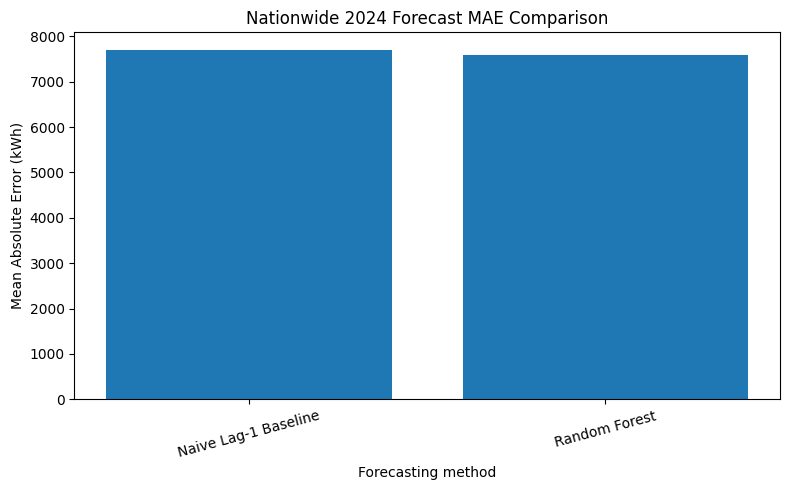

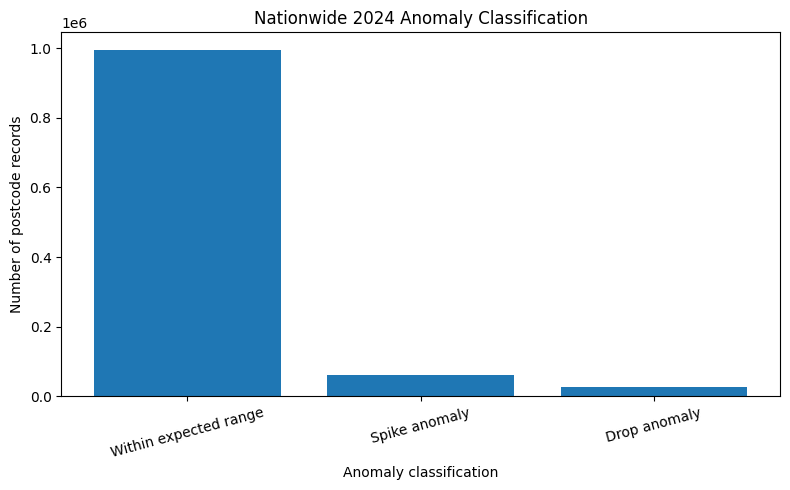

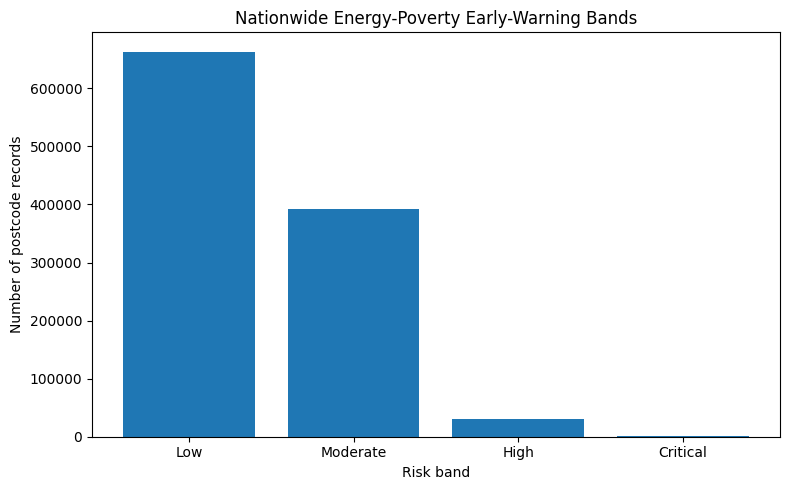

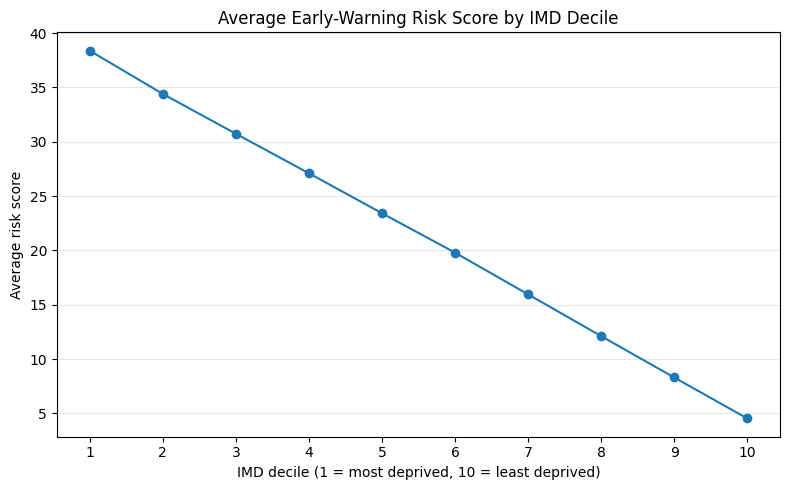

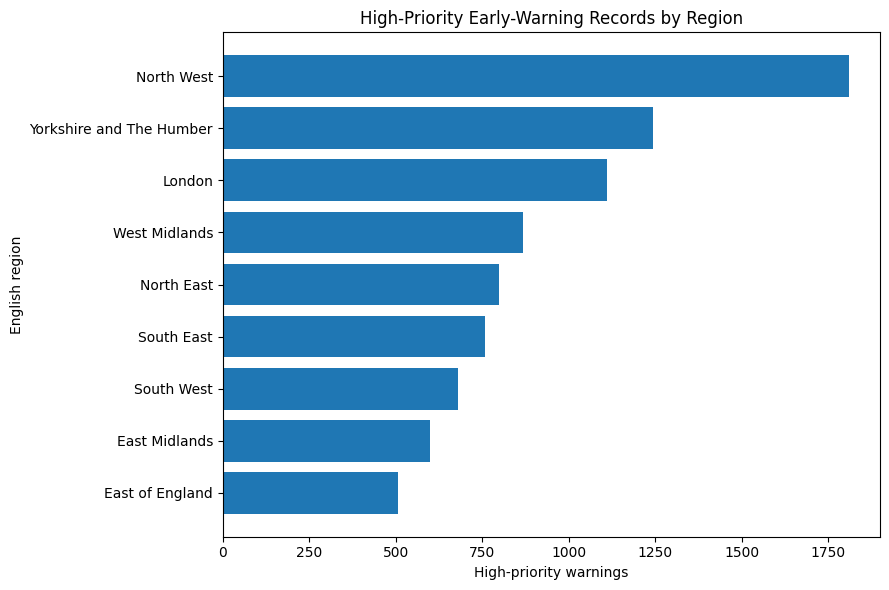

Final figures saved to: /content/drive/MyDrive/energy_poverty_colab/outputs/figures


In [179]:
import matplotlib.pyplot as plt


# Forecast MAE comparison


plt.figure(figsize=(8, 5))

plt.bar(
    final_performance_comparison_df["model"],
    final_performance_comparison_df["mae"]
)

plt.ylabel("Mean Absolute Error (kWh)")
plt.xlabel("Forecasting method")
plt.title("Nationwide 2024 Forecast MAE Comparison")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR /
    "final_forecast_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Anomaly distribution


anomaly_plot_df = con.execute(f"""
    SELECT
        anomaly_type,
        COUNT(*) AS records

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY anomaly_type

    ORDER BY records DESC
""").df()

plt.figure(figsize=(8, 5))

plt.bar(
    anomaly_plot_df["anomaly_type"],
    anomaly_plot_df["records"]
)

plt.ylabel("Number of postcode records")
plt.xlabel("Anomaly classification")
plt.title("Nationwide 2024 Anomaly Classification")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR /
    "final_anomaly_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



#Risk-band distribution

risk_band_plot_df = con.execute(f"""
    SELECT
        risk_band,
        COUNT(*) AS records

    FROM read_parquet(
        '{full_output_sql}'
    )

    GROUP BY risk_band

    ORDER BY
        CASE risk_band
            WHEN 'Low' THEN 1
            WHEN 'Moderate' THEN 2
            WHEN 'High' THEN 3
            WHEN 'Critical' THEN 4
        END
""").df()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_band_plot_df["risk_band"],
    risk_band_plot_df["records"]
)

plt.ylabel("Number of postcode records")
plt.xlabel("Risk band")
plt.title("Nationwide Energy-Poverty Early-Warning Bands")
plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR /
    "final_risk_band_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



#Average risk score by IMD decile

plt.figure(figsize=(8, 5))

plt.plot(
    full_results_by_imd_df["imd_decile"],
    full_results_by_imd_df[
        "average_risk_score"
    ],
    marker="o"
)

plt.xlabel(
    "IMD decile "
    "(1 = most deprived, 10 = least deprived)"
)

plt.ylabel("Average risk score")
plt.title("Average Early-Warning Risk Score by IMD Decile")
plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR /
    "final_average_risk_by_imd_decile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# High-priority warnings by region
region_plot_df = (
    full_region_summary_df
    .sort_values(
        "high_priority_warnings",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    region_plot_df["region_name"],
    region_plot_df[
        "high_priority_warnings"
    ]
)

plt.xlabel("High-priority warnings")
plt.ylabel("English region")
plt.title("High-Priority Early-Warning Records by Region")
plt.tight_layout()

plt.savefig(
    FINAL_FIGURES_DIR /
    "final_high_priority_warnings_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Final figures saved to:",
    FINAL_FIGURES_DIR
)

##Explain the Random Forest predictions

Permutation feature importance for the final Random Forest

Loading final deployment model...
Model loaded successfully.
Number of model features: 21

Loading the 5% validation sample...
Available 2024 validation rows: 53,716

BALANCED EXPLANATION SAMPLE
Total explanation rows: 10,000


,imd_decile,records
0,1,1000
1,2,1000
2,3,1000
3,4,1000
4,5,1000
5,6,1000
6,7,1000
7,8,1000
8,9,1000
9,10,1000



EXPLANATION SAMPLE PERFORMANCE
Sample MAE: 7,620.38 kWh
Finite predictions: True

Calculating permutation importance...
This may take several minutes because each feature is shuffled repeatedly.
Permutation importance completed in: 8.31 seconds

PERMUTATION FEATURE IMPORTANCE


,importance_rank,feature,mae_increase_kwh,importance_standard_deviation,positive_importance_percentage
0,1,lag1_total_kwh,14937.21,193.00,45.67
1,2,log_lag1_total_kwh,14587.72,193.01,44.60
2,3,lag2_total_kwh,1553.17,13.65,4.75
3,4,log_lag2_total_kwh,1335.12,11.77,4.08
4,5,lag1_meters,68.39,5.98,0.21
5,6,log_lag1_meters,59.76,4.89,0.18
6,7,lag1_mean_median_ratio,52.61,7.03,0.16
7,8,prior_mean_change_percent,34.66,5.73,0.11
8,9,lag2_meters,17.40,2.56,0.05
9,10,lag1_median_kwh,16.44,0.51,0.05



FEATURE-IMPORTANCE VALIDATION
Features assessed: 21
Missing importance values: 0
Infinite importance values: 0

PASS: Feature-importance results are valid.

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_random_forest_permutation_importance.csv


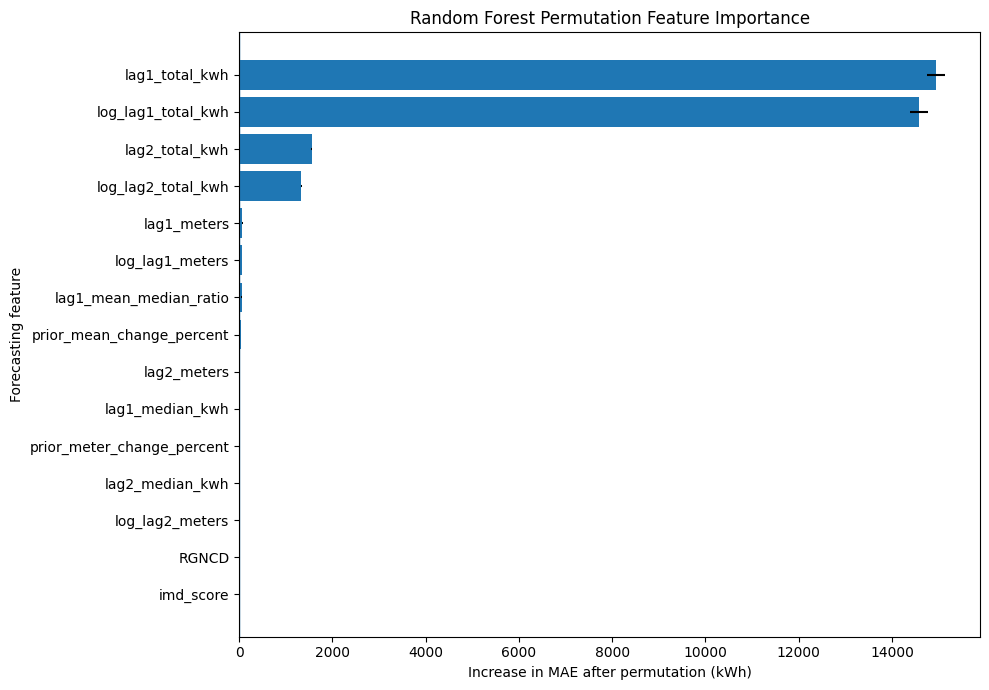

Figure saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/final_random_forest_permutation_importance.png

PASS: Step 30 completed successfully.


13749

In [180]:
from pathlib import Path
import joblib
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error



#Define file locations


PROJECT_PATH = Path(
    "/content/drive/MyDrive/energy_poverty_colab"
)

MODEL_FILE = (
    PROJECT_PATH /
    "outputs" /
    "final_random_forest_deployment_model.joblib"
)

VALIDATION_SAMPLE_FILE = (
    PROJECT_PATH /
    "data" /
    "processed" /
    "model_comparison_sample_5pct.parquet"
)

TABLE_OUTPUT_DIRECTORY = (
    PROJECT_PATH /
    "outputs" /
    "tables"
)

FIGURE_OUTPUT_DIRECTORY = (
    PROJECT_PATH /
    "outputs" /
    "figures"
)

TABLE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)



# Load the saved model package
if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"Final model file not found: {MODEL_FILE}"
    )

print("Loading final deployment model...")

model_package = joblib.load(
    MODEL_FILE
)

explanation_model = model_package[
    "model"
]

explanation_features = list(
    model_package[
        "model_features"
    ]
)

explanation_clip_bounds = model_package[
    "clip_bounds"
]

print("Model loaded successfully.")
print(
    "Number of model features:",
    len(explanation_features)
)



#Load only the required validation columns
explanation_columns = list(dict.fromkeys(
    [
        "Postcode",
        "target_year",
        "imd_decile",
        "target_total_kwh"
    ]
    + explanation_features
))

print("\nLoading the 5% validation sample...")

explanation_source_df = pd.read_parquet(
    VALIDATION_SAMPLE_FILE,
    columns=explanation_columns
)

explanation_source_df = (
    explanation_source_df.loc[
        explanation_source_df[
            "target_year"
        ] == 2024
    ]
    .copy()
)

print(
    "Available 2024 validation rows:",
    f"{len(explanation_source_df):,}"
)



#Create a balanced sample across IMD deciles
ROWS_PER_IMD_DECILE = 1000

available_by_decile = (
    explanation_source_df
    .groupby("imd_decile")
    .size()
)

if (
    available_by_decile.min() <
    ROWS_PER_IMD_DECILE
):
    raise ValueError(
        "At least one IMD decile contains fewer than "
        f"{ROWS_PER_IMD_DECILE} records."
    )

explanation_df = (
    explanation_source_df
    .groupby(
        "imd_decile",
        group_keys=False
    )
    .sample(
        n=ROWS_PER_IMD_DECILE,
        random_state=42
    )
    .sort_values(
        [
            "imd_decile",
            "Postcode"
        ]
    )
    .reset_index(drop=True)
)

print("\nBALANCED EXPLANATION SAMPLE")
print("=" * 80)

print(
    "Total explanation rows:",
    f"{len(explanation_df):,}"
)

display(
    explanation_df
    .groupby("imd_decile")
    .size()
    .rename("records")
    .reset_index()
)


#Apply the final training-derived clipping limits

explanation_clipped_df = (
    explanation_df.copy()
)

for feature, bounds in (
    explanation_clip_bounds.items()
):

    lower_bound, upper_bound = bounds

    explanation_clipped_df[
        feature
    ] = (
        explanation_clipped_df[
            feature
        ]
        .clip(
            lower=lower_bound,
            upper=upper_bound
        )
    )


X_explanation = (
    explanation_clipped_df[
        explanation_features
    ]
)

y_explanation = (
    explanation_clipped_df[
        "target_total_kwh"
    ]
    .to_numpy(dtype=float)
)



#Confirm model performance on the explanation sample

explanation_predictions = (
    explanation_model.predict(
        X_explanation
    )
)

explanation_predictions = np.clip(
    explanation_predictions,
    0,
    None
)

explanation_sample_mae = (
    mean_absolute_error(
        y_explanation,
        explanation_predictions
    )
)

print("\nEXPLANATION SAMPLE PERFORMANCE")
print("=" * 80)

print(
    "Sample MAE:",
    f"{explanation_sample_mae:,.2f} kWh"
)

print(
    "Finite predictions:",
    bool(
        np.isfinite(
            explanation_predictions
        ).all()
    )
)



#Calculate permutation importance
print("\nCalculating permutation importance...")
print(
    "This may take several minutes because each "
    "feature is shuffled repeatedly."
)

importance_start = (
    time.perf_counter()
)

permutation_results = permutation_importance(
    estimator=explanation_model,

    X=X_explanation,

    y=y_explanation,

    scoring="neg_mean_absolute_error",

    n_repeats=3,

    random_state=42,

    n_jobs=-1
)

importance_seconds = (
    time.perf_counter() -
    importance_start
)

print(
    "Permutation importance completed in:",
    f"{importance_seconds:.2f} seconds"
)


# ============================================================
# 8. Create the importance table
# ============================================================

feature_importance_df = pd.DataFrame({
    "feature": explanation_features,

    "mae_increase_kwh": (
        permutation_results[
            "importances_mean"
        ]
    ),

    "importance_standard_deviation": (
        permutation_results[
            "importances_std"
        ]
    )
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "mae_increase_kwh",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.insert(
    0,
    "importance_rank",
    range(
        1,
        len(feature_importance_df) + 1
    )
)

positive_importance_total = (
    feature_importance_df[
        "mae_increase_kwh"
    ]
    .clip(lower=0)
    .sum()
)

if positive_importance_total > 0:

    feature_importance_df[
        "positive_importance_percentage"
    ] = (
        100.0 *
        feature_importance_df[
            "mae_increase_kwh"
        ]
        .clip(lower=0) /
        positive_importance_total
    )

else:

    feature_importance_df[
        "positive_importance_percentage"
    ] = 0.0


print("\nPERMUTATION FEATURE IMPORTANCE")
print("=" * 110)

display(
    feature_importance_df.round({
        "mae_increase_kwh": 2,
        "importance_standard_deviation": 2,
        "positive_importance_percentage": 2
    })
)


#Validate the importance results
missing_importance_values = int(
    feature_importance_df[
        [
            "mae_increase_kwh",
            "importance_standard_deviation"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

infinite_importance_values = int(
    np.isinf(
        feature_importance_df[
            [
                "mae_increase_kwh",
                "importance_standard_deviation"
            ]
        ]
        .to_numpy(dtype=float)
    )
    .sum()
)

print("\nFEATURE-IMPORTANCE VALIDATION")
print("=" * 80)

print(
    "Features assessed:",
    len(feature_importance_df)
)

print(
    "Missing importance values:",
    missing_importance_values
)

print(
    "Infinite importance values:",
    infinite_importance_values
)

if (
    missing_importance_values == 0
    and infinite_importance_values == 0
):

    print(
        "\nPASS: Feature-importance results are valid."
    )

else:

    print(
        "\nWARNING: Review the feature-importance output."
    )



# Save the table
FEATURE_IMPORTANCE_FILE = (
    TABLE_OUTPUT_DIRECTORY /
    "final_random_forest_permutation_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_FILE,
    index=False
)

print(
    "\nSaved:",
    FEATURE_IMPORTANCE_FILE
)



#Create the dissertation feature-importance figure
TOP_FEATURE_COUNT = 15

top_features_plot_df = (
    feature_importance_df
    .head(TOP_FEATURE_COUNT)
    .sort_values(
        "mae_increase_kwh",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features_plot_df[
        "feature"
    ],

    top_features_plot_df[
        "mae_increase_kwh"
    ],

    xerr=top_features_plot_df[
        "importance_standard_deviation"
    ]
)

plt.xlabel(
    "Increase in MAE after permutation (kWh)"
)

plt.ylabel(
    "Forecasting feature"
)

plt.title(
    "Random Forest Permutation Feature Importance"
)

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE = (
    FIGURE_OUTPUT_DIRECTORY /
    "final_random_forest_permutation_importance.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    FEATURE_IMPORTANCE_FIGURE
)



#Save the explanation configuration
explanation_configuration_df = pd.DataFrame([
    {
        "setting": "Explanation method",
        "value": "Permutation feature importance"
    },
    {
        "setting": "Evaluation year",
        "value": 2024
    },
    {
        "setting": "Sampling method",
        "value": (
            "Balanced sample of 1,000 records "
            "per IMD decile"
        )
    },
    {
        "setting": "Explanation sample rows",
        "value": len(explanation_df)
    },
    {
        "setting": "Permutation repeats",
        "value": 3
    },
    {
        "setting": "Importance metric",
        "value": (
            "Increase in mean absolute error "
            "after feature permutation"
        )
    },
    {
        "setting": "Explanation sample MAE",
        "value": explanation_sample_mae
    },
    {
        "setting": "Interpretation limitation",
        "value": (
            "Permutation importance describes predictive "
            "contribution and does not establish causality."
        )
    }
])

explanation_configuration_df.to_csv(
    TABLE_OUTPUT_DIRECTORY /
    "feature_importance_configuration.csv",
    index=False
)

print(
    "\nPASS: Step 30 completed successfully."
)


# Release temporary explanation memory
del explanation_source_df
del explanation_clipped_df
del X_explanation
del y_explanation
del explanation_predictions

gc.collect()

Grouped permutation importance

PASS: All model features belong to one group.
Number of groups: 11

GROUPED EXPLANATION SAMPLE
Rows: 10,000

ORIGINAL EXPLANATION SAMPLE
Original MAE: 7,620.38 kWh
Permuting group: Previous-year total consumption
Permuting group: Two-year lag total consumption
Permuting group: Previous-year meter count
Permuting group: Two-year lag meter count
Permuting group: Historical mean consumption
Permuting group: Historical median consumption
Permuting group: Historical change indicators
Permuting group: Mean-to-median relationship
Permuting group: Deprivation context
Permuting group: Geographical context
Permuting group: Forecast year

Grouped permutation completed in: 3.53 seconds

GROUPED PERMUTATION FEATURE IMPORTANCE


,importance_rank,feature_group,features_in_group,number_of_features,mae_increase_kwh,importance_standard_deviation,minimum_mae_increase,maximum_mae_increase,positive_importance_percentage
0,1,Previous-year total consumption,lag1_total_kwh; log_lag1_total_kwh,2,37693.42,283.57,37369.48,38133.63,88.97
1,2,Two-year lag total consumption,lag2_total_kwh; log_lag2_total_kwh,2,4292.62,74.68,4228.54,4421.53,10.13
2,3,Previous-year meter count,lag1_meters; log_lag1_meters,2,201.23,8.69,190.34,214.12,0.47
3,4,Historical change indicators,prior_total_change_percent; prior_meter_change...,3,59.73,13.91,36.28,69.97,0.14
4,5,Mean-to-median relationship,lag1_mean_median_ratio,1,50.83,7.04,45.41,62.86,0.12
5,6,Two-year lag meter count,lag2_meters; log_lag2_meters,2,35.32,11.54,26.35,54.58,0.08
6,7,Historical median consumption,lag1_median_kwh; lag2_median_kwh,2,20.51,2.35,17.49,23.38,0.05
7,8,Deprivation context,imd_score; imd_decile,2,7.92,3.08,2.92,10.45,0.02
8,9,Geographical context,RGNCD; LADCD,2,6.39,0.83,5.04,7.18,0.02
9,10,Forecast year,target_year,1,0.00,0.00,0.00,0.00,0.00



GROUPED IMPORTANCE VALIDATION
Groups assessed: 11
Missing values: 0
Infinite values: 0

PASS: Grouped importance results are valid.

Saved: /content/drive/MyDrive/energy_poverty_colab/outputs/tables/final_random_forest_grouped_permutation_importance.csv


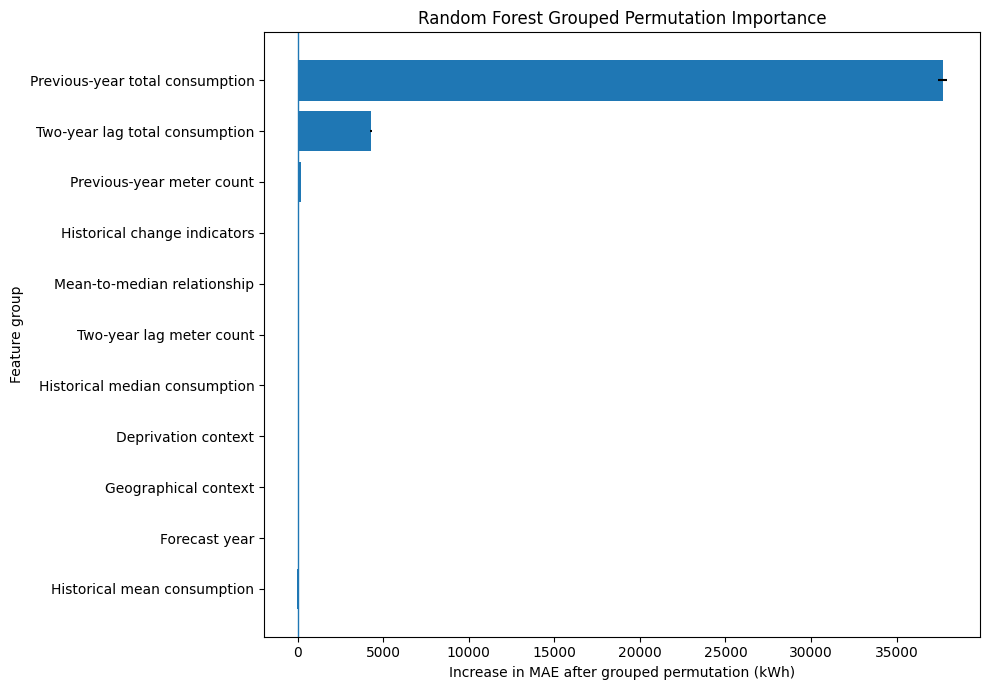

Figure saved: /content/drive/MyDrive/energy_poverty_colab/outputs/figures/final_random_forest_grouped_permutation_importance.png

PASS: Step 31 completed successfully.


4362

In [181]:
from pathlib import Path
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


#Define locations


PROJECT_PATH = Path(
    "/content/drive/MyDrive/energy_poverty_colab"
)

MODEL_FILE = (
    PROJECT_PATH /
    "outputs" /
    "final_random_forest_deployment_model.joblib"
)

VALIDATION_SAMPLE_FILE = (
    PROJECT_PATH /
    "data" /
    "processed" /
    "model_comparison_sample_5pct.parquet"
)

TABLE_OUTPUT_DIRECTORY = (
    PROJECT_PATH /
    "outputs" /
    "tables"
)

FIGURE_OUTPUT_DIRECTORY = (
    PROJECT_PATH /
    "outputs" /
    "figures"
)

TABLE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)



#Load saved model package


model_package = joblib.load(
    MODEL_FILE
)

grouped_model = model_package["model"]

grouped_model_features = list(
    model_package["model_features"]
)

grouped_clip_bounds = model_package[
    "clip_bounds"
]



#Define interpretable feature groups
FEATURE_GROUPS = {
    "Previous-year total consumption": [
        "lag1_total_kwh",
        "log_lag1_total_kwh"
    ],

    "Two-year lag total consumption": [
        "lag2_total_kwh",
        "log_lag2_total_kwh"
    ],

    "Previous-year meter count": [
        "lag1_meters",
        "log_lag1_meters"
    ],

    "Two-year lag meter count": [
        "lag2_meters",
        "log_lag2_meters"
    ],

    "Historical mean consumption": [
        "lag1_mean_kwh",
        "lag2_mean_kwh"
    ],

    "Historical median consumption": [
        "lag1_median_kwh",
        "lag2_median_kwh"
    ],

    "Historical change indicators": [
        "prior_total_change_percent",
        "prior_meter_change_percent",
        "prior_mean_change_percent"
    ],

    "Mean-to-median relationship": [
        "lag1_mean_median_ratio"
    ],

    "Deprivation context": [
        "imd_score",
        "imd_decile"
    ],

    "Geographical context": [
        "RGNCD",
        "LADCD"
    ],

    "Forecast year": [
        "target_year"
    ]
}


# Check that every grouped feature exists
grouped_features_flat = [
    feature
    for group_features
    in FEATURE_GROUPS.values()
    for feature in group_features
]

missing_grouped_features = sorted(
    set(grouped_features_flat) -
    set(grouped_model_features)
)

ungrouped_model_features = sorted(
    set(grouped_model_features) -
    set(grouped_features_flat)
)

if missing_grouped_features:
    raise ValueError(
        "Grouped features missing from the model: "
        f"{missing_grouped_features}"
    )

if ungrouped_model_features:
    raise ValueError(
        "Some model features were not assigned "
        f"to a group: {ungrouped_model_features}"
    )

print("PASS: All model features belong to one group.")
print("Number of groups:", len(FEATURE_GROUPS))



# Load balanced 2024 explanation sample
grouped_columns = list(dict.fromkeys(
    [
        "Postcode",
        "target_year",
        "imd_decile",
        "target_total_kwh"
    ]
    + grouped_model_features
))

grouped_source_df = pd.read_parquet(
    VALIDATION_SAMPLE_FILE,
    columns=grouped_columns
)

grouped_source_df = (
    grouped_source_df.loc[
        grouped_source_df[
            "target_year"
        ] == 2024
    ]
    .copy()
)

ROWS_PER_IMD_DECILE = 1000

grouped_explanation_df = (
    grouped_source_df
    .groupby(
        "imd_decile",
        group_keys=False
    )
    .sample(
        n=ROWS_PER_IMD_DECILE,
        random_state=42
    )
    .sort_values(
        [
            "imd_decile",
            "Postcode"
        ]
    )
    .reset_index(drop=True)
)

print("\nGROUPED EXPLANATION SAMPLE")
print("=" * 80)

print(
    "Rows:",
    f"{len(grouped_explanation_df):,}"
)



# Apply final clipping limits
grouped_clipped_df = (
    grouped_explanation_df.copy()
)

for feature, bounds in (
    grouped_clip_bounds.items()
):

    lower_bound, upper_bound = bounds

    grouped_clipped_df[feature] = (
        grouped_clipped_df[feature]
        .clip(
            lower=lower_bound,
            upper=upper_bound
        )
    )


X_grouped = grouped_clipped_df[
    grouped_model_features
].copy()

y_grouped = grouped_clipped_df[
    "target_total_kwh"
].to_numpy(dtype=float)



# Calculate original sample MAE
original_predictions = grouped_model.predict(
    X_grouped
)

original_predictions = np.clip(
    original_predictions,
    0,
    None
)

original_mae = mean_absolute_error(
    y_grouped,
    original_predictions
)

print("\nORIGINAL EXPLANATION SAMPLE")
print("=" * 80)

print(
    "Original MAE:",
    f"{original_mae:,.2f} kWh"
)


# Permute complete feature groups
GROUPED_REPEATS = 5
RANDOM_SEED = 42

random_generator = np.random.default_rng(
    RANDOM_SEED
)

group_importance_records = []

grouped_start = time.perf_counter()

for group_name, group_features in (
    FEATURE_GROUPS.items()
):

    print(
        f"Permuting group: {group_name}"
    )

    repeat_mae_increases = []

    for repeat_number in range(
        GROUPED_REPEATS
    ):

        permuted_data = X_grouped.copy()

        permutation_order = (
            random_generator.permutation(
                len(permuted_data)
            )
        )

        # Apply the same row permutation to every
        # feature in the group to preserve internal
        # relationships within that feature family.
        permuted_data.loc[
            :,
            group_features
        ] = (
            permuted_data[
                group_features
            ]
            .iloc[
                permutation_order
            ]
            .to_numpy()
        )

        permuted_predictions = (
            grouped_model.predict(
                permuted_data
            )
        )

        permuted_predictions = np.clip(
            permuted_predictions,
            0,
            None
        )

        permuted_mae = mean_absolute_error(
            y_grouped,
            permuted_predictions
        )

        mae_increase = (
            permuted_mae -
            original_mae
        )

        repeat_mae_increases.append(
            mae_increase
        )

    group_importance_records.append({
        "feature_group": group_name,

        "features_in_group": (
            "; ".join(group_features)
        ),

        "number_of_features": len(
            group_features
        ),

        "mae_increase_kwh": float(
            np.mean(
                repeat_mae_increases
            )
        ),

        "importance_standard_deviation": float(
            np.std(
                repeat_mae_increases,
                ddof=1
            )
        ),

        "minimum_mae_increase": float(
            np.min(
                repeat_mae_increases
            )
        ),

        "maximum_mae_increase": float(
            np.max(
                repeat_mae_increases
            )
        )
    })

grouped_seconds = (
    time.perf_counter() -
    grouped_start
)

print(
    "\nGrouped permutation completed in:",
    f"{grouped_seconds:.2f} seconds"
)


# Create grouped importance table
grouped_importance_df = pd.DataFrame(
    group_importance_records
)

grouped_importance_df = (
    grouped_importance_df
    .sort_values(
        "mae_increase_kwh",
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_importance_df.insert(
    0,
    "importance_rank",
    range(
        1,
        len(grouped_importance_df) + 1
    )
)

positive_group_total = (
    grouped_importance_df[
        "mae_increase_kwh"
    ]
    .clip(lower=0)
    .sum()
)

if positive_group_total > 0:

    grouped_importance_df[
        "positive_importance_percentage"
    ] = (
        100.0 *
        grouped_importance_df[
            "mae_increase_kwh"
        ]
        .clip(lower=0) /
        positive_group_total
    )

else:

    grouped_importance_df[
        "positive_importance_percentage"
    ] = 0.0


print("\nGROUPED PERMUTATION FEATURE IMPORTANCE")
print("=" * 130)

display(
    grouped_importance_df.round({
        "mae_increase_kwh": 2,
        "importance_standard_deviation": 2,
        "minimum_mae_increase": 2,
        "maximum_mae_increase": 2,
        "positive_importance_percentage": 2
    })
)



# Validate results
missing_group_values = int(
    grouped_importance_df[
        [
            "mae_increase_kwh",
            "importance_standard_deviation"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

infinite_group_values = int(
    np.isinf(
        grouped_importance_df[
            [
                "mae_increase_kwh",
                "importance_standard_deviation"
            ]
        ]
        .to_numpy(dtype=float)
    )
    .sum()
)

print("\nGROUPED IMPORTANCE VALIDATION")
print("=" * 80)

print(
    "Groups assessed:",
    len(grouped_importance_df)
)

print(
    "Missing values:",
    missing_group_values
)

print(
    "Infinite values:",
    infinite_group_values
)

if (
    missing_group_values == 0
    and infinite_group_values == 0
):

    print(
        "\nPASS: Grouped importance results are valid."
    )

else:

    print(
        "\nWARNING: Review the grouped results."
    )


# Save grouped table
GROUPED_IMPORTANCE_FILE = (
    TABLE_OUTPUT_DIRECTORY /
    "final_random_forest_grouped_permutation_importance.csv"
)

grouped_importance_df.to_csv(
    GROUPED_IMPORTANCE_FILE,
    index=False
)

print(
    "\nSaved:",
    GROUPED_IMPORTANCE_FILE
)


# Create grouped importance chart
grouped_plot_df = (
    grouped_importance_df
    .sort_values(
        "mae_increase_kwh",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    grouped_plot_df[
        "feature_group"
    ],

    grouped_plot_df[
        "mae_increase_kwh"
    ],

    xerr=grouped_plot_df[
        "importance_standard_deviation"
    ]
)

plt.xlabel(
    "Increase in MAE after grouped permutation (kWh)"
)

plt.ylabel(
    "Feature group"
)

plt.title(
    "Random Forest Grouped Permutation Importance"
)

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()

GROUPED_IMPORTANCE_FIGURE = (
    FIGURE_OUTPUT_DIRECTORY /
    "final_random_forest_grouped_permutation_importance.png"
)

plt.savefig(
    GROUPED_IMPORTANCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    GROUPED_IMPORTANCE_FIGURE
)


# Save configuration
grouped_configuration_df = pd.DataFrame([
    {
        "setting": "Explanation method",
        "value": "Grouped permutation importance"
    },
    {
        "setting": "Evaluation year",
        "value": 2024
    },
    {
        "setting": "Explanation sample",
        "value": (
            "Balanced 10,000-record sample with "
            "1,000 postcodes per IMD decile"
        )
    },
    {
        "setting": "Permutation repeats",
        "value": GROUPED_REPEATS
    },
    {
        "setting": "Base scoring metric",
        "value": "Mean absolute error"
    },
    {
        "setting": "Original sample MAE",
        "value": original_mae
    },
    {
        "setting": "Group permutation rule",
        "value": (
            "All features within a group receive "
            "the same row permutation"
        )
    },
    {
        "setting": "Interpretation limitation",
        "value": (
            "Importance measures predictive reliance "
            "and does not demonstrate causality."
        )
    }
])

grouped_configuration_df.to_csv(
    TABLE_OUTPUT_DIRECTORY /
    "grouped_feature_importance_configuration.csv",
    index=False
)

print(
    "\nPASS: Step 31 completed successfully."
)


# Release memory
del grouped_source_df
del grouped_clipped_df
del X_grouped
del y_grouped
del original_predictions

gc.collect()